In [1]:
%pip install -q --upgrade setuptools wheel
%pip install -q transformer_lens blobfile==2.0.2

print("Основные библиотеки установлены")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 36.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 101.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 98.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 35.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Основные библиотеки установлены


In [2]:
from pathlib import Path
import subprocess
import sys

repo_dir = Path(
    "/kaggle/working/openai_sparse_autoencoder"
)

if not repo_dir.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/openai/sparse_autoencoder.git",
            str(repo_dir),
        ],
        check=True,
    )

if str(repo_dir) not in sys.path:
    sys.path.insert(
        0,
        str(repo_dir),
    )

import sparse_autoencoder

print("OpenAI sparse_autoencoder подключён")
print("Путь:", sparse_autoencoder.__file__)

Cloning into '/kaggle/working/openai_sparse_autoencoder'...


OpenAI sparse_autoencoder подключён
Путь: /kaggle/working/openai_sparse_autoencoder/sparse_autoencoder/__init__.py


In [3]:
import torch
import blobfile as bf

from transformer_lens import HookedTransformer

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU не обнаружена. Проверь Accelerator."
    )

device = torch.device("cuda:0")

print("PyTorch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())
print("Количество GPU:", torch.cuda.device_count())
print("Используемая GPU:", torch.cuda.get_device_name(0))
print("Устройство:", device)

PyTorch: 2.10.0+cu128
CUDA доступна: True
Количество GPU: 2
Используемая GPU: Tesla T4
Устройство: cuda:0


In [4]:
model = HookedTransformer.from_pretrained(
    "gpt2-small",
    device=device,
    center_writing_weights=False,
)

model.eval()

# Запрещаем изменять параметры GPT-2
for parameter in model.parameters():
    parameter.requires_grad = False

# Выбираем слой, после которого будем менять активацию
layer_index = 6

# Название нужной точки внутри GPT-2
hook_name = f"blocks.{layer_index}.hook_resid_post"

# Размер вектора активации GPT-2 small
d_model = model.cfg.d_model

print("GPT-2 успешно загружена")
print("Количество блоков:", model.cfg.n_layers)
print("Размер активации:", d_model)
print("Точка интервенции:", hook_name)

/tmp/ipykernel_58/3235060069.py:1: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
GPT-2 успешно загружена
Количество блоков: 12
Размер активации: 768
Точка интервенции: blocks.6.hook_resid_post


In [5]:
location = "resid_post_mlp"

checkpoint_path = (
    sparse_autoencoder.paths.v5_32k(
        location,
        layer_index,
    )
)

print("Загружаем SAE:")
print(checkpoint_path)

with bf.BlobFile(
    checkpoint_path,
    mode="rb",
) as file:

    state_dict = torch.load(
        file,
        map_location="cpu",
        weights_only=False,
    )

sae = (
    sparse_autoencoder.Autoencoder
    .from_state_dict(state_dict)
)

sae = sae.to(device)
sae.eval()

for parameter in sae.parameters():
    parameter.requires_grad = False

del state_dict

print("SAE успешно загружен")
print(
    "Форма энкодера:",
    sae.encoder.weight.shape,
)
print(
    "Форма декодера:",
    sae.decoder.weight.shape,
)

Загружаем SAE:
az://openaipublic/sparse-autoencoder/gpt2-small/resid_post_mlp_v5_32k/autoencoders/6.pt
SAE успешно загружен
Форма энкодера: torch.Size([32768, 768])
Форма декодера: torch.Size([768, 32768])


In [6]:
REFERENCE_NORM = 88.58959197998047


def get_steering_vector(feature_index):

    vector = (
        sae.decoder.weight[
            :,
            feature_index,
        ]
        .detach()
        .clone()
    )

    vector = vector / vector.norm()

    return vector


test_vector = get_steering_vector(2252)

print("REFERENCE_NORM:", REFERENCE_NORM)
print("Форма вектора:", test_vector.shape)
print("Норма вектора:", test_vector.norm().item())

REFERENCE_NORM: 88.58959197998047
Форма вектора: torch.Size([768])
Норма вектора: 1.0


In [8]:
import torch


@torch.no_grad()
def calculate_phrase_log_probability(
    prompt,
    target_phrase,
    steering_vector,
    alpha_hat=0.0,
):

    context_tokens = model.to_tokens(
        prompt
    ).to(device)

    target_token_ids = (
        model.tokenizer.encode(
            target_phrase,
            add_special_tokens=False,
        )
    )

    if len(target_token_ids) == 0:
        raise ValueError(
            "Целевая фраза не содержит токенов"
        )

    alpha = (
        alpha_hat * REFERENCE_NORM
    )

    vector = steering_vector.to(
        device=device,
        dtype=model.W_E.dtype,
    )

    def steering_hook(
        residual,
        hook,
    ):
        residual = residual.clone()

        residual[:, -1, :] += (
            alpha * vector
        )

        return residual

    token_log_probabilities = []

    for target_token_id in target_token_ids:

        logits = model.run_with_hooks(
            context_tokens,
            return_type="logits",
            fwd_hooks=[
                (
                    hook_name,
                    steering_hook,
                )
            ],
        )

        next_token_log_probs = (
            torch.log_softmax(
                logits[:, -1, :],
                dim=-1,
            )
        )

        token_log_probability = (
            next_token_log_probs[
                0,
                target_token_id,
            ].item()
        )

        token_log_probabilities.append(
            token_log_probability
        )

        next_target_token = torch.tensor(
            [[target_token_id]],
            device=device,
            dtype=torch.long,
        )

        context_tokens = torch.cat(
            [
                context_tokens,
                next_target_token,
            ],
            dim=-1,
        )

    return (
        sum(token_log_probabilities)
        / len(token_log_probabilities)
    )


@torch.no_grad()
def generate_with_reference_steering(
    prompt,
    steering_vector,
    alpha_hat=0.0,
    max_new_tokens=35,
    temperature=0.8,
    top_k=50,
    seed=42,
):

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    tokens = model.to_tokens(
        prompt
    ).to(device)

    alpha

In [9]:
REFERENCE_NORM = 88.58959197998047


def get_steering_vector(feature_index):

    vector = (
        sae.decoder.weight[
            :,
            feature_index,
        ]
        .detach()
        .clone()
    )

    vector = vector / vector.norm()

    return vector


test_vector = get_steering_vector(2252)

print("REFERENCE_NORM:", REFERENCE_NORM)
print("Форма вектора:", test_vector.shape)
print("Норма вектора:", test_vector.norm().item())

REFERENCE_NORM: 88.58959197998047
Форма вектора: torch.Size([768])
Норма вектора: 1.0


In [10]:
import math
import torch


@torch.no_grad()
def calculate_phrase_log_probability(
    prompt,
    target_phrase,
    steering_vector,
    alpha_hat=0.0,
):
    context_tokens = model.to_tokens(
        prompt
    ).to(device)

    target_token_ids = (
        model.tokenizer.encode(
            target_phrase,
            add_special_tokens=False,
        )
    )

    if len(target_token_ids) == 0:
        raise ValueError(
            "Целевая фраза не содержит токенов"
        )

    alpha = (
        alpha_hat * REFERENCE_NORM
    )

    vector = steering_vector.to(
        device=device,
        dtype=model.W_E.dtype,
    )

    def steering_hook(
        residual,
        hook,
    ):
        residual = residual.clone()

        residual[:, -1, :] += (
            alpha * vector
        )

        return residual

    token_log_probabilities = []

    for target_token_id in target_token_ids:

        logits = model.run_with_hooks(
            context_tokens,
            return_type="logits",
            fwd_hooks=[
                (
                    hook_name,
                    steering_hook,
                )
            ],
        )

        next_token_log_probs = (
            torch.log_softmax(
                logits[:, -1, :],
                dim=-1,
            )
        )

        token_log_probability = (
            next_token_log_probs[
                0,
                target_token_id,
            ].item()
        )

        token_log_probabilities.append(
            token_log_probability
        )

        next_target_token = torch.tensor(
            [[target_token_id]],
            device=device,
            dtype=torch.long,
        )

        context_tokens = torch.cat(
            [
                context_tokens,
                next_target_token,
            ],
            dim=-1,
        )

    return (
        sum(token_log_probabilities)
        / len(token_log_probabilities)
    )


@torch.no_grad()
def generate_with_reference_steering(
    prompt,
    steering_vector,
    alpha_hat=0.0,
    max_new_tokens=35,
    temperature=0.8,
    top_k=50,
    seed=42,
):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    tokens = model.to_tokens(
        prompt
    ).to(device)

    alpha = (
        alpha_hat * REFERENCE_NORM
    )

    vector = steering_vector.to(
        device=device,
        dtype=model.W_E.dtype,
    )

    def steering_hook(
        residual,
        hook,
    ):
        residual = residual.clone()

        residual[:, -1, :] += (
            alpha * vector
        )

        return residual

    for _ in range(max_new_tokens):

        logits = model.run_with_hooks(
            tokens,
            return_type="logits",
            fwd_hooks=[
                (
                    hook_name,
                    steering_hook,
                )
            ],
        )

        next_token_logits = (
            logits[:, -1, :]
            / temperature
        )

        current_top_k = min(
            top_k,
            next_token_logits.shape[-1],
        )

        top_values, top_indices = (
            torch.topk(
                next_token_logits,
                k=current_top_k,
                dim=-1,
            )
        )

        probabilities = torch.softmax(
            top_values,
            dim=-1,
        )

        sampled_position = torch.multinomial(
            probabilities,
            num_samples=1,
        )

        next_token = top_indices.gather(
            -1,
            sampled_position,
        )

        tokens = torch.cat(
            [
                tokens,
                next_token,
            ],
            dim=-1,
        )

        if (
            model.tokenizer.eos_token_id
            is not None
            and next_token.item()
            == model.tokenizer.eos_token_id
        ):
            break

    return model.to_string(
        tokens[0]
    )


print("Функции оценки и генерации восстановлены")

Функции оценки и генерации восстановлены


In [11]:
validated_vectors = {
    "paris": {
        "feature_index": 2252,
        "alpha_hat": 0.20,
        "vector": get_steering_vector(
            2252
        ),
        "real_alpha": (
            0.20 * REFERENCE_NORM
        ),
        "final_target_delta": 0.6940,
        "probability_multiplier": 2.00,
        "specificity": 0.6494,
        "positive_prompts": 8,
        "total_prompts": 8,
        "status": (
            "validated_with_moderate_generation"
        ),
    },

    "ocean": {
        "feature_index": 24664,
        "alpha_hat": 0.20,
        "vector": get_steering_vector(
            24664
        ),
        "real_alpha": (
            0.20 * REFERENCE_NORM
        ),
        "final_target_delta": 0.2802,
        "probability_multiplier": 1.32,
        "specificity": 0.2751,
        "positive_prompts": 8,
        "total_prompts": 8,
        "generation_exact_baseline": 1,
        "generation_exact_steering": 3,
        "generation_related_baseline": 2,
        "generation_related_steering": 7,
        "status": "fully_validated",
    },
}


quantitative_candidates = {
    "opera": {
        "feature_index": 28999,
        "alpha_hat": 0.20,
        "vector": get_steering_vector(
            28999
        ),
        "real_alpha": (
            0.20 * REFERENCE_NORM
        ),
        "target_delta": 0.5993,
        "probability_multiplier": 1.82,
        "specificity": 0.3515,
        "status": "quantitative_only",
    },

    "banana": {
        "feature_index": 31031,
        "alpha_hat": 0.20,
        "vector": get_steering_vector(
            31031
        ),
        "real_alpha": (
            0.20 * REFERENCE_NORM
        ),
        "target_delta": 0.2793,
        "probability_multiplier": 1.32,
        "specificity": 0.2583,
        "status": "quantitative_only",
    },
}


print("Подтверждённые:")
for concept, data in validated_vectors.items():
    print(
        concept,
        "→",
        data["feature_index"],
        data["status"],
    )

print()
print("Количественные кандидаты:")
for concept, data in quantitative_candidates.items():
    print(
        concept,
        "→",
        data["feature_index"],
        data["status"],
    )

Подтверждённые:
paris → 2252 validated_with_moderate_generation
ocean → 24664 fully_validated

Количественные кандидаты:
opera → 28999 quantitative_only
banana → 31031 quantitative_only


In [11]:
from pathlib import Path
from IPython.display import FileLink, display
import json
import torch

checkpoint_path = Path(
    "/kaggle/working/steering_project_state.pt"
)

metadata_path = Path(
    "/kaggle/working/steering_project_metadata.json"
)


def copy_collection_to_cpu(collection):

    result = {}

    for concept, data in collection.items():

        result[concept] = {}

        for key, value in data.items():

            if isinstance(value, torch.Tensor):
                result[concept][key] = (
                    value.detach().cpu()
                )
            else:
                result[concept][key] = value

    return result


project_state = {
    "reference_norm": REFERENCE_NORM,
    "layer_index": layer_index,
    "hook_name": hook_name,
    "validated_vectors": (
        copy_collection_to_cpu(
            validated_vectors
        )
    ),
    "quantitative_candidates": (
        copy_collection_to_cpu(
            quantitative_candidates
        )
    ),
}

torch.save(
    project_state,
    checkpoint_path,
)

# Отдельный читаемый JSON без тензоров.
project_metadata = {
    "reference_norm": REFERENCE_NORM,
    "layer_index": layer_index,
    "hook_name": hook_name,
    "validated_vectors": {
        concept: {
            key: value
            for key, value in data.items()
            if key != "vector"
        }
        for concept, data
        in validated_vectors.items()
    },
    "quantitative_candidates": {
        concept: {
            key: value
            for key, value in data.items()
            if key != "vector"
        }
        for concept, data
        in quantitative_candidates.items()
    },
}

with open(
    metadata_path,
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        project_metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Состояние сохранено:")
print(checkpoint_path)
print(metadata_path)
print()
print("Ссылка для скачивания checkpoint:")

display(
    FileLink(str(checkpoint_path))
)

NameError: name 'validated_vectors' is not defined

In [13]:
@torch.no_grad()
def get_last_token_sae_features(prompts):

    collected_features = []

    for prompt in prompts:

        tokens = model.to_tokens(
            prompt
        ).to(device)

        _, cache = model.run_with_cache(
            tokens,
            names_filter=lambda name: (
                name == hook_name
            ),
        )

        last_token_h = cache[hook_name][
            :,
            -1:,
            :,
        ]

        last_token_z, _ = sae.encode(
            last_token_h
        )

        collected_features.append(
            last_token_z[
                0,
                0,
                :,
            ].detach()
        )

    return torch.stack(
        collected_features,
        dim=0,
    )


print(
    "Функция поиска SAE-признаков восстановлена"
)

Функция поиска SAE-признаков восстановлена


In [ ]:
test_prompt = "The Eiffel Tower is located in"

tokens = model.to_tokens(test_prompt)

with torch.no_grad():
    _, cache = model.run_with_cache(
        tokens,
        names_filter=lambda name: name == hook_name,
    )

    # Активация GPT-2 после выбранного слоя
    h = cache[hook_name]

    # Сжимаем активацию через энкодер SAE
    z, sae_info = sae.encode(h)

    # Восстанавливаем активацию через декодер SAE
    h_reconstructed = sae.decode(z, sae_info)

normalized_mse = (
    (h_reconstructed - h).pow(2).sum()
    / h.pow(2).sum()
).item()

activation_norm = h.norm(dim=-1).mean().item()

print("Форма активации h:", h.shape)
print("Форма разреженного представления z:", z.shape)
print("Ошибка восстановления SAE:", normalized_mse)
print("Средняя норма активации:", activation_norm)

In [ ]:
positive_prompts = [
    "Paris is the capital of France.",
    "The Eiffel Tower stands in Paris.",
    "Tourists visited the Louvre in Paris.",
    "The Seine flows through the center of Paris.",
    "French cafés filled the streets of Paris.",
    "The Arc de Triomphe is a famous Paris landmark.",
]

negative_prompts = [
    "Tokyo is a large city in Japan.",
    "The doctor worked in a hospital.",
    "A football team prepared for the match.",
    "The dog ran through a green field.",
    "Scientists studied a distant galaxy.",
    "The ship crossed the ocean at night.",
]

In [ ]:
@torch.no_grad()
def calculate_mean_sae_features(prompts):

    # Для каждого из 32768 признаков будем считать сумму активаций
    feature_sum = torch.zeros(
        sae.encoder.weight.shape[0],
        device=device,
    )

    token_count = 0

    for prompt in prompts:

        tokens = model.to_tokens(prompt)

        _, cache = model.run_with_cache(
            tokens,
            names_filter=lambda name: name == hook_name,
        )

        prompt_h = cache[hook_name]

        # Не учитываем первый служебный BOS-токен
        prompt_h = prompt_h[:, 1:, :]

        # Получаем разреженные SAE-признаки
        prompt_z, _ = sae.encode(prompt_h)

        feature_sum += prompt_z.sum(dim=(0, 1))

        token_count += (
            prompt_z.shape[0] * prompt_z.shape[1]
        )

    return feature_sum / token_count

In [ ]:
positive_mean = calculate_mean_sae_features(
    positive_prompts
)

negative_mean = calculate_mean_sae_features(
    negative_prompts
)

# Нас интересуют признаки, которые сильнее
# активируются на примерах про Париж
feature_scores = positive_mean - negative_mean

candidate_features = torch.topk(
    feature_scores,
    k=10,
).indices.tolist()

print("Кандидаты на признаки Парижа:")
print(candidate_features)

In [ ]:
def get_steering_vector(feature_index):

    # Каждый столбец декодера SAE —
    # отдельное направление в пространстве активаций GPT-2
    vector = sae.decoder.weight[
        :,
        feature_index,
    ].detach().clone()

    # Делаем норму вектора равной единице
    vector = vector / vector.norm()

    return vector


print("Форма декодера:", sae.decoder.weight.shape)

test_vector = get_steering_vector(
    candidate_features[0]
)

print("Форма steering-вектора:", test_vector.shape)
print("Норма steering-вектора:", test_vector.norm().item())

In [ ]:
@torch.no_grad()
def generate_with_steering(
    prompt,
    steering_vector,
    alpha_hat=0.0,
    max_new_tokens=30,
    temperature=0.8,
    top_k=50,
    seed=42,
):

    torch.manual_seed(seed)

    tokens = model.to_tokens(prompt)

    # alpha_hat — относительная сила стиринга
    # alpha — реальная величина добавляемого вектора
    alpha = alpha_hat * activation_norm

    def steering_hook(residual, hook):

        # Не изменяем исходный tensor напрямую
        residual = residual.clone()

        # Меняем активацию только последнего токена
        residual[:, -1, :] += (
            alpha
            * steering_vector.to(residual.device)
        )

        return residual

    for _ in range(max_new_tokens):

        logits = model.run_with_hooks(
            tokens,
            return_type="logits",
            fwd_hooks=[
                (hook_name, steering_hook)
            ],
        )

        next_token_logits = (
            logits[:, -1, :] / temperature
        )

        # Оставляем 50 наиболее вероятных токенов
        top_values, top_indices = torch.topk(
            next_token_logits,
            k=top_k,
            dim=-1,
        )

        probabilities = torch.softmax(
            top_values,
            dim=-1,
        )

        sampled_position = torch.multinomial(
            probabilities,
            num_samples=1,
        )

        next_token = top_indices.gather(
            -1,
            sampled_position,
        )

        tokens = torch.cat(
            [tokens, next_token],
            dim=-1,
        )

        if next_token.item() == model.tokenizer.eos_token_id:
            break

    return model.to_string(tokens[0])

In [ ]:
test_prompt = "The old building was famous for"

test_strength = 0.25

for feature_index in candidate_features[:5]:

    steering_vector = get_steering_vector(
        feature_index
    )

    generated_text = generate_with_steering(
        prompt=test_prompt,
        steering_vector=steering_vector,
        alpha_hat=test_strength,
        max_new_tokens=25,
        seed=42,
    )

    print("\n" + "=" * 70)
    print("Номер SAE-признака:", feature_index)
    print(generated_text)

In [ ]:
# Все положительные предложения заканчиваются словом Paris.
# Поэтому анализируем активацию именно последнего токена.

positive_prompts = [
    "The Eiffel Tower is located in Paris",
    "The Louvre Museum is located in Paris",
    "The Seine river flows through Paris",
    "The capital of France is Paris",
    "A famous French city is Paris",
    "Many tourists travel to Paris",
]

# Контрольные предложения тоже заканчиваются названием города,
# но не Парижа.

negative_prompts = [
    "Tokyo Tower is located in Tokyo",
    "The British Museum is located in London",
    "The Tiber river flows through Rome",
    "The capital of Germany is Berlin",
    "A famous Spanish city is Madrid",
    "Many tourists travel to Amsterdam",
]


@torch.no_grad()
def calculate_last_token_features(prompts):

    all_features = []

    for prompt in prompts:

        tokens = model.to_tokens(prompt)

        _, cache = model.run_with_cache(
            tokens,
            names_filter=lambda name: name == hook_name,
        )

        prompt_h = cache[hook_name]

        # Берём активацию только последнего токена
        last_token_h = prompt_h[:, -1:, :]

        last_token_z, _ = sae.encode(last_token_h)

        # Убираем размерности batch и position
        all_features.append(last_token_z[0, 0])

    return torch.stack(all_features)


positive_features = calculate_last_token_features(
    positive_prompts
)

negative_features = calculate_last_token_features(
    negative_prompts
)

positive_mean = positive_features.mean(dim=0)
negative_mean = negative_features.mean(dim=0)

feature_scores = positive_mean - negative_mean

# Дополнительно считаем, в скольких предложениях
# каждый признак активировался
positive_frequency = (
    positive_features > 0
).float().mean(dim=0)

# Не рассматриваем признаки, которые сработали
# менее чем на двух положительных примерах
valid_features = positive_frequency >= (2 / len(positive_prompts))

filtered_scores = feature_scores.clone()
filtered_scores[~valid_features] = -float("inf")

candidate_features = torch.topk(
    filtered_scores,
    k=10,
).indices.tolist()

print("Новые кандидаты:")
print(candidate_features)

print("\nПодробности:")
for feature_index in candidate_features:
    print(
        f"Признак {feature_index}: "
        f"score={feature_scores[feature_index].item():.4f}, "
        f"частота={positive_frequency[feature_index].item():.2f}"
    )

In [ ]:
test_prompts = [
    "The old building was famous for",
    "She decided to spend the summer in",
]

test_strength = 0.03

# Сначала смотрим обычную генерацию без интервенции
print("=" * 80)
print("БАЗОВАЯ ГЕНЕРАЦИЯ БЕЗ СТИРИНГА")

for prompt in test_prompts:

    baseline_text = generate_with_steering(
        prompt=prompt,
        steering_vector=torch.zeros(
            d_model,
            device=device,
        ),
        alpha_hat=0.0,
        max_new_tokens=25,
        seed=42,
    )

    print("\nПромпт:", prompt)
    print(baseline_text)


# Теперь проверяем первые пять новых кандидатов
for feature_index in candidate_features[:5]:

    steering_vector = get_steering_vector(
        feature_index
    )

    print("\n" + "=" * 80)
    print("Номер SAE-признака:", feature_index)
    print("Сила стиринга:", test_strength)

    for prompt in test_prompts:

        generated_text = generate_with_steering(
            prompt=prompt,
            steering_vector=steering_vector,
            alpha_hat=test_strength,
            max_new_tokens=25,
            seed=42,
        )

        print("\nПромпт:", prompt)
        print(generated_text)

In [ ]:
# Проверяем, повышает ли каждый SAE-вектор
# вероятность следующего токена " Paris"

paris_token_id = model.to_single_token(" Paris")

validation_prompts = [
    "She decided to spend the summer in",
    "The international conference was held in",
    "They booked a train ticket to",
    "The old map showed the road to",
    "The novel was set in",
    "The tourists planned a visit to",
]


@torch.no_grad()
def calculate_paris_log_probability(
    prompt,
    steering_vector,
    alpha_hat,
):

    tokens = model.to_tokens(prompt)

    alpha = alpha_hat * activation_norm

    def steering_hook(residual, hook):

        residual = residual.clone()

        residual[:, -1, :] += (
            alpha
            * steering_vector.to(residual.device)
        )

        return residual

    logits = model.run_with_hooks(
        tokens,
        return_type="logits",
        fwd_hooks=[
            (hook_name, steering_hook)
        ],
    )

    next_token_log_probs = torch.log_softmax(
        logits[0, -1],
        dim=-1,
    )

    return next_token_log_probs[
        paris_token_id
    ].item()


zero_vector = torch.zeros(
    d_model,
    device=device,
)

# Вероятность Paris без стиринга
baseline_scores = [
    calculate_paris_log_probability(
        prompt=prompt,
        steering_vector=zero_vector,
        alpha_hat=0.0,
    )
    for prompt in validation_prompts
]

baseline_mean = sum(baseline_scores) / len(
    baseline_scores
)

print(
    "Средний log-prob Paris без стиринга:",
    round(baseline_mean, 4),
)


# Проверяем все десять кандидатов
test_strengths = [
    0.01,
    0.03,
    0.06,
]

evaluation_results = []

for feature_index in candidate_features:

    steering_vector = get_steering_vector(
        feature_index
    )

    for strength in test_strengths:

        steered_scores = [
            calculate_paris_log_probability(
                prompt=prompt,
                steering_vector=steering_vector,
                alpha_hat=strength,
            )
            for prompt in validation_prompts
        ]

        steered_mean = sum(steered_scores) / len(
            steered_scores
        )

        improvement = steered_mean - baseline_mean

        evaluation_results.append(
            (
                improvement,
                feature_index,
                strength,
                steered_mean,
            )
        )


# Сортируем от наибольшего усиления Paris
evaluation_results.sort(
    reverse=True,
    key=lambda result: result[0],
)

print("\nЛучшие результаты:")

for (
    improvement,
    feature_index,
    strength,
    steered_mean,
) in evaluation_results[:15]:

    probability_multiplier = torch.exp(
        torch.tensor(improvement)
    ).item()

    print(
        f"Признак {feature_index:5d} | "
        f"сила={strength:.2f} | "
        f"изменение log-prob={improvement:+.4f} | "
        f"вероятность увеличилась в "
        f"{probability_multiplier:.2f} раза"
    )

In [ ]:
city_words = [
    " Paris",
    " London",
    " Rome",
    " Tokyo",
    " Berlin",
    " Madrid",
]

city_token_ids = {}

print("Проверка токенизации городов:")

for city_word in city_words:

    city_tokens = model.to_tokens(
        city_word,
        prepend_bos=False,
    )[0]

    if city_tokens.numel() == 1:

        city_token_ids[city_word.strip()] = (
            city_tokens.item()
        )

        print(
            city_word.strip(),
            "→ один токен:",
            city_tokens.item(),
        )

    else:

        print(
            city_word.strip(),
            "→ пропускаем, токенов:",
            city_tokens.numel(),
        )

In [ ]:
@torch.no_grad()
def get_next_token_log_probs(
    prompt,
    steering_vector,
    alpha_hat,
):

    tokens = model.to_tokens(prompt)

    alpha = alpha_hat * activation_norm

    def steering_hook(residual, hook):

        residual = residual.clone()

        residual[:, -1, :] += (
            alpha
            * steering_vector.to(residual.device)
        )

        return residual

    logits = model.run_with_hooks(
        tokens,
        return_type="logits",
        fwd_hooks=[
            (hook_name, steering_hook)
        ],
    )

    return torch.log_softmax(
        logits[0, -1],
        dim=-1,
    )


# Считаем базовые вероятности без стиринга
baseline_log_probs = []

for prompt in validation_prompts:

    log_probs = get_next_token_log_probs(
        prompt=prompt,
        steering_vector=zero_vector,
        alpha_hat=0.0,
    )

    baseline_log_probs.append(log_probs)

baseline_mean_log_probs = torch.stack(
    baseline_log_probs
).mean(dim=0)

In [ ]:
specificity_results = []

test_strength = 0.06

for feature_index in candidate_features:

    steering_vector = get_steering_vector(
        feature_index
    )

    steered_log_probs = []

    for prompt in validation_prompts:

        log_probs = get_next_token_log_probs(
            prompt=prompt,
            steering_vector=steering_vector,
            alpha_hat=test_strength,
        )

        steered_log_probs.append(log_probs)

    steered_mean_log_probs = torch.stack(
        steered_log_probs
    ).mean(dim=0)

    city_changes = {}

    for city, token_id in city_token_ids.items():

        city_changes[city] = (
            steered_mean_log_probs[token_id]
            - baseline_mean_log_probs[token_id]
        ).item()

    paris_change = city_changes["Paris"]

    other_changes = [
        change
        for city, change in city_changes.items()
        if city != "Paris"
    ]

    mean_other_change = (
        sum(other_changes) / len(other_changes)
    )

    # Насколько сильнее признак действует на Paris,
    # чем в среднем на остальные города
    specificity = (
        paris_change - mean_other_change
    )

    specificity_results.append(
        (
            specificity,
            paris_change,
            feature_index,
            city_changes,
        )
    )


specificity_results.sort(
    reverse=True,
    key=lambda result: result[0],
)

print("\nРейтинг специфичности:")

for (
    specificity,
    paris_change,
    feature_index,
    city_changes,
) in specificity_results:

    print("\n" + "=" * 70)

    print("Признак:", feature_index)

    print(
        "Усиление Paris:",
        f"{paris_change:+.4f}",
    )

    print(
        "Специфичность Paris:",
        f"{specificity:+.4f}",
    )

    print("Изменения для всех городов:")

    for city, change in city_changes.items():

        multiplier = torch.exp(
            torch.tensor(change)
        ).item()

        print(
            f"  {city:7s}: "
            f"{change:+.4f} "
            f"(×{multiplier:.2f})"
        )

In [ ]:
# Окончательно фиксируем выбранный SAE-признак

selected_feature_index = 2252

selected_steering_vector = get_steering_vector(
    selected_feature_index
)

# Короткие имена для следующих этапов эксперимента
FEATURE_INDEX = selected_feature_index
v = selected_steering_vector

print("Выбранный SAE-признак:", FEATURE_INDEX)
print("Форма вектора v:", v.shape)
print("Норма вектора v:", v.norm().item())
print(
    "Размер реальной интервенции при alpha_hat=0.06:",
    0.06 * activation_norm,
)

In [15]:
import gc

from datasets import load_dataset

print("Загружаем WikiText...")

wiki = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="train",
)

training_text = "\n".join(
    text
    for text in wiki["text"]
    if text.strip()
)

# Ограничиваем объём текста, чтобы эксперимент
# нормально выполнялся на T4
token_ids = model.tokenizer.encode(
    training_text[:1_500_000],
    add_special_tokens=False,
)

token_stream = torch.tensor(
    token_ids,
    dtype=torch.long,
)

SEQ_LEN = 64
ACTIVATION_BATCH_SIZE = 8
MAX_ACTIVATIONS = 30_000

usable_token_count = (
    len(token_stream) // SEQ_LEN
) * SEQ_LEN

token_chunks = token_stream[
    :usable_token_count
].reshape(-1, SEQ_LEN)

print("WikiText успешно загружен")
print("Количество строк:", len(wiki))
print("Количество токенов:", len(token_stream))
print("Количество фрагментов:", len(token_chunks))

Загружаем WikiText...
WikiText успешно загружен
Количество строк: 36718
Количество токенов: 328246
Количество фрагментов: 5128


In [ ]:
activation_parts = []
collected = 0

print("Начинаем сбор активаций...")

with torch.no_grad():

    for start in range(
        0,
        len(token_chunks),
        ACTIVATION_BATCH_SIZE,
    ):

        batch_tokens = token_chunks[
            start:start + ACTIVATION_BATCH_SIZE
        ].to(device)

        _, cache = model.run_with_cache(
            batch_tokens,
            return_type=None,
            names_filter=lambda name: (
                name == hook_name
            ),
        )

        batch_h = cache[hook_name].reshape(
            -1,
            d_model,
        )

        activation_parts.append(
            batch_h.float().cpu()
        )

        collected += len(batch_h)

        del cache
        del batch_h
        del batch_tokens

        # Показываем прогресс
        if collected % 5120 == 0:
            print(
                "Собрано активаций:",
                collected,
            )

        if collected >= MAX_ACTIVATIONS:
            break


all_h = torch.cat(
    activation_parts,
    dim=0,
)[:MAX_ACTIVATIONS]

# Воспроизводимо перемешиваем данные
generator = torch.Generator().manual_seed(42)

permutation = torch.randperm(
    len(all_h),
    generator=generator,
)

all_h = all_h[permutation]

# 90% — обучение, 10% — валидация
split_index = int(0.9 * len(all_h))

train_h = all_h[:split_index]
validation_h = all_h[split_index:]

training_activation_norm = train_h.norm(
    dim=-1
).median().item()

print("\nСбор завершён")
print("Все активации:", all_h.shape)
print("Обучающие:", train_h.shape)
print("Валидационные:", validation_h.shape)
print(
    "Медианная норма активации:",
    training_activation_norm,
)

gc.collect()
torch.cuda.empty_cache()

In [ ]:
concept_keywords = {
    "paris": [
        "paris",
        "france",
        "french",
        "eiffel",
        "louvre",
        "seine",
    ],

    "opera": [
        "opera",
        "aria",
        "soprano",
        "tenor",
        "libretto",
    ],

    "figure_skating": [
        "figure skating",
        "skater",
        "skating",
        "ice rink",
    ],

    "dostoevsky": [
        "dostoevsky",
        "dostoyevsky",
        "crime and punishment",
        "karamazov",
        "russian novelist",
    ],

    "blanket": [
        "blanket",
        "quilt",
        "bedspread",
    ],

    "ocean": [
        "ocean",
        "sea",
        "waves",
        "coast",
    ],

    "banana": [
        "banana",
        "bananas",
        "yellow fruit",
    ],
}

In [ ]:
concept_search_prompts = {

    "opera": {
        "positive": [
            "She went to the theater to watch an opera",
            "They bought expensive tickets for the opera",
            "The soprano performed in a famous opera",
            "The audience applauded at the end of the opera",
            "The composer wrote music for an opera",
            "The grand theater presented a new opera",
        ],
        "negative": [
            "She went to the theater to watch a ballet",
            "They bought expensive tickets for the concert",
            "The dancer performed in a famous musical",
            "The audience applauded at the end of the play",
            "The composer wrote music for a symphony",
            "The grand theater presented a new comedy",
        ],
    },

    "figure_skating": {
        "positive": [
            "Her favorite winter sport was figure skating",
            "She competed internationally in figure skating",
            "The athlete trained for years in figure skating",
            "The television broadcast showed figure skating",
            "The Olympic medal was awarded in figure skating",
            "They watched a championship in figure skating",
        ],
        "negative": [
            "Her favorite winter sport was ice hockey",
            "She competed internationally in speed skating",
            "The athlete trained for years in gymnastics",
            "The television broadcast showed alpine skiing",
            "The Olympic medal was awarded in snowboarding",
            "They watched a championship in ice dancing",
        ],
    },

    "dostoevsky": {
        "positive": [
            "The author of Crime and Punishment was Dostoevsky",
            "The Brothers Karamazov was written by Dostoevsky",
            "The famous Russian novelist was Dostoevsky",
            "The literary lecture focused on Dostoevsky",
            "The nineteenth century writer was Dostoevsky",
            "The student wrote an essay about Dostoevsky",
        ],
        "negative": [
            "The author of War and Peace was Tolstoy",
            "Oliver Twist was written by Dickens",
            "The famous Russian playwright was Chekhov",
            "The literary lecture focused on Shakespeare",
            "The twentieth century writer was Hemingway",
            "The student wrote an essay about Kafka",
        ],
    },

    "blanket": {
        "positive": [
            "To stay warm she covered herself with a blanket",
            "The child slept under a soft blanket",
            "She placed a warm blanket on the bed",
            "The traveler wrapped himself in a blanket",
            "The hotel provided each guest with a blanket",
            "The baby was covered with a blanket",
        ],
        "negative": [
            "To stay warm she covered herself with a jacket",
            "The child slept beside a soft pillow",
            "She placed a clean sheet on the bed",
            "The traveler wrapped himself in a towel",
            "The hotel provided each guest with a bathrobe",
            "The baby was covered with a sweater",
        ],
    },

    "ocean": {
        "positive": [
            "The ship began its journey across the ocean",
            "Huge waves moved across the ocean",
            "The sailors spent several months on the ocean",
            "The island was surrounded by the ocean",
            "The submarine descended into the ocean",
            "The explorers studied the bottom of the ocean",
        ],
        "negative": [
            "The boat began its journey across the lake",
            "Strong currents moved along the river",
            "The travelers spent several months in the desert",
            "The village was surrounded by the forest",
            "The climber descended from the mountain",
            "The scientists studied the surface of the moon",
        ],
    },

    "banana": {
        "positive": [
            "For breakfast he peeled a banana",
            "The yellow fruit was a banana",
            "She added a sliced banana to the cereal",
            "The monkey was eating a banana",
            "He bought a ripe banana at the market",
            "The smoothie was made with a banana",
        ],
        "negative": [
            "For breakfast he peeled an orange",
            "The green fruit was an apple",
            "She added a sliced pear to the cereal",
            "The rabbit was eating a carrot",
            "He bought a ripe mango at the market",
            "The soup was made with a potato",
        ],
    },
}

print(
    "Подготовлены понятия:",
    list(concept_search_prompts.keys()),
)

In [ ]:
@torch.no_grad()
def get_last_token_sae_features(prompts):

    feature_rows = []

    for prompt in prompts:

        tokens = model.to_tokens(prompt)

        _, cache = model.run_with_cache(
            tokens,
            return_type=None,
            names_filter=lambda name: (
                name == hook_name
            ),
        )

        prompt_h = cache[hook_name]

        # Берём состояние последнего токена
        last_token_h = prompt_h[:, -1:, :]

        last_token_z, _ = sae.encode(
            last_token_h
        )

        feature_rows.append(
            last_token_z[0, 0].detach()
        )

        del cache
        del prompt_h
        del last_token_h
        del last_token_z

    return torch.stack(feature_rows)

In [ ]:
@torch.no_grad()
def find_sae_candidates(
    concept_name,
    number_of_candidates=10,
):

    prompts = concept_search_prompts[
        concept_name
    ]

    positive_features = (
        get_last_token_sae_features(
            prompts["positive"]
        )
    )

    negative_features = (
        get_last_token_sae_features(
            prompts["negative"]
        )
    )

    positive_mean = positive_features.mean(
        dim=0
    )

    negative_mean = negative_features.mean(
        dim=0
    )

    feature_scores = (
        positive_mean - negative_mean
    )

    # Доля положительных предложений,
    # в которых признак был активен
    positive_frequency = (
        positive_features > 0
    ).float().mean(dim=0)

    # Сначала требуем, чтобы признак сработал
    # хотя бы на половине положительных примеров
    valid_features = (
        positive_frequency >= 0.5
    )

    # Запасной вариант, если подходящих
    # признаков получилось слишком мало
    if valid_features.sum().item() < number_of_candidates:

        valid_features = (
            positive_frequency > 0
        )

    filtered_scores = feature_scores.clone()

    filtered_scores[
        ~valid_features
    ] = -float("inf")

    candidate_indices = torch.topk(
        filtered_scores,
        k=number_of_candidates,
    ).indices.tolist()

    result = {
        "indices": candidate_indices,
        "scores": feature_scores,
        "frequency": positive_frequency,
    }

    return result

In [ ]:
candidate_features_by_concept = {
    "paris": [2252],
}

candidate_details_by_concept = {}

new_concepts = [
    "opera",
    "figure_skating",
    "dostoevsky",
    "blanket",
    "ocean",
    "banana",
]

for concept_name in new_concepts:

    print("\n" + "=" * 75)
    print("Понятие:", concept_name)

    result = find_sae_candidates(
        concept_name=concept_name,
        number_of_candidates=10,
    )

    candidate_details_by_concept[
        concept_name
    ] = result

    candidate_features_by_concept[
        concept_name
    ] = result["indices"]

    print("Кандидаты:")

    for feature_index in result["indices"]:

        score = result["scores"][
            feature_index
        ].item()

        frequency = result["frequency"][
            feature_index
        ].item()

        print(
            f"  признак {feature_index:5d} | "
            f"score={score:+.4f} | "
            f"частота={frequency:.2f}"
        )

In [ ]:
concept_evaluation = {

    "opera": {
        "target": "opera",
        "controls": [
            "ballet",
            "concert",
            "musical",
            "play",
            "symphony",
        ],
        "prompts": [
            "The cultural festival included",
            "The theater became famous for",
            "The audience gathered to watch",
            "The newspaper published a review of",
            "The evening program featured",
        ],
    },

    "figure_skating": {
        "target": "figure skating",
        "controls": [
            "ice hockey",
            "speed skating",
            "gymnastics",
            "skiing",
            "snowboarding",
        ],
        "prompts": [
            "The winter sports program included",
            "The athlete became famous for",
            "The television broadcast showed",
            "The Olympic event featured",
            "The crowd gathered to watch",
        ],
    },

    "dostoevsky": {
        "target": "Dostoevsky",
        "controls": [
            "Tolstoy",
            "Dickens",
            "Chekhov",
            "Hemingway",
            "Kafka",
        ],
        "prompts": [
            "The university lecture discussed",
            "The student wrote an essay about",
            "The literary critic analyzed",
            "The biography described the life of",
            "The museum exhibition focused on",
        ],
    },

    "blanket": {
        "target": "blanket",
        "controls": [
            "pillow",
            "towel",
            "sheet",
            "jacket",
            "carpet",
        ],
        "prompts": [
            "The package contained a",
            "The hotel room provided a",
            "To stay warm she needed a",
            "He carried a clean",
            "The child was covered with a",
        ],
    },

    "ocean": {
        "target": "ocean",
        "controls": [
            "lake",
            "river",
            "desert",
            "forest",
            "mountain",
        ],
        "prompts": [
            "The documentary explored the",
            "The travelers crossed the",
            "The scientists studied the",
            "The expedition reached the",
            "The map showed the",
        ],
    },

    "banana": {
        "target": "banana",
        "controls": [
            "mango",
            "pear",
            "lemon",
            "peach",
            "melon",
        ],
        "prompts": [
            "For breakfast the child ate a",
            "The grocery bag contained a",
            "At the market she bought a",
            "The monkey picked up a",
            "The recipe required a",
        ],
    },
}

print(
    "Подготовлена причинная проверка для:",
    list(concept_evaluation.keys()),
)

In [ ]:
print("Токенизация целевых фраз:\n")

for concept_name, settings in (
    concept_evaluation.items()
):

    target_phrase = settings["target"]

    target_tokens = model.to_tokens(
        " " + target_phrase,
        prepend_bos=False,
    )[0]

    token_strings = [
        model.to_string(token_id)
        for token_id in target_tokens
    ]

    print(
        f"{concept_name:16s} | "
        f"{target_phrase:16s} | "
        f"токенов: {len(target_tokens)} | "
        f"{token_strings}"
    )

In [ ]:
# Используем норму, полученную на WikiText.
# Если после отключения train_h ещё не был восстановлен,
# используем уже известное сохранённое значение.

REFERENCE_NORM = float(
    globals().get(
        "training_activation_norm",
        88.58959197998047,
    )
)

print("REFERENCE_NORM:", REFERENCE_NORM)


@torch.no_grad()
def phrase_mean_log_probability(
    prompt,
    phrase,
    steering_vector,
    alpha_hat,
):

    context_tokens = model.to_tokens(prompt)

    phrase_tokens = model.to_tokens(
        " " + phrase,
        prepend_bos=False,
    )[0]

    alpha = (
        alpha_hat * REFERENCE_NORM
    )

    steering_vector_on_device = (
        steering_vector.to(device)
    )

    def steering_hook(residual, hook):

        residual = residual.clone()

        residual[:, -1, :] += (
            alpha
            * steering_vector_on_device
        )

        return residual

    total_log_probability = 0.0

    for target_token in phrase_tokens:

        logits = model.run_with_hooks(
            context_tokens,
            return_type="logits",
            fwd_hooks=[
                (hook_name, steering_hook)
            ],
        )

        next_token_log_probs = (
            torch.log_softmax(
                logits[0, -1],
                dim=-1,
            )
        )

        total_log_probability += (
            next_token_log_probs[
                target_token.item()
            ].item()
        )

        next_token = target_token.reshape(
            1,
            1,
        ).to(context_tokens.device)

        context_tokens = torch.cat(
            [
                context_tokens,
                next_token,
            ],
            dim=-1,
        )

    # Для многотокенных понятий берём
    # среднее значение на один токен
    return (
        total_log_probability
        / len(phrase_tokens)
    )

In [ ]:
import math

candidate_strengths = [
    0.1,
    0.2,
    0.3,
    0.5,
]

causal_results_by_concept = {}

zero_vector = torch.zeros(
    d_model,
    device=device,
)

for concept_name in new_concepts:

    settings = concept_evaluation[
        concept_name
    ]

    target_phrase = settings["target"]
    validation_prompts = settings["prompts"]

    print("\n" + "=" * 78)
    print("Понятие:", concept_name)
    print("Целевая фраза:", target_phrase)

    # Baseline без steering
    baseline_scores = [
        phrase_mean_log_probability(
            prompt=prompt,
            phrase=target_phrase,
            steering_vector=zero_vector,
            alpha_hat=0.0,
        )
        for prompt in validation_prompts
    ]

    baseline_mean = (
        sum(baseline_scores)
        / len(baseline_scores)
    )

    feature_results = []

    for feature_index in (
        candidate_features_by_concept[
            concept_name
        ]
    ):

        steering_vector = (
            get_steering_vector(
                feature_index
            )
        )

        best_result = None

        for strength in candidate_strengths:

            steered_scores = [
                phrase_mean_log_probability(
                    prompt=prompt,
                    phrase=target_phrase,
                    steering_vector=steering_vector,
                    alpha_hat=strength,
                )
                for prompt in validation_prompts
            ]

            steered_mean = (
                sum(steered_scores)
                / len(steered_scores)
            )

            improvement = (
                steered_mean - baseline_mean
            )

            current_result = {
                "feature_index": feature_index,
                "strength": strength,
                "improvement": improvement,
                "steered_mean": steered_mean,
                "baseline_mean": baseline_mean,
            }

            if (
                best_result is None
                or improvement
                > best_result["improvement"]
            ):
                best_result = current_result

        feature_results.append(
            best_result
        )

    feature_results.sort(
        key=lambda result: (
            result["improvement"]
        ),
        reverse=True,
    )

    causal_results_by_concept[
        concept_name
    ] = feature_results

    print(
        "Baseline mean log-prob:",
        round(baseline_mean, 4),
    )

    print("Лучшие кандидаты:")

    for result in feature_results[:5]:

        multiplier = math.exp(
            result["improvement"]
        )

        print(
            f"  признак "
            f"{result['feature_index']:5d} | "
            f"сила={result['strength']:.1f} | "
            f"Δlogp="
            f"{result['improvement']:+.4f} | "
            f"×{multiplier:.2f}"
        )

In [ ]:
specificity_results_by_concept = {}

TOP_CANDIDATES_FOR_SPECIFICITY = 3

for concept_name in new_concepts:

    settings = concept_evaluation[
        concept_name
    ]

    target_phrase = settings["target"]
    control_phrases = settings["controls"]
    validation_prompts = settings["prompts"]

    print("\n" + "=" * 78)
    print("Понятие:", concept_name)
    print("Цель:", target_phrase)

    # Сначала считаем baseline для целевого
    # и всех контрольных понятий
    all_phrases = [
        target_phrase,
        *control_phrases,
    ]

    baseline_by_phrase = {}

    for phrase in all_phrases:

        phrase_scores = [
            phrase_mean_log_probability(
                prompt=prompt,
                phrase=phrase,
                steering_vector=zero_vector,
                alpha_hat=0.0,
            )
            for prompt in validation_prompts
        ]

        baseline_by_phrase[phrase] = (
            sum(phrase_scores)
            / len(phrase_scores)
        )

    # Берём три лучших причинных кандидата
    top_candidate_results = (
        causal_results_by_concept[
            concept_name
        ][:TOP_CANDIDATES_FOR_SPECIFICITY]
    )

    concept_specificity_results = []

    for candidate_result in top_candidate_results:

        feature_index = candidate_result[
            "feature_index"
        ]

        strength = candidate_result[
            "strength"
        ]

        steering_vector = (
            get_steering_vector(
                feature_index
            )
        )

        changes_by_phrase = {}

        for phrase in all_phrases:

            steered_scores = [
                phrase_mean_log_probability(
                    prompt=prompt,
                    phrase=phrase,
                    steering_vector=steering_vector,
                    alpha_hat=strength,
                )
                for prompt in validation_prompts
            ]

            steered_mean = (
                sum(steered_scores)
                / len(steered_scores)
            )

            changes_by_phrase[phrase] = (
                steered_mean
                - baseline_by_phrase[phrase]
            )

        target_change = changes_by_phrase[
            target_phrase
        ]

        control_changes = [
            changes_by_phrase[phrase]
            for phrase in control_phrases
        ]

        mean_control_change = (
            sum(control_changes)
            / len(control_changes)
        )

        specificity = (
            target_change
            - mean_control_change
        )

        concept_specificity_results.append(
            {
                "feature_index": feature_index,
                "strength": strength,
                "target_change": target_change,
                "mean_control_change": (
                    mean_control_change
                ),
                "specificity": specificity,
                "changes_by_phrase": (
                    changes_by_phrase
                ),
            }
        )

    concept_specificity_results.sort(
        key=lambda result: (
            result["specificity"]
        ),
        reverse=True,
    )

    specificity_results_by_concept[
        concept_name
    ] = concept_specificity_results

    for result in concept_specificity_results:

        print("\n" + "-" * 70)

        print(
            f"Признак: "
            f"{result['feature_index']}"
        )

        print(
            f"Сила: "
            f"{result['strength']:.1f}"
        )

        print(
            f"Усиление цели: "
            f"{result['target_change']:+.4f}"
        )

        print(
            f"Среднее усиление контролей: "
            f"{result['mean_control_change']:+.4f}"
        )

        print(
            f"Специфичность: "
            f"{result['specificity']:+.4f}"
        )

        print("Изменения по фразам:")

        for (
            phrase,
            change,
        ) in result[
            "changes_by_phrase"
        ].items():

            multiplier = math.exp(change)

            marker = (
                " ← ЦЕЛЬ"
                if phrase == target_phrase
                else ""
            )

            print(
                f"  {phrase:18s}: "
                f"{change:+.4f} "
                f"(×{multiplier:.2f})"
                f"{marker}"
            )

In [ ]:
figure_positive_examples = [
    (
        "The skater landed a triple jump in figure skating",
        "figure skating",
    ),
    (
        "Graceful spins are an important part of figure skating",
        "figure skating",
    ),
    (
        "Pairs performed together in figure skating",
        "figure skating",
    ),
    (
        "The athlete wore special blades for figure skating",
        "figure skating",
    ),
    (
        "The Olympic champion won gold in figure skating",
        "figure skating",
    ),
    (
        "Judges awarded points for artistry in figure skating",
        "figure skating",
    ),
    (
        "The routine combined jumps and spins in figure skating",
        "figure skating",
    ),
    (
        "She practiced on the ice rink for figure skating",
        "figure skating",
    ),
    (
        "The winter competition featured figure skating",
        "figure skating",
    ),
    (
        "The audience watched an elegant performance of figure skating",
        "figure skating",
    ),
]

figure_negative_examples = [
    (
        "The player scored the winning goal in ice hockey",
        "ice hockey",
    ),
    (
        "The athlete raced around the oval in speed skating",
        "speed skating",
    ),
    (
        "The routine included difficult moves in gymnastics",
        "gymnastics",
    ),
    (
        "The Olympic champion won gold in alpine skiing",
        "alpine skiing",
    ),
    (
        "The winter competition featured snowboarding",
        "snowboarding",
    ),
    (
        "Pairs performed together in ice dancing",
        "ice dancing",
    ),
    (
        "Judges awarded points for artistry in ballet",
        "ballet",
    ),
    (
        "She practiced at the rink for roller skating",
        "roller skating",
    ),
    (
        "The audience watched an exciting game of hockey",
        "hockey",
    ),
    (
        "The athlete performed several turns during diving",
        "diving",
    ),
]

print(
    "Положительных примеров:",
    len(figure_positive_examples),
)

print(
    "Контрольных примеров:",
    len(figure_negative_examples),
)

In [ ]:
@torch.no_grad()
def get_suffix_sae_features(examples):

    feature_rows = []

    for full_prompt, suffix in examples:

        prompt_tokens = model.to_tokens(
            full_prompt
        )

        suffix_tokens = model.to_tokens(
            " " + suffix,
            prepend_bos=False,
        )[0]

        _, cache = model.run_with_cache(
            prompt_tokens,
            return_type=None,
            names_filter=lambda name: (
                name == hook_name
            ),
        )

        prompt_h = cache[hook_name]

        suffix_length = len(suffix_tokens)

        # Берём все токены целевого выражения,
        # а не только последний
        suffix_h = prompt_h[
            :,
            -suffix_length:,
            :,
        ]

        suffix_z, _ = sae.encode(
            suffix_h
        )

        # Для каждого SAE-признака берём
        # максимальную активацию на токенах фразы
        summarized_features = (
            suffix_z.max(dim=1).values[0]
        )

        feature_rows.append(
            summarized_features.detach()
        )

        del cache
        del prompt_h
        del suffix_h
        del suffix_z

    return torch.stack(feature_rows)

In [ ]:
figure_positive_features = (
    get_suffix_sae_features(
        figure_positive_examples
    )
)

figure_negative_features = (
    get_suffix_sae_features(
        figure_negative_examples
    )
)

figure_positive_mean = (
    figure_positive_features.mean(dim=0)
)

figure_negative_mean = (
    figure_negative_features.mean(dim=0)
)

figure_feature_scores = (
    figure_positive_mean
    - figure_negative_mean
)

figure_positive_frequency = (
    figure_positive_features > 0
).float().mean(dim=0)

figure_valid_features = (
    figure_positive_frequency >= 0.5
)

figure_filtered_scores = (
    figure_feature_scores.clone()
)

figure_filtered_scores[
    ~figure_valid_features
] = -float("inf")

expanded_figure_candidates = torch.topk(
    figure_filtered_scores,
    k=50,
).indices.tolist()

print(
    "Первые 20 расширенных кандидатов:"
)

for feature_index in (
    expanded_figure_candidates[:20]
):

    print(
        f"  признак {feature_index:5d} | "
        f"score="
        f"{figure_feature_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{figure_positive_frequency[feature_index].item():.2f}"
    )

In [ ]:
figure_settings = concept_evaluation[
    "figure_skating"
]

figure_target = figure_settings["target"]

figure_validation_prompts = (
    figure_settings["prompts"]
)

figure_baseline_scores = [
    phrase_mean_log_probability(
        prompt=prompt,
        phrase=figure_target,
        steering_vector=zero_vector,
        alpha_hat=0.0,
    )
    for prompt in figure_validation_prompts
]

figure_baseline_mean = (
    sum(figure_baseline_scores)
    / len(figure_baseline_scores)
)

expanded_figure_causal_results = []

# Сначала причинно проверяем первые 20 из 50
for feature_index in (
    expanded_figure_candidates[:20]
):

    steering_vector = (
        get_steering_vector(
            feature_index
        )
    )

    best_result = None

    for strength in [
        0.1,
        0.2,
        0.3,
        0.5,
    ]:

        steered_scores = [
            phrase_mean_log_probability(
                prompt=prompt,
                phrase=figure_target,
                steering_vector=steering_vector,
                alpha_hat=strength,
            )
            for prompt in figure_validation_prompts
        ]

        steered_mean = (
            sum(steered_scores)
            / len(steered_scores)
        )

        improvement = (
            steered_mean
            - figure_baseline_mean
        )

        current_result = {
            "feature_index": feature_index,
            "strength": strength,
            "improvement": improvement,
        }

        if (
            best_result is None
            or improvement
            > best_result["improvement"]
        ):
            best_result = current_result

    expanded_figure_causal_results.append(
        best_result
    )

expanded_figure_causal_results.sort(
    key=lambda result: (
        result["improvement"]
    ),
    reverse=True,
)

print(
    "Baseline figure skating:",
    round(figure_baseline_mean, 4),
)

print("\nНовый причинный рейтинг:")

for result in (
    expanded_figure_causal_results[:10]
):

    multiplier = math.exp(
        result["improvement"]
    )

    print(
        f"  признак "
        f"{result['feature_index']:5d} | "
        f"сила={result['strength']:.1f} | "
        f"Δlogp="
        f"{result['improvement']:+.4f} | "
        f"×{multiplier:.2f}"
    )

In [ ]:
figure_control_phrases = (
    figure_settings["controls"]
)

figure_all_phrases = [
    figure_target,
    *figure_control_phrases,
]

# Baseline для цели и контролей
figure_baseline_by_phrase = {}

for phrase in figure_all_phrases:

    phrase_scores = [
        phrase_mean_log_probability(
            prompt=prompt,
            phrase=phrase,
            steering_vector=zero_vector,
            alpha_hat=0.0,
        )
        for prompt in figure_validation_prompts
    ]

    figure_baseline_by_phrase[phrase] = (
        sum(phrase_scores)
        / len(phrase_scores)
    )


figure_specificity_results = []

# Проверяем пять лучших новых кандидатов
for candidate_result in (
    expanded_figure_causal_results[:5]
):

    feature_index = candidate_result[
        "feature_index"
    ]

    strength = candidate_result[
        "strength"
    ]

    steering_vector = (
        get_steering_vector(
            feature_index
        )
    )

    changes_by_phrase = {}

    for phrase in figure_all_phrases:

        steered_scores = [
            phrase_mean_log_probability(
                prompt=prompt,
                phrase=phrase,
                steering_vector=steering_vector,
                alpha_hat=strength,
            )
            for prompt in figure_validation_prompts
        ]

        steered_mean = (
            sum(steered_scores)
            / len(steered_scores)
        )

        changes_by_phrase[phrase] = (
            steered_mean
            - figure_baseline_by_phrase[phrase]
        )

    target_change = changes_by_phrase[
        figure_target
    ]

    control_changes = [
        changes_by_phrase[phrase]
        for phrase in figure_control_phrases
    ]

    mean_control_change = (
        sum(control_changes)
        / len(control_changes)
    )

    specificity = (
        target_change
        - mean_control_change
    )

    figure_specificity_results.append(
        {
            "feature_index": feature_index,
            "strength": strength,
            "target_change": target_change,
            "mean_control_change": (
                mean_control_change
            ),
            "specificity": specificity,
            "changes_by_phrase": (
                changes_by_phrase
            ),
        }
    )


figure_specificity_results.sort(
    key=lambda result: (
        result["specificity"]
    ),
    reverse=True,
)

print("Специфичность фигурного катания:")

for result in figure_specificity_results:

    print("\n" + "=" * 70)

    print(
        "Признак:",
        result["feature_index"],
    )

    print(
        "Сила:",
        result["strength"],
    )

    print(
        "Усиление figure skating:",
        f"{result['target_change']:+.4f}",
    )

    print(
        "Среднее усиление контролей:",
        f"{result['mean_control_change']:+.4f}",
    )

    print(
        "Специфичность:",
        f"{result['specificity']:+.4f}",
    )

    print("Изменения по фразам:")

    for phrase, change in (
        result["changes_by_phrase"].items()
    ):

        multiplier = math.exp(change)

        marker = (
            " ← ЦЕЛЬ"
            if phrase == figure_target
            else ""
        )

        print(
            f"  {phrase:18s}: "
            f"{change:+.4f} "
            f"(×{multiplier:.2f})"
            f"{marker}"
        )

In [ ]:
@torch.no_grad()
def get_first_suffix_token_features(examples):

    feature_rows = []

    for full_prompt, suffix in examples:

        prompt_tokens = model.to_tokens(
            full_prompt
        )

        suffix_tokens = model.to_tokens(
            " " + suffix,
            prepend_bos=False,
        )[0]

        _, cache = model.run_with_cache(
            prompt_tokens,
            return_type=None,
            names_filter=lambda name: (
                name == hook_name
            ),
        )

        prompt_h = cache[hook_name]

        suffix_length = len(suffix_tokens)

        # Позиция первого токена выражения
        first_suffix_position = (
            prompt_h.shape[1]
            - suffix_length
        )

        first_token_h = prompt_h[
            :,
            first_suffix_position:
            first_suffix_position + 1,
            :,
        ]

        first_token_z, _ = sae.encode(
            first_token_h
        )

        feature_rows.append(
            first_token_z[0, 0].detach()
        )

        del cache
        del prompt_h
        del first_token_h
        del first_token_z

    return torch.stack(feature_rows)

In [ ]:
figure_first_positive = (
    get_first_suffix_token_features(
        figure_positive_examples
    )
)

figure_first_negative = (
    get_first_suffix_token_features(
        figure_negative_examples
    )
)

figure_first_scores = (
    figure_first_positive.mean(dim=0)
    - figure_first_negative.mean(dim=0)
)

figure_first_frequency = (
    figure_first_positive > 0
).float().mean(dim=0)

figure_first_valid = (
    figure_first_frequency >= 0.5
)

figure_first_filtered_scores = (
    figure_first_scores.clone()
)

figure_first_filtered_scores[
    ~figure_first_valid
] = -float("inf")

figure_first_candidates = torch.topk(
    figure_first_filtered_scores,
    k=50,
).indices.tolist()

print(
    "Кандидаты первого токена figure:"
)

for feature_index in (
    figure_first_candidates[:20]
):

    print(
        f"  признак {feature_index:5d} | "
        f"score="
        f"{figure_first_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{figure_first_frequency[feature_index].item():.2f}"
    )

In [ ]:
# Проверяем, как GPT-2 разбивает целевую фразу

figure_skating_token_ids = model.to_tokens(
    " figure skating",
    prepend_bos=False,
)[0]

print("Токенизация 'figure skating':")

for token_id in figure_skating_token_ids.tolist():

    token_text = model.tokenizer.decode(
        [token_id]
    )

    print(
        token_id,
        repr(token_text),
    )

    figure_skating_positive_prompts = [
    "Her favorite winter sport is figure skating",
    "She trained for years in figure skating",
    "The Olympic event they watched was figure skating",
    "The performance on ice was figure skating",
    "Graceful jumps and spins are part of figure skating",
    "At the rink, she practiced figure skating",
    "One popular ice sport is figure skating",
    "The athlete won a medal in figure skating",
    "The television broadcast showed figure skating",
    "The competition featured figure skating",
]

figure_skating_negative_prompts = [
    "Her favorite winter sport is speed skating",
    "She trained for years in roller skating",
    "The Olympic event they watched was ice hockey",
    "The performance on stage was ballroom dancing",
    "Fast laps on ice are part of speed skating",
    "At the rink, she practiced speed skating",
    "One popular ice sport is ice hockey",
    "The athlete won a medal in gymnastics",
    "The television broadcast showed alpine skiing",
    "The competition featured synchronized swimming",
]

In [ ]:
@torch.no_grad()
def calculate_last_token_sae_features(
    prompts,
):

    prompt_features = []

    for prompt in prompts:

        tokens = model.to_tokens(prompt)

        _, cache = model.run_with_cache(
            tokens,
            return_type=None,
            names_filter=lambda name: (
                name == hook_name
            ),
        )

        prompt_h = cache[hook_name]

        # Последний токен положительных фраз —
        # skating, перед которым уже находится figure
        last_token_h = prompt_h[:, -1:, :]

        last_token_z, _ = sae.encode(
            last_token_h
        )

        prompt_features.append(
            last_token_z[0, 0]
        )

        del cache

    return torch.stack(
        prompt_features
    )
    figure_skating_positive_features = (
    calculate_last_token_sae_features(
        figure_skating_positive_prompts
    )
)

figure_skating_negative_features = (
    calculate_last_token_sae_features(
        figure_skating_negative_prompts
    )
)

figure_skating_positive_mean = (
    figure_skating_positive_features.mean(
        dim=0
    )
)

figure_skating_negative_mean = (
    figure_skating_negative_features.mean(
        dim=0
    )
)

figure_skating_scores = (
    figure_skating_positive_mean
    - figure_skating_negative_mean
)

figure_skating_frequency = (
    figure_skating_positive_features > 0
).float().mean(dim=0)

# Признак должен активироваться хотя бы
# на половине положительных примеров
valid_features = (
    figure_skating_frequency >= 0.5
)

filtered_scores = (
    figure_skating_scores.clone()
)

filtered_scores[
    ~valid_features
] = -float("inf")

figure_skating_candidates = torch.topk(
    filtered_scores,
    k=20,
).indices.tolist()

print(
    "\nКандидаты всей фразы "
    "'figure skating':"
)

for feature_index in figure_skating_candidates:

    print(
        f"  признак {feature_index:5d} | "
        f"score="
        f"{figure_skating_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{figure_skating_frequency[feature_index].item():.2f}"
    )

In [ ]:
# Сначала создаём матрицы SAE-признаков

figure_skating_positive_features = (
    calculate_last_token_sae_features(
        figure_skating_positive_prompts
    )
)

figure_skating_negative_features = (
    calculate_last_token_sae_features(
        figure_skating_negative_prompts
    )
)

print(
    "Положительные признаки:",
    figure_skating_positive_features.shape,
)

print(
    "Отрицательные признаки:",
    figure_skating_negative_features.shape,
)


# Теперь считаем средние активации

figure_skating_positive_mean = (
    figure_skating_positive_features.mean(
        dim=0
    )
)

figure_skating_negative_mean = (
    figure_skating_negative_features.mean(
        dim=0
    )
)


# Разница между положительными
# и отрицательными примерами

figure_skating_scores = (
    figure_skating_positive_mean
    - figure_skating_negative_mean
)


# Частота активации на положительных примерах

figure_skating_frequency = (
    figure_skating_positive_features > 0
).float().mean(dim=0)


# Оставляем признаки, которые сработали
# хотя бы в половине положительных примеров

valid_features = (
    figure_skating_frequency >= 0.5
)

filtered_scores = (
    figure_skating_scores.clone()
)

filtered_scores[
    ~valid_features
] = -float("inf")


# Получаем двадцать лучших кандидатов

number_of_candidates = min(
    20,
    int(valid_features.sum().item()),
)

figure_skating_candidates = torch.topk(
    filtered_scores,
    k=number_of_candidates,
).indices.tolist()


print(
    "\nКандидаты всей фразы "
    "'figure skating':"
)

for feature_index in figure_skating_candidates:

    print(
        f"  признак {feature_index:5d} | "
        f"score="
        f"{figure_skating_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{figure_skating_frequency[feature_index].item():.2f}"
    )

In [ ]:
# Новые промпты, которые не использовались
# при первоначальном поиске SAE-кандидатов

figure_skating_validation_prompts = [
    "The next Olympic event was",
    "She became famous for",
    "The sports documentary focused on",
    "The athlete decided to compete in",
    "Their favorite winter activity was",
    "The television audience watched",
]

# Целевая фраза

figure_skating_target_phrase = (
    " figure skating"
)

# Контрольные виды спорта

figure_skating_control_phrases = [
    " speed skating",
    " ice hockey",
    " ballroom dancing",
]

candidates_to_test = (
    figure_skating_candidates[5:10]
)

strengths_to_test = [
    0.1,
    0.3,
    0.5,
    0.75,
    1.0,
]

print(
    "Фактически проверяем:",
    candidates_to_test,
)

print(
    "Фактические силы:",
    strengths_to_test,
)

# Нулевой вектор для baseline

zero_vector = torch.zeros(
    d_model,
    device=device,
)

print(
    "Валидационных промптов:",
    len(figure_skating_validation_prompts),
)

print(
    "Кандидаты:",
    candidates_to_test,
)

print(
    "Силы:",
    strengths_to_test,
)

In [ ]:
# Принудительно задаём вторую группу
# непосредственно внутри вычислительной ячейки

candidates_to_test = [
    22790,
    15519,
    32634,
    28676,
    20131,
]

strengths_to_test = [
    0.1,
    0.3,
    0.5,
    0.75,
    1.0,
]

print(
    "\n=== НОВЫЙ ЗАПУСК: ВТОРАЯ ГРУППА ==="
)

print(
    "Кандидаты внутри расчёта:",
    candidates_to_test,
)

print(
    "Силы внутри расчёта:",
    strengths_to_test,
)

In [ ]:
# Используем норму, ранее полученную
# на 27 000 активациях WikiText

REFERENCE_NORM = 88.58959197998047


@torch.no_grad()
def calculate_phrase_log_probability(
    prompt,
    target_phrase,
    steering_vector,
    alpha_hat,
):

    current_tokens = model.to_tokens(
        prompt
    )

    target_tokens = model.to_tokens(
        target_phrase,
        prepend_bos=False,
    )[0]

    alpha = (
        alpha_hat * REFERENCE_NORM
    )

    total_log_probability = 0.0

    for target_token in target_tokens:

        def steering_hook(
            residual,
            hook,
        ):

            residual = residual.clone()

            residual[:, -1, :] += (
                alpha
                * steering_vector.to(
                    residual.device
                )
            )

            return residual

        logits = model.run_with_hooks(
            current_tokens,
            return_type="logits",
            fwd_hooks=[
                (
                    hook_name,
                    steering_hook,
                )
            ],
        )

        next_token_log_probs = (
            torch.log_softmax(
                logits[0, -1],
                dim=-1,
            )
        )

        total_log_probability += (
            next_token_log_probs[
                target_token
            ].item()
        )

        # Добавляем правильный токен фразы
        # и переходим к следующему
        current_tokens = torch.cat(
            [
                current_tokens,
                target_token.reshape(
                    1,
                    1,
                ).to(current_tokens.device),
            ],
            dim=-1,
        )

    # Среднее по токенам позволяет сравнивать
    # фразы разной длины
    return (
        total_log_probability
        / len(target_tokens)
    )
    figure_skating_validation_prompts = [
    "The next Olympic event was",
    "She became famous for",
    "The sports documentary focused on",
    "The athlete decided to compete in",
    "Their favorite winter activity was",
    "The television audience watched",
]

figure_skating_target_phrase = (
    " figure skating"
)

figure_skating_control_phrases = [
    " speed skating",
    " ice hockey",
    " ballroom dancing",
]

# Проверяем первые пять SAE-кандидатов
candidates_to_test = (
    figure_skating_candidates[:5]
)

strengths_to_test = [
    0.1,
    0.3,
    0.5,
]

zero_vector = torch.zeros(
    d_model,
    device=device,
)
# Сначала считаем baseline без steering

all_phrases = [
    figure_skating_target_phrase,
    *figure_skating_control_phrases,
]

baseline_scores = {}

for prompt in figure_skating_validation_prompts:

    for phrase in all_phrases:

        baseline_scores[
            (prompt, phrase)
        ] = calculate_phrase_log_probability(
            prompt=prompt,
            target_phrase=phrase,
            steering_vector=zero_vector,
            alpha_hat=0.0,
        )


figure_skating_causal_results = []

for feature_index in candidates_to_test:

    steering_vector = (
        get_steering_vector(
            feature_index
        )
    )

    for strength in strengths_to_test:

        target_changes = []
        control_changes = []

        for prompt in (
            figure_skating_validation_prompts
        ):

            # Изменение вероятности figure skating
            target_steered_score = (
                calculate_phrase_log_probability(
                    prompt=prompt,
                    target_phrase=(
                        figure_skating_target_phrase
                    ),
                    steering_vector=(
                        steering_vector
                    ),
                    alpha_hat=strength,
                )
            )

            target_baseline_score = (
                baseline_scores[
                    (
                        prompt,
                        figure_skating_target_phrase,
                    )
                ]
            )

            target_changes.append(
                target_steered_score
                - target_baseline_score
            )

            # Изменения контрольных фраз
            for control_phrase in (
                figure_skating_control_phrases
            ):

                control_steered_score = (
                    calculate_phrase_log_probability(
                        prompt=prompt,
                        target_phrase=control_phrase,
                        steering_vector=(
                            steering_vector
                        ),
                        alpha_hat=strength,
                    )
                )

                control_baseline_score = (
                    baseline_scores[
                        (
                            prompt,
                            control_phrase,
                        )
                    ]
                )

                control_changes.append(
                    control_steered_score
                    - control_baseline_score
                )

        target_change = (
            sum(target_changes)
            / len(target_changes)
        )

        mean_control_change = (
            sum(control_changes)
            / len(control_changes)
        )

        specificity = (
            target_change
            - mean_control_change
        )

        figure_skating_causal_results.append(
            {
                "feature": feature_index,
                "strength": strength,
                "target_change": target_change,
                "control_change": (
                    mean_control_change
                ),
                "specificity": specificity,
            }
        )


# Сначала оставляем результаты,
# где вероятность целевой фразы выросла

positive_results = [
    result
    for result
    in figure_skating_causal_results
    if result["target_change"] > 0
]

positive_results.sort(
    key=lambda result: (
        result["specificity"]
    ),
    reverse=True,
)


print(
    "Причинная проверка "
    "'figure skating':"
)

for result in positive_results:

    probability_multiplier = torch.exp(
        torch.tensor(
            result["target_change"]
        )
    ).item()

    print(
        f"признак "
        f"{result['feature']:5d} | "
        f"сила={result['strength']:.1f} | "
        f"цель={result['target_change']:+.4f} | "
        f"контроль="
        f"{result['control_change']:+.4f} | "
        f"специфичность="
        f"{result['specificity']:+.4f} | "
        f"целевая вероятность "
        f"×{probability_multiplier:.2f}"
    )

In [ ]:
# Следующие пять кандидатов из списка

candidates_to_test = (
    figure_skating_candidates[5:10]
)

# Немного расширяем диапазон силы

strengths_to_test = [
    0.1,
    0.3,
    0.5,
    0.75,
    1.0,
]

print(
    "Следующие кандидаты:",
    candidates_to_test,
)

print(
    "Проверяемые силы:",
    strengths_to_test,
)

In [ ]:
import math

# Независимая вторая проверка:
# здесь не используются candidates_to_test,
# positive_results и другие старые переменные

second_batch_candidates = [
    26924,
    22197,
    32746,
    4650,
    29290,
]

second_batch_strengths = [
    0.1,
    0.3,
    0.5,
    0.75,
    1.0,
]

second_batch_phrases = [
    figure_skating_target_phrase,
    *figure_skating_control_phrases,
]

print(
    "=== НЕЗАВИСИМЫЙ РАСЧЁТ ТРЕТЬЕЙ ГРУППЫ ==="
)
print(
    "Кандидаты:",
    second_batch_candidates,
)

print(
    "Силы:",
    second_batch_strengths,
)
# Новый baseline с отдельным именем

second_batch_baseline = {}

print("\nСчитаем baseline...")

for prompt in figure_skating_validation_prompts:

    for phrase in second_batch_phrases:

        second_batch_baseline[
            (prompt, phrase)
        ] = calculate_phrase_log_probability(
            prompt=prompt,
            target_phrase=phrase,
            steering_vector=torch.zeros(
                d_model,
                device=device,
            ),
            alpha_hat=0.0,
        )

print("Baseline рассчитан")
# Отдельный список результатов,
# никак не связанный с первой группой

second_batch_results = []

for feature_index in second_batch_candidates:

    print(
        f"\nПроверяем признак {feature_index}..."
    )

    current_vector = get_steering_vector(
        feature_index
    )

    for strength in second_batch_strengths:

        current_target_changes = []
        current_control_changes = []

        for prompt in (
            figure_skating_validation_prompts
        ):

            # Целевая фраза
            target_steered = (
                calculate_phrase_log_probability(
                    prompt=prompt,
                    target_phrase=(
                        figure_skating_target_phrase
                    ),
                    steering_vector=current_vector,
                    alpha_hat=strength,
                )
            )

            target_baseline = (
                second_batch_baseline[
                    (
                        prompt,
                        figure_skating_target_phrase,
                    )
                ]
            )

            current_target_changes.append(
                target_steered
                - target_baseline
            )

            # Контрольные фразы
            for control_phrase in (
                figure_skating_control_phrases
            ):

                control_steered = (
                    calculate_phrase_log_probability(
                        prompt=prompt,
                        target_phrase=control_phrase,
                        steering_vector=current_vector,
                        alpha_hat=strength,
                    )
                )

                control_baseline = (
                    second_batch_baseline[
                        (
                            prompt,
                            control_phrase,
                        )
                    ]
                )

                current_control_changes.append(
                    control_steered
                    - control_baseline
                )

        mean_target_change = (
            sum(current_target_changes)
            / len(current_target_changes)
        )

        mean_control_change = (
            sum(current_control_changes)
            / len(current_control_changes)
        )

        current_specificity = (
            mean_target_change
            - mean_control_change
        )

        second_batch_results.append(
            {
                "feature": feature_index,
                "strength": strength,
                "target_change": (
                    mean_target_change
                ),
                "control_change": (
                    mean_control_change
                ),
                "specificity": (
                    current_specificity
                ),
            }
        )

    print(
        f"Признак {feature_index} проверен"
    )
    # Сортируем по специфичности

second_batch_results.sort(
    key=lambda result: (
        result["specificity"]
    ),
    reverse=True,
)

minimum_target_change = math.log(1.2)
minimum_specificity = 0.1

print(
    "\n=== РЕЗУЛЬТАТЫ ТОЛЬКО ТРЕТИЙ ГРУППЫ ==="
)

for result in second_batch_results:

    multiplier = math.exp(
        result["target_change"]
    )

    passed = (
        result["target_change"]
        >= minimum_target_change
        and result["specificity"]
        >= minimum_specificity
    )

    status = (
        "ПРОШЁЛ"
        if passed
        else "не прошёл"
    )

    print(
        f"признак "
        f"{result['feature']:5d} | "
        f"сила="
        f"{result['strength']:.2f} | "
        f"цель="
        f"{result['target_change']:+.4f} | "
        f"контроль="
        f"{result['control_change']:+.4f} | "
        f"специфичность="
        f"{result['specificity']:+.4f} | "
        f"вероятность ×{multiplier:.2f} | "
        f"{status}"
    )

In [ ]:
import statistics

figure_skating_finalists = [
    {
        "feature": 32634,
        "strength": 0.30,
    },
    {
        "feature": 28676,
        "strength": 0.50,
    },
]

# Эти промпты раньше не участвовали
# ни в поиске, ни в причинной проверке

figure_skating_holdout_prompts = [
    "The winter sports program included",
    "Her most technically demanding discipline was",
    "At the international championships, fans watched",
    "On the frozen rink, the featured event was",
    "The athlete's specialty became",
    "Judges awarded points during",
    "The documentary explored the world of",
    "The evening broadcast concluded with",
]

# Добавляем максимально близкие альтернативы

figure_skating_hard_controls = [
    " speed skating",
    " roller skating",
    " ice dancing",
    " ice hockey",
    " alpine skiing",
    " gymnastics",
]

print(
    "Количество новых промптов:",
    len(figure_skating_holdout_prompts),
)

print(
    "Количество контрольных фраз:",
    len(figure_skating_hard_controls),
)
# Baseline на новых промптах

holdout_phrases = [
    figure_skating_target_phrase,
    *figure_skating_hard_controls,
]

holdout_baseline = {}

print("\nСчитаем holdout-baseline...")

for prompt in figure_skating_holdout_prompts:

    for phrase in holdout_phrases:

        holdout_baseline[
            (prompt, phrase)
        ] = calculate_phrase_log_probability(
            prompt=prompt,
            target_phrase=phrase,
            steering_vector=torch.zeros(
                d_model,
                device=device,
            ),
            alpha_hat=0.0,
        )

print("Holdout-baseline рассчитан")
holdout_results = []

for finalist in figure_skating_finalists:

    feature_index = finalist["feature"]
    strength = finalist["strength"]

    current_vector = get_steering_vector(
        feature_index
    )

    target_changes = []
    control_changes = []

    print(
        f"\nПроверяем признак {feature_index}, "
        f"сила {strength:.2f}"
    )

    for prompt in figure_skating_holdout_prompts:

        target_steered = (
            calculate_phrase_log_probability(
                prompt=prompt,
                target_phrase=(
                    figure_skating_target_phrase
                ),
                steering_vector=current_vector,
                alpha_hat=strength,
            )
        )

        target_baseline = holdout_baseline[
            (
                prompt,
                figure_skating_target_phrase,
            )
        ]

        target_change = (
            target_steered
            - target_baseline
        )

        target_changes.append(
            target_change
        )

        print(
            f"  {prompt!r}: "
            f"{target_change:+.4f}"
        )

        for control_phrase in (
            figure_skating_hard_controls
        ):

            control_steered = (
                calculate_phrase_log_probability(
                    prompt=prompt,
                    target_phrase=control_phrase,
                    steering_vector=current_vector,
                    alpha_hat=strength,
                )
            )

            control_baseline = (
                holdout_baseline[
                    (
                        prompt,
                        control_phrase,
                    )
                ]
            )

            control_changes.append(
                control_steered
                - control_baseline
            )

    mean_target = (
        sum(target_changes)
        / len(target_changes)
    )

    median_target = statistics.median(
        target_changes
    )

    minimum_target = min(
        target_changes
    )

    positive_count = sum(
        change > 0
        for change in target_changes
    )

    mean_control = (
        sum(control_changes)
        / len(control_changes)
    )

    specificity = (
        mean_target
        - mean_control
    )

    multiplier = math.exp(
        mean_target
    )

    passed = (
        mean_target >= math.log(1.2)
        and median_target > 0
        and positive_count >= 6
        and specificity >= 0.1
    )

    holdout_results.append(
        {
            "feature": feature_index,
            "strength": strength,
            "mean_target": mean_target,
            "median_target": median_target,
            "minimum_target": minimum_target,
            "positive_count": positive_count,
            "mean_control": mean_control,
            "specificity": specificity,
            "multiplier": multiplier,
            "passed": passed,
        }
    )


print(
    "\n=== ИТОГ HOLDOUT-ПРОВЕРКИ ==="
)

for result in holdout_results:

    status = (
        "ПРОШЁЛ"
        if result["passed"]
        else "не прошёл"
    )

    print(
        f"\nПризнак {result['feature']}:"
        f"\n  сила = {result['strength']:.2f}"
        f"\n  среднее цели = "
        f"{result['mean_target']:+.4f}"
        f"\n  медиана цели = "
        f"{result['median_target']:+.4f}"
        f"\n  минимум цели = "
        f"{result['minimum_target']:+.4f}"
        f"\n  положительных промптов = "
        f"{result['positive_count']}/8"
        f"\n  среднее контроля = "
        f"{result['mean_control']:+.4f}"
        f"\n  специфичность = "
        f"{result['specificity']:+.4f}"
        f"\n  вероятность цели = "
        f"×{result['multiplier']:.2f}"
        f"\n  итог: {status}"
    )

In [ ]:
@torch.no_grad()
def generate_with_reference_steering(
    prompt,
    steering_vector,
    alpha_hat,
    max_new_tokens=30,
    temperature=0.8,
    top_k=50,
    seed=42,
):

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    tokens = model.to_tokens(prompt)

    alpha = (
        alpha_hat * REFERENCE_NORM
    )

    def steering_hook(
        residual,
        hook,
    ):

        residual = residual.clone()

        residual[:, -1, :] += (
            alpha
            * steering_vector.to(
                residual.device
            )
        )

        return residual

    for _ in range(max_new_tokens):

        logits = model.run_with_hooks(
            tokens,
            return_type="logits",
            fwd_hooks=[
                (
                    hook_name,
                    steering_hook,
                )
            ],
        )

        next_token_logits = (
            logits[:, -1, :]
            / temperature
        )

        top_values, top_indices = (
            torch.topk(
                next_token_logits,
                k=top_k,
                dim=-1,
            )
        )

        probabilities = torch.softmax(
            top_values,
            dim=-1,
        )

        sampled_position = (
            torch.multinomial(
                probabilities,
                num_samples=1,
            )
        )

        next_token = top_indices.gather(
            dim=-1,
            index=sampled_position,
        )

        tokens = torch.cat(
            [
                tokens,
                next_token,
            ],
            dim=-1,
        )

        if (
            next_token.item()
            == model.tokenizer.eos_token_id
        ):
            break

    return model.to_string(
        tokens[0]
    )

In [ ]:
figure_skating_feature_index = 28676

figure_skating_vector = (
    get_steering_vector(
        figure_skating_feature_index
    )
)

figure_skating_strength = 0.50

generation_prompts = [
    "The athlete became internationally known for",
    "During the winter Olympics, the audience watched",
    "Her performance on the ice featured",
    "The judges gave the highest score for",
]

generation_seeds = [
    7,
    42,
    123,
]

related_phrases = [
    "figure skating",
    "figure skater",
    "ice skating",
    "ice rink",
    "skater",
    "skating",
]

generation_comparisons = []

print(
    "Признак:",
    figure_skating_feature_index,
)

print(
    "alpha_hat:",
    figure_skating_strength,
)

print(
    "Реальная alpha:",
    figure_skating_strength
    * REFERENCE_NORM,
)
for prompt in generation_prompts:

    for seed in generation_seeds:

        baseline_text = (
            generate_with_reference_steering(
                prompt=prompt,
                steering_vector=(
                    figure_skating_vector
                ),
                alpha_hat=0.0,
                max_new_tokens=30,
                seed=seed,
            )
        )

        steered_text = (
            generate_with_reference_steering(
                prompt=prompt,
                steering_vector=(
                    figure_skating_vector
                ),
                alpha_hat=(
                    figure_skating_strength
                ),
                max_new_tokens=30,
                seed=seed,
            )
        )

        baseline_lower = (
            baseline_text.lower()
        )

        steered_lower = (
            steered_text.lower()
        )

        baseline_exact_hit = (
            "figure skating"
            in baseline_lower
        )

        steered_exact_hit = (
            "figure skating"
            in steered_lower
        )

        baseline_related_hit = any(
            phrase in baseline_lower
            for phrase in related_phrases
        )

        steered_related_hit = any(
            phrase in steered_lower
            for phrase in related_phrases
        )

        generation_comparisons.append(
            {
                "prompt": prompt,
                "seed": seed,
                "baseline": baseline_text,
                "steered": steered_text,
                "baseline_exact": (
                    baseline_exact_hit
                ),
                "steered_exact": (
                    steered_exact_hit
                ),
                "baseline_related": (
                    baseline_related_hit
                ),
                "steered_related": (
                    steered_related_hit
                ),
            }
        )

        print(
            "\n" + "=" * 80
        )

        print(
            "Промпт:",
            prompt,
        )

        print(
            "Seed:",
            seed,
        )

        print(
            "\nБЕЗ STEERING:"
        )

        print(
            baseline_text
        )

        print(
            "\nСО STEERING:"
        )

        print(
            steered_text
        )
        baseline_exact_count = sum(
    result["baseline_exact"]
    for result in generation_comparisons
)

steered_exact_count = sum(
    result["steered_exact"]
    for result in generation_comparisons
)

baseline_related_count = sum(
    result["baseline_related"]
    for result in generation_comparisons
)

steered_related_count = sum(
    result["steered_related"]
    for result in generation_comparisons
)

total_generations = len(
    generation_comparisons
)

print(
    "\n" + "=" * 80
)

print(
    "ИТОГ ГЕНЕРАЦИЙ"
)

print(
    "Всего сравнений:",
    total_generations,
)

print(
    "Точное 'figure skating':",
    f"baseline {baseline_exact_count}, "
    f"steering {steered_exact_count}",
)

print(
    "Связанные слова:",
    f"baseline {baseline_related_count}, "
    f"steering {steered_related_count}",
)

In [ ]:
required_names = [
    "model",
    "sae",
    "device",
    "hook_name",
    "REFERENCE_NORM",
    "get_steering_vector",
    "calculate_phrase_log_probability",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:
    print("Не хватает переменных:")
    print(missing_names)
    print("Нужно повторно запустить соответствующие предыдущие ячейки.")
else:
    print("Среда готова к проверке Paris")
    print("REFERENCE_NORM:", REFERENCE_NORM)

In [ ]:
import math
import torch

# Предварительно найденный кандидат для Paris
PARIS_FEATURE_INDEX = 2252

paris_vector = get_steering_vector(
    PARIS_FEATURE_INDEX
)

# Эти промпты используются только для выбора силы стиринга.
# Позже для holdout возьмём совершенно другие промпты.
paris_tuning_prompts = [
    "She planned to spend her summer in",
    "The international conference was held in",
    "The historic monument was located in",
    "Their European journey began in",
    "The artist moved permanently to",
    "The train arrived early in",
]

target_city = " Paris"

control_cities = [
    " London",
    " Rome",
    " Tokyo",
    " Berlin",
    " Madrid",
]

paris_strengths = [
    0.03,
    0.06,
    0.10,
    0.20,
    0.30,
    0.50,
]


@torch.no_grad()
def mean_phrase_score(
    prompts,
    phrase,
    steering_vector,
    alpha_hat,
):
    scores = []

    for prompt in prompts:
        score = calculate_phrase_log_probability(
            prompt=prompt,
            target_phrase=phrase,
            steering_vector=steering_vector,
            alpha_hat=alpha_hat,
        )

        scores.append(score)

    return sum(scores) / len(scores)


print("Считаем baseline...")

baseline_target = mean_phrase_score(
    prompts=paris_tuning_prompts,
    phrase=target_city,
    steering_vector=paris_vector,
    alpha_hat=0.0,
)

baseline_controls = {}

for city in control_cities:
    baseline_controls[city] = mean_phrase_score(
        prompts=paris_tuning_prompts,
        phrase=city,
        steering_vector=paris_vector,
        alpha_hat=0.0,
    )

print("Baseline рассчитан")
print("Средний log-prob Paris:", round(baseline_target, 4))
print()

paris_tuning_results = []

for strength in paris_strengths:

    steered_target = mean_phrase_score(
        prompts=paris_tuning_prompts,
        phrase=target_city,
        steering_vector=paris_vector,
        alpha_hat=strength,
    )

    target_delta = (
        steered_target - baseline_target
    )

    control_deltas = {}

    for city in control_cities:

        steered_control = mean_phrase_score(
            prompts=paris_tuning_prompts,
            phrase=city,
            steering_vector=paris_vector,
            alpha_hat=strength,
        )

        control_deltas[city] = (
            steered_control
            - baseline_controls[city]
        )

    mean_control_delta = (
        sum(control_deltas.values())
        / len(control_deltas)
    )

    specificity = (
        target_delta
        - mean_control_delta
    )

    probability_multiplier = math.exp(
        target_delta
    )

    passed = (
        target_delta >= math.log(1.20)
        and specificity >= 0.10
    )

    paris_tuning_results.append({
        "strength": strength,
        "target_delta": target_delta,
        "mean_control_delta": mean_control_delta,
        "specificity": specificity,
        "probability_multiplier": probability_multiplier,
        "control_deltas": control_deltas,
        "passed": passed,
    })

print("=" * 72)
print("НАСТРОЕЧНАЯ ПРОВЕРКА PARIS")
print("SAE-признак:", PARIS_FEATURE_INDEX)
print()

for result in paris_tuning_results:

    status = (
        "ПРОШЁЛ"
        if result["passed"]
        else "не прошёл"
    )

    print(
        f"сила={result['strength']:.2f} | "
        f"Paris={result['target_delta']:+.4f} | "
        f"контроль={result['mean_control_delta']:+.4f} | "
        f"специфичность={result['specificity']:+.4f} | "
        f"вероятность ×{result['probability_multiplier']:.2f} | "
        f"{status}"
    )

print()
print("Изменения вероятностей отдельных контрольных городов:")

for result in paris_tuning_results:

    print(f"\nСила {result['strength']:.2f}:")

    for city, delta in result["control_deltas"].items():
        print(
            f"  {city.strip():7s}: "
            f"{delta:+.4f} "
            f"(×{math.exp(delta):.2f})"
        )

In [ ]:
import math
import torch

# Эти значения теперь зафиксированы.
PARIS_FEATURE_INDEX = 2252
PARIS_ALPHA_HAT = 0.10

paris_vector = get_steering_vector(
    PARIS_FEATURE_INDEX
)

# Эти промпты не использовались при выборе признака и силы.
paris_holdout_prompts = [
    "For her first trip abroad, she flew to",
    "The diplomatic delegation travelled directly to",
    "His favourite European destination remained",
    "The fashion exhibition opened in",
    "After graduating, the young architect settled in",
    "The overnight train carried the passengers to",
    "The celebrated novelist spent several years in",
    "Their honeymoon itinerary ended in",
]

paris_holdout_controls = [
    " London",
    " Rome",
    " Tokyo",
    " Berlin",
    " Madrid",
    " Vienna",
]


@torch.no_grad()
def phrase_delta_for_prompt(
    prompt,
    phrase,
    steering_vector,
    alpha_hat,
):
    baseline_score = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=steering_vector,
        alpha_hat=0.0,
    )

    steered_score = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=steering_vector,
        alpha_hat=alpha_hat,
    )

    return steered_score - baseline_score


print("Считаем независимую holdout-проверку...")
print(
    "Признак:",
    PARIS_FEATURE_INDEX,
    "| сила:",
    PARIS_ALPHA_HAT,
)
print()

paris_holdout_target_deltas = []
paris_holdout_control_deltas = []

for prompt in paris_holdout_prompts:

    target_delta = phrase_delta_for_prompt(
        prompt=prompt,
        phrase=" Paris",
        steering_vector=paris_vector,
        alpha_hat=PARIS_ALPHA_HAT,
    )

    paris_holdout_target_deltas.append(
        target_delta
    )

    prompt_control_deltas = []

    for control_city in paris_holdout_controls:

        control_delta = phrase_delta_for_prompt(
            prompt=prompt,
            phrase=control_city,
            steering_vector=paris_vector,
            alpha_hat=PARIS_ALPHA_HAT,
        )

        prompt_control_deltas.append(
            control_delta
        )

    mean_prompt_control = (
        sum(prompt_control_deltas)
        / len(prompt_control_deltas)
    )

    paris_holdout_control_deltas.append(
        mean_prompt_control
    )

    print(
        f"{prompt!r}\n"
        f"  Paris: {target_delta:+.4f} "
        f"(×{math.exp(target_delta):.2f})\n"
        f"  контроль: {mean_prompt_control:+.4f}\n"
        f"  специфичность: "
        f"{target_delta - mean_prompt_control:+.4f}"
    )

mean_target_delta = (
    sum(paris_holdout_target_deltas)
    / len(paris_holdout_target_deltas)
)

sorted_target_deltas = sorted(
    paris_holdout_target_deltas
)

n_target = len(sorted_target_deltas)

if n_target % 2 == 0:
    median_target_delta = (
        sorted_target_deltas[n_target // 2 - 1]
        + sorted_target_deltas[n_target // 2]
    ) / 2
else:
    median_target_delta = (
        sorted_target_deltas[n_target // 2]
    )

minimum_target_delta = min(
    paris_holdout_target_deltas
)

positive_prompt_count = sum(
    delta > 0
    for delta in paris_holdout_target_deltas
)

mean_control_delta = (
    sum(paris_holdout_control_deltas)
    / len(paris_holdout_control_deltas)
)

holdout_specificity = (
    mean_target_delta
    - mean_control_delta
)

holdout_probability_multiplier = math.exp(
    mean_target_delta
)

# Критерии были определены до просмотра результата.
paris_holdout_passed = (
    mean_target_delta >= math.log(1.20)
    and holdout_specificity >= 0.10
    and positive_prompt_count >= 6
)

print()
print("=" * 72)
print("ИТОГ HOLDOUT-ПРОВЕРКИ PARIS")
print()
print("Признак:", PARIS_FEATURE_INDEX)
print("Сила:", PARIS_ALPHA_HAT)
print(
    "Среднее изменение Paris:",
    f"{mean_target_delta:+.4f}",
)
print(
    "Медиана изменения Paris:",
    f"{median_target_delta:+.4f}",
)
print(
    "Минимальное изменение Paris:",
    f"{minimum_target_delta:+.4f}",
)
print(
    "Положительных промптов:",
    f"{positive_prompt_count}/{len(paris_holdout_prompts)}",
)
print(
    "Среднее изменение контроля:",
    f"{mean_control_delta:+.4f}",
)
print(
    "Специфичность:",
    f"{holdout_specificity:+.4f}",
)
print(
    "Вероятность Paris:",
    f"×{holdout_probability_multiplier:.2f}",
)
print(
    "Итог:",
    "ПРОШЁЛ"
    if paris_holdout_passed
    else "не прошёл",
)

In [ ]:
if "generate_with_reference_steering" in globals():
    print("Функция генерации найдена")
else:
    print(
        "Функция generate_with_reference_steering отсутствует. "
        "Нужно повторно запустить ячейку, где она определялась."
    )

In [ ]:
import re

PARIS_FEATURE_INDEX = 2252
PARIS_ALPHA_HAT = 0.10

paris_vector = get_steering_vector(
    PARIS_FEATURE_INDEX
)

paris_generation_prompts = [
    "She became internationally famous after moving to",
    "The most memorable destination of their European journey was",
    "The historic museum attracted visitors from around the world to",
    "After leaving university, the young writer settled in",
]

paris_generation_seeds = [
    7,
    42,
    123,
]

paris_generation_results = []

for prompt in paris_generation_prompts:

    for seed in paris_generation_seeds:

        baseline_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=paris_vector,
            alpha_hat=0.0,
            max_new_tokens=35,
            seed=seed,
        )

        steered_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=paris_vector,
            alpha_hat=PARIS_ALPHA_HAT,
            max_new_tokens=35,
            seed=seed,
        )

        paris_generation_results.append({
            "prompt": prompt,
            "seed": seed,
            "baseline": baseline_text,
            "steering": steered_text,
        })

        print("=" * 80)
        print("Промпт:", prompt)
        print("Seed:", seed)
        print()
        print("БЕЗ STEERING:")
        print(baseline_text)
        print()
        print("СО STEERING:")
        print(steered_text)
        print()


paris_related_patterns = {
    "paris": r"\bparis\b",
    "france": r"\bfrance\b",
    "french": r"\bfrench\b",
    "eiffel": r"\beiffel\b",
    "louvre": r"\blouvre\b",
    "seine": r"\bseine\b",
    "versailles": r"\bversailles\b",
    "montmartre": r"\bmontmartre\b",
}


def count_paris_signals(text):
    text = text.lower()

    found_terms = []

    for term, pattern in paris_related_patterns.items():
        if re.search(pattern, text):
            found_terms.append(term)

    return found_terms


baseline_exact_count = 0
steering_exact_count = 0

baseline_related_count = 0
steering_related_count = 0

baseline_found_terms = []
steering_found_terms = []

for result in paris_generation_results:

    baseline_terms = count_paris_signals(
        result["baseline"]
    )

    steering_terms = count_paris_signals(
        result["steering"]
    )

    if "paris" in baseline_terms:
        baseline_exact_count += 1

    if "paris" in steering_terms:
        steering_exact_count += 1

    if baseline_terms:
        baseline_related_count += 1
        baseline_found_terms.append(
            baseline_terms
        )

    if steering_terms:
        steering_related_count += 1
        steering_found_terms.append(
            steering_terms
        )


print("=" * 80)
print("ИТОГ ГЕНЕРАЦИОННОЙ ПРОВЕРКИ PARIS")
print()
print(
    "Всего парных сравнений:",
    len(paris_generation_results),
)
print(
    "Точное слово Paris:",
    f"baseline {baseline_exact_count},",
    f"steering {steering_exact_count}",
)
print(
    "Paris или связанные слова:",
    f"baseline {baseline_related_count},",
    f"steering {steering_related_count}",
)
print()
print(
    "Найденные сигналы baseline:",
    baseline_found_terms,
)
print(
    "Найденные сигналы steering:",
    steering_found_terms,
)

In [ ]:
import re

PARIS_FEATURE_INDEX = 2252
PARIS_SECOND_ALPHA_HAT = 0.20

paris_vector = get_steering_vector(
    PARIS_FEATURE_INDEX
)

paris_strength_020_results = []

for prompt in paris_generation_prompts:

    for seed in paris_generation_seeds:

        baseline_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=paris_vector,
            alpha_hat=0.0,
            max_new_tokens=35,
            seed=seed,
        )

        steered_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=paris_vector,
            alpha_hat=PARIS_SECOND_ALPHA_HAT,
            max_new_tokens=35,
            seed=seed,
        )

        paris_strength_020_results.append({
            "prompt": prompt,
            "seed": seed,
            "baseline": baseline_text,
            "steering": steered_text,
        })

        print("=" * 80)
        print("Промпт:", prompt)
        print("Seed:", seed)
        print()
        print("БЕЗ STEERING:")
        print(baseline_text)
        print()
        print("СО STEERING, alpha_hat=0.20:")
        print(steered_text)
        print()


def find_paris_signals(text):
    patterns = {
        "paris": r"\bparis\b",
        "france": r"\bfrance\b",
        "french": r"\bfrench\b",
        "eiffel": r"\beiffel\b",
        "louvre": r"\blouvre\b",
        "seine": r"\bseine\b",
        "versailles": r"\bversailles\b",
        "montmartre": r"\bmontmartre\b",
    }

    text = text.lower()

    return [
        term
        for term, pattern in patterns.items()
        if re.search(pattern, text)
    ]


baseline_exact_020 = 0
steering_exact_020 = 0

baseline_related_020 = 0
steering_related_020 = 0

baseline_terms_020 = []
steering_terms_020 = []

for result in paris_strength_020_results:

    baseline_terms = find_paris_signals(
        result["baseline"]
    )

    steering_terms = find_paris_signals(
        result["steering"]
    )

    baseline_exact_020 += (
        "paris" in baseline_terms
    )

    steering_exact_020 += (
        "paris" in steering_terms
    )

    baseline_related_020 += bool(
        baseline_terms
    )

    steering_related_020 += bool(
        steering_terms
    )

    if baseline_terms:
        baseline_terms_020.append(
            baseline_terms
        )

    if steering_terms:
        steering_terms_020.append(
            steering_terms
        )


print("=" * 80)
print("ИТОГ ДЛЯ alpha_hat=0.20")
print()
print(
    "Реальная alpha:",
    PARIS_SECOND_ALPHA_HAT * REFERENCE_NORM,
)
print(
    "Точное Paris:",
    f"baseline {baseline_exact_020},",
    f"steering {steering_exact_020}",
)
print(
    "Paris или связанные слова:",
    f"baseline {baseline_related_020},",
    f"steering {steering_related_020}",
)
print(
    "Сигналы baseline:",
    baseline_terms_020,
)
print(
    "Сигналы steering:",
    steering_terms_020,
)

In [ ]:
import math
import torch

FINAL_PARIS_FEATURE = 2252
FINAL_PARIS_ALPHA_HAT = 0.20

final_paris_vector = get_steering_vector(
    FINAL_PARIS_FEATURE
)

# Новые промпты: они не использовались ни при выборе
# признака, ни при выборе силы.
final_paris_prompts = [
    "The direct morning flight took the passengers to",
    "Her biography described the years she lived in",
    "The new cultural centre was officially opened in",
    "During his tour of Europe, the musician performed in",
    "The foreign correspondent sent the report from",
    "The luxury fashion company established its headquarters in",
    "Their final railway connection brought them to",
    "The nineteenth-century painter became successful after arriving in",
]

final_paris_controls = [
    " London",
    " Rome",
    " Tokyo",
    " Berlin",
    " Madrid",
    " Vienna",
]


@torch.no_grad()
def final_phrase_delta(
    prompt,
    phrase,
    vector,
    alpha_hat,
):
    baseline = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=0.0,
    )

    steered = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=alpha_hat,
    )

    return steered - baseline


final_paris_target_deltas = []
final_paris_control_deltas = []

print("ФИНАЛЬНЫЙ HOLDOUT PARIS")
print(
    f"Признак {FINAL_PARIS_FEATURE}, "
    f"alpha_hat={FINAL_PARIS_ALPHA_HAT}"
)
print()

for prompt in final_paris_prompts:

    target_delta = final_phrase_delta(
        prompt=prompt,
        phrase=" Paris",
        vector=final_paris_vector,
        alpha_hat=FINAL_PARIS_ALPHA_HAT,
    )

    prompt_controls = []

    for city in final_paris_controls:
        city_delta = final_phrase_delta(
            prompt=prompt,
            phrase=city,
            vector=final_paris_vector,
            alpha_hat=FINAL_PARIS_ALPHA_HAT,
        )

        prompt_controls.append(city_delta)

    mean_prompt_control = (
        sum(prompt_controls)
        / len(prompt_controls)
    )

    specificity = (
        target_delta
        - mean_prompt_control
    )

    final_paris_target_deltas.append(
        target_delta
    )

    final_paris_control_deltas.append(
        mean_prompt_control
    )

    print(prompt)
    print(
        f"  Paris: {target_delta:+.4f} "
        f"(×{math.exp(target_delta):.2f})"
    )
    print(
        f"  контроль: "
        f"{mean_prompt_control:+.4f}"
    )
    print(
        f"  специфичность: "
        f"{specificity:+.4f}"
    )
    print()


mean_final_target = (
    sum(final_paris_target_deltas)
    / len(final_paris_target_deltas)
)

mean_final_control = (
    sum(final_paris_control_deltas)
    / len(final_paris_control_deltas)
)

final_specificity = (
    mean_final_target
    - mean_final_control
)

positive_final_prompts = sum(
    delta > 0
    for delta in final_paris_target_deltas
)

final_multiplier = math.exp(
    mean_final_target
)

final_paris_passed = (
    mean_final_target >= math.log(1.20)
    and final_specificity >= 0.10
    and positive_final_prompts >= 6
)

print("=" * 72)
print("ИТОГ ФИНАЛЬНОГО HOLDOUT")
print()
print(
    "Среднее изменение Paris:",
    f"{mean_final_target:+.4f}",
)
print(
    "Вероятность Paris:",
    f"×{final_multiplier:.2f}",
)
print(
    "Положительных промптов:",
    f"{positive_final_prompts}/"
    f"{len(final_paris_prompts)}",
)
print(
    "Среднее изменение контроля:",
    f"{mean_final_control:+.4f}",
)
print(
    "Специфичность:",
    f"{final_specificity:+.4f}",
)
print(
    "Итог:",
    "ПРОШЁЛ"
    if final_paris_passed
    else "не прошёл",
)

In [ ]:
validated_vectors = {}

validated_vectors["paris"] = {
    "feature_index": 2252,
    "alpha_hat": 0.20,
    "vector": get_steering_vector(2252).detach().clone(),
    "real_alpha": 0.20 * REFERENCE_NORM,
    "final_target_delta": 0.6940,
    "probability_multiplier": 2.00,
    "specificity": 0.6494,
    "positive_prompts": 8,
    "total_prompts": 8,
    "generation_note": (
        "Количественный эффект сильный и устойчивый; "
        "видимый генерационный эффект умеренный."
    ),
}

print("Подтверждённые векторы:")
for concept, information in validated_vectors.items():
    print(
        f"{concept}: "
        f"feature={information['feature_index']}, "
        f"alpha_hat={information['alpha_hat']}, "
        f"real_alpha={information['real_alpha']:.4f}"
    )

In [ ]:
opera_token_ids = model.tokenizer.encode(
    " opera",
    add_special_tokens=False,
)

opera_token_pieces = model.tokenizer.convert_ids_to_tokens(
    opera_token_ids
)

print("Текст:", repr(" opera"))
print("ID токенов:", opera_token_ids)
print("Части токенов:", opera_token_pieces)
print("Количество токенов:", len(opera_token_ids))

In [ ]:
# Эти предложения используются только для поиска кандидатов.
# Все положительные примеры заканчиваются словом opera.

opera_positive_prompts = [
    "The singers performed a famous Italian opera",
    "The audience attended a new production of the opera",
    "The soprano became internationally famous through opera",
    "The composer devoted most of his career to opera",
    "The dramatic performance combined orchestra and opera",
    "The historic theatre was primarily known for opera",
    "The conductor prepared the orchestra for the opera",
    "The celebrated tenor returned to perform in the opera",
    "The elaborate costumes were designed for an opera",
    "The evening concluded with a magnificent opera",
]

# Жёсткие отрицательные примеры:
# они тоже относятся к культуре, сцене и музыке,
# но не должны обозначать именно оперу.

opera_negative_prompts = [
    "The dancers performed a famous classical ballet",
    "The audience attended a new theatrical drama",
    "The actress became internationally famous through cinema",
    "The composer devoted most of his career to symphonies",
    "The performance combined dialogue and musical theatre",
    "The historic building was primarily known for exhibitions",
    "The conductor prepared the orchestra for the concert",
    "The celebrated musician returned to perform jazz",
    "The elaborate costumes were designed for a film",
    "The evening concluded with a contemporary dance",
]

print(
    "Положительных примеров:",
    len(opera_positive_prompts),
)
print(
    "Отрицательных примеров:",
    len(opera_negative_prompts),
)

In [ ]:
import torch


@torch.no_grad()
def get_last_token_sae_features(prompts):

    collected_features = []

    for prompt in prompts:

        tokens = model.to_tokens(prompt)

        _, cache = model.run_with_cache(
            tokens,
            names_filter=lambda name: name == hook_name,
        )

        # Активация последнего токена предложения.
        last_token_h = cache[hook_name][
            :,
            -1:,
            :,
        ]

        last_token_z, _ = sae.encode(
            last_token_h
        )

        # Получаем один вектор из 32768 SAE-признаков.
        last_token_z = last_token_z[
            0,
            0,
            :,
        ]

        collected_features.append(
            last_token_z.detach()
        )

    return torch.stack(
        collected_features,
        dim=0,
    )


opera_positive_features = (
    get_last_token_sae_features(
        opera_positive_prompts
    )
)

opera_negative_features = (
    get_last_token_sae_features(
        opera_negative_prompts
    )
)

print(
    "Положительные признаки:",
    opera_positive_features.shape,
)
print(
    "Отрицательные признаки:",
    opera_negative_features.shape,
)

In [ ]:
opera_positive_mean = (
    opera_positive_features.mean(dim=0)
)

opera_negative_mean = (
    opera_negative_features.mean(dim=0)
)

# Нас интересует превышение активации
# на примерах про оперу относительно контроля.
opera_feature_scores = (
    opera_positive_mean
    - opera_negative_mean
)

# Доля положительных примеров,
# на которых признак вообще был активен.
opera_positive_frequency = (
    opera_positive_features > 0
).float().mean(dim=0)

# Не рассматриваем признаки, которые активировались
# менее чем на половине положительных примеров.
opera_valid_mask = (
    opera_positive_frequency >= 0.50
)

opera_filtered_scores = (
    opera_feature_scores.clone()
)

opera_filtered_scores[
    ~opera_valid_mask
] = -torch.inf

opera_candidate_features = torch.topk(
    opera_filtered_scores,
    k=20,
).indices.tolist()

print("Кандидаты для понятия 'opera':")
print()

for feature_index in opera_candidate_features:

    print(
        f"признак {feature_index:5d} | "
        f"score="
        f"{opera_feature_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{opera_positive_frequency[feature_index].item():.2f}"
    )

In [ ]:
import math
import torch

# Первая группа кандидатов
opera_group_1_candidates = [
    28999,
    545,
    1872,
    31928,
    23549,
]

# Проверяем несколько относительных сил.
opera_screening_strengths = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]

# Эти промпты не использовались при поиске SAE-признаков.
opera_validation_prompts = [
    "The festival's main attraction was",
    "Her professional career was devoted to",
    "The company became best known for producing",
    "The cultural programme concluded with",
    "The historic venue regularly presented",
    "The international audience gathered to experience",
]

opera_target_phrase = " opera"

# Контроли близки по теме, но обозначают другие понятия.
opera_control_phrases = [
    " ballet",
    " theater",
    " concert",
    " cinema",
    " symphony",
]


@torch.no_grad()
def opera_phrase_score(
    prompt,
    phrase,
    vector,
    alpha_hat,
):
    return calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=alpha_hat,
    )


# Baseline не зависит от номера SAE-признака,
# поэтому считаем его только один раз.
print("Считаем baseline...")

opera_baseline_scores = {}

all_opera_test_phrases = [
    opera_target_phrase,
    *opera_control_phrases,
]

for prompt in opera_validation_prompts:

    opera_baseline_scores[prompt] = {}

    # При alpha_hat=0 направление не влияет на результат.
    temporary_vector = get_steering_vector(
        opera_group_1_candidates[0]
    )

    for phrase in all_opera_test_phrases:

        opera_baseline_scores[prompt][phrase] = (
            opera_phrase_score(
                prompt=prompt,
                phrase=phrase,
                vector=temporary_vector,
                alpha_hat=0.0,
            )
        )

print("Baseline рассчитан")
print()

opera_group_1_results = []

for feature_index in opera_group_1_candidates:

    print(
        f"Проверяем признак {feature_index}..."
    )

    steering_vector = get_steering_vector(
        feature_index
    )

    for strength in opera_screening_strengths:

        target_deltas = []
        control_deltas = []

        for prompt in opera_validation_prompts:

            steered_target = opera_phrase_score(
                prompt=prompt,
                phrase=opera_target_phrase,
                vector=steering_vector,
                alpha_hat=strength,
            )

            target_delta = (
                steered_target
                - opera_baseline_scores[
                    prompt
                ][opera_target_phrase]
            )

            target_deltas.append(
                target_delta
            )

            for control_phrase in opera_control_phrases:

                steered_control = opera_phrase_score(
                    prompt=prompt,
                    phrase=control_phrase,
                    vector=steering_vector,
                    alpha_hat=strength,
                )

                control_delta = (
                    steered_control
                    - opera_baseline_scores[
                        prompt
                    ][control_phrase]
                )

                control_deltas.append(
                    control_delta
                )

        mean_target_delta = (
            sum(target_deltas)
            / len(target_deltas)
        )

        mean_control_delta = (
            sum(control_deltas)
            / len(control_deltas)
        )

        specificity = (
            mean_target_delta
            - mean_control_delta
        )

        probability_multiplier = math.exp(
            mean_target_delta
        )

        positive_prompts = sum(
            delta > 0
            for delta in target_deltas
        )

        passed = (
            mean_target_delta >= math.log(1.20)
            and specificity >= 0.10
            and positive_prompts >= 4
        )

        opera_group_1_results.append({
            "feature_index": feature_index,
            "strength": strength,
            "target_delta": mean_target_delta,
            "control_delta": mean_control_delta,
            "specificity": specificity,
            "probability_multiplier": probability_multiplier,
            "positive_prompts": positive_prompts,
            "passed": passed,
        })

    print(
        f"Признак {feature_index} проверен"
    )


# Сначала показываем варианты с лучшей специфичностью.
opera_group_1_results = sorted(
    opera_group_1_results,
    key=lambda result: result["specificity"],
    reverse=True,
)

print()
print("=" * 80)
print("ПРИЧИННАЯ ПРОВЕРКА OPERA: ПЕРВАЯ ГРУППА")
print()

for result in opera_group_1_results:

    status = (
        "ПРОШЁЛ"
        if result["passed"]
        else "не прошёл"
    )

    print(
        f"признак "
        f"{result['feature_index']:5d} | "
        f"сила={result['strength']:.2f} | "
        f"цель={result['target_delta']:+.4f} | "
        f"контроль={result['control_delta']:+.4f} | "
        f"специфичность="
        f"{result['specificity']:+.4f} | "
        f"вероятность "
        f"×{result['probability_multiplier']:.2f} | "
        f"положительных "
        f"{result['positive_prompts']}/"
        f"{len(opera_validation_prompts)} | "
        f"{status}"
    )

In [ ]:
import math
import torch

opera_holdout_candidates = [
    {
        "feature_index": 28999,
        "alpha_hat": 0.10,
    },
    {
        "feature_index": 545,
        "alpha_hat": 0.20,
    },
]

# Совершенно новые промпты.
opera_holdout_prompts = [
    "The renowned soprano built her reputation in",
    "The composer completed his final",
    "The audience entered the theatre to watch",
    "The conductor became especially celebrated for",
    "The new performing arts season opened with",
    "Critics travelled from abroad to review the",
    "The dramatic work for singers and orchestra was an",
    "The elaborate stage production was classified as",
]

opera_holdout_target = " opera"

opera_holdout_controls = [
    " ballet",
    " theater",
    " concert",
    " cinema",
    " symphony",
    " musical",
]


@torch.no_grad()
def opera_holdout_delta(
    prompt,
    phrase,
    vector,
    alpha_hat,
):
    baseline_score = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=0.0,
    )

    steered_score = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=alpha_hat,
    )

    return steered_score - baseline_score


opera_holdout_results = []

for candidate in opera_holdout_candidates:

    feature_index = candidate["feature_index"]
    alpha_hat = candidate["alpha_hat"]

    vector = get_steering_vector(
        feature_index
    )

    target_deltas = []
    control_deltas = []

    print("=" * 76)
    print(
        f"Проверяем признак {feature_index}, "
        f"сила {alpha_hat:.2f}"
    )
    print()

    for prompt in opera_holdout_prompts:

        target_delta = opera_holdout_delta(
            prompt=prompt,
            phrase=opera_holdout_target,
            vector=vector,
            alpha_hat=alpha_hat,
        )

        prompt_control_deltas = []

        for control_phrase in opera_holdout_controls:

            control_delta = opera_holdout_delta(
                prompt=prompt,
                phrase=control_phrase,
                vector=vector,
                alpha_hat=alpha_hat,
            )

            prompt_control_deltas.append(
                control_delta
            )

        mean_prompt_control = (
            sum(prompt_control_deltas)
            / len(prompt_control_deltas)
        )

        specificity = (
            target_delta
            - mean_prompt_control
        )

        target_deltas.append(
            target_delta
        )

        control_deltas.append(
            mean_prompt_control
        )

        print(prompt)
        print(
            f"  opera: {target_delta:+.4f} "
            f"(×{math.exp(target_delta):.2f})"
        )
        print(
            f"  контроль: "
            f"{mean_prompt_control:+.4f}"
        )
        print(
            f"  специфичность: "
            f"{specificity:+.4f}"
        )
        print()

    mean_target_delta = (
        sum(target_deltas)
        / len(target_deltas)
    )

    mean_control_delta = (
        sum(control_deltas)
        / len(control_deltas)
    )

    mean_specificity = (
        mean_target_delta
        - mean_control_delta
    )

    positive_prompts = sum(
        delta > 0
        for delta in target_deltas
    )

    probability_multiplier = math.exp(
        mean_target_delta
    )

    passed = (
        mean_target_delta >= math.log(1.20)
        and mean_specificity >= 0.10
        and positive_prompts >= 6
    )

    opera_holdout_results.append({
        "feature_index": feature_index,
        "alpha_hat": alpha_hat,
        "mean_target_delta": mean_target_delta,
        "mean_control_delta": mean_control_delta,
        "specificity": mean_specificity,
        "positive_prompts": positive_prompts,
        "probability_multiplier": probability_multiplier,
        "passed": passed,
    })


print("=" * 76)
print("ИТОГ HOLDOUT-ПРОВЕРКИ OPERA")
print()

for result in opera_holdout_results:

    print(
        f"признак "
        f"{result['feature_index']:5d} | "
        f"сила={result['alpha_hat']:.2f} | "
        f"цель="
        f"{result['mean_target_delta']:+.4f} | "
        f"контроль="
        f"{result['mean_control_delta']:+.4f} | "
        f"специфичность="
        f"{result['specificity']:+.4f} | "
        f"вероятность "
        f"×{result['probability_multiplier']:.2f} | "
        f"положительных "
        f"{result['positive_prompts']}/"
        f"{len(opera_holdout_prompts)} | "
        f"{'ПРОШЁЛ' if result['passed'] else 'не прошёл'}"
    )

In [ ]:
import re

OPERA_FEATURE_INDEX = 28999
OPERA_ALPHA_HAT = 0.10

opera_vector = get_steering_vector(
    OPERA_FEATURE_INDEX
)

# Эти промпты не использовались в предыдущих проверках.
opera_generation_prompts = [
    "The performance that made her internationally famous was",
    "The cultural festival concluded with",
    "The dramatic production featured",
    "The historic venue became renowned for presenting",
]

opera_generation_seeds = [
    7,
    42,
    123,
]

opera_generation_results = []

for prompt in opera_generation_prompts:

    for seed in opera_generation_seeds:

        baseline_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=opera_vector,
            alpha_hat=0.0,
            max_new_tokens=35,
            seed=seed,
        )

        steered_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=opera_vector,
            alpha_hat=OPERA_ALPHA_HAT,
            max_new_tokens=35,
            seed=seed,
        )

        opera_generation_results.append({
            "prompt": prompt,
            "seed": seed,
            "baseline": baseline_text,
            "steering": steered_text,
        })

        print("=" * 80)
        print("Промпт:", prompt)
        print("Seed:", seed)
        print()
        print("БЕЗ STEERING:")
        print(baseline_text)
        print()
        print("СО STEERING:")
        print(steered_text)
        print()


# Используем достаточно специфичные слова.
# Например, orchestra не включаем:
# это может относиться не только к опере.
opera_signal_patterns = {
    "opera": r"\bopera\b",
    "operatic": r"\boperatic\b",
    "aria": r"\baria\b",
    "soprano": r"\bsoprano\b",
    "tenor": r"\btenor\b",
    "libretto": r"\blibretto\b",
    "verdi": r"\bverdi\b",
    "puccini": r"\bpuccini\b",
    "wagner": r"\bwagner\b",
}


def find_opera_signals(text):

    text = text.lower()

    return [
        term
        for term, pattern in opera_signal_patterns.items()
        if re.search(pattern, text)
    ]


baseline_opera_exact = 0
steering_opera_exact = 0

baseline_opera_related = 0
steering_opera_related = 0

baseline_opera_terms = []
steering_opera_terms = []

for result in opera_generation_results:

    baseline_terms = find_opera_signals(
        result["baseline"]
    )

    steering_terms = find_opera_signals(
        result["steering"]
    )

    baseline_opera_exact += (
        "opera" in baseline_terms
    )

    steering_opera_exact += (
        "opera" in steering_terms
    )

    baseline_opera_related += bool(
        baseline_terms
    )

    steering_opera_related += bool(
        steering_terms
    )

    if baseline_terms:
        baseline_opera_terms.append(
            baseline_terms
        )

    if steering_terms:
        steering_opera_terms.append(
            steering_terms
        )


print("=" * 80)
print("ИТОГ ГЕНЕРАЦИОННОЙ ПРОВЕРКИ OPERA")
print()
print(
    "Всего сравнений:",
    len(opera_generation_results),
)
print(
    "Точное слово opera:",
    f"baseline {baseline_opera_exact},",
    f"steering {steering_opera_exact}",
)
print(
    "Opera или специфичные связанные слова:",
    f"baseline {baseline_opera_related},",
    f"steering {steering_opera_related}",
)
print(
    "Сигналы baseline:",
    baseline_opera_terms,
)
print(
    "Сигналы steering:",
    steering_opera_terms,
)

In [ ]:
import math
import torch

OPERA_STRONGER_FEATURE = 28999
OPERA_STRONGER_ALPHA_HAT = 0.20

opera_stronger_vector = get_steering_vector(
    OPERA_STRONGER_FEATURE
)

# Новый набор, который не использовался
# в предыдущих количественных проверках.
opera_stronger_holdout_prompts = [
    "The acclaimed vocalist made her stage debut in an",
    "His best-known composition was an",
    "The national company announced a new",
    "The evening's principal staged work was an",
    "The singer received international recognition through",
    "The theatre commissioned the composer to write an",
    "The critics described the production as an",
    "The principal artistic tradition of the institution was",
]

opera_stronger_controls = [
    " ballet",
    " theater",
    " concert",
    " cinema",
    " symphony",
    " musical",
]


@torch.no_grad()
def opera_stronger_delta(
    prompt,
    phrase,
):
    baseline = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=opera_stronger_vector,
        alpha_hat=0.0,
    )

    steered = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=opera_stronger_vector,
        alpha_hat=OPERA_STRONGER_ALPHA_HAT,
    )

    return steered - baseline


opera_stronger_target_deltas = []
opera_stronger_control_deltas = []

print("ПРОВЕРКА OPERA ПРИ alpha_hat=0.20")
print()

for prompt in opera_stronger_holdout_prompts:

    target_delta = opera_stronger_delta(
        prompt=prompt,
        phrase=" opera",
    )

    prompt_controls = []

    for phrase in opera_stronger_controls:

        control_delta = opera_stronger_delta(
            prompt=prompt,
            phrase=phrase,
        )

        prompt_controls.append(
            control_delta
        )

    mean_prompt_control = (
        sum(prompt_controls)
        / len(prompt_controls)
    )

    specificity = (
        target_delta
        - mean_prompt_control
    )

    opera_stronger_target_deltas.append(
        target_delta
    )

    opera_stronger_control_deltas.append(
        mean_prompt_control
    )

    print(prompt)
    print(
        f"  opera: {target_delta:+.4f} "
        f"(×{math.exp(target_delta):.2f})"
    )
    print(
        f"  контроль: "
        f"{mean_prompt_control:+.4f}"
    )
    print(
        f"  специфичность: "
        f"{specificity:+.4f}"
    )
    print()


mean_opera_stronger_target = (
    sum(opera_stronger_target_deltas)
    / len(opera_stronger_target_deltas)
)

mean_opera_stronger_control = (
    sum(opera_stronger_control_deltas)
    / len(opera_stronger_control_deltas)
)

opera_stronger_specificity = (
    mean_opera_stronger_target
    - mean_opera_stronger_control
)

opera_stronger_positive = sum(
    delta > 0
    for delta in opera_stronger_target_deltas
)

opera_stronger_multiplier = math.exp(
    mean_opera_stronger_target
)

opera_stronger_passed = (
    mean_opera_stronger_target >= math.log(1.20)
    and opera_stronger_specificity >= 0.10
    and opera_stronger_positive >= 6
)

print("=" * 76)
print("ИТОГ OPERA ПРИ alpha_hat=0.20")
print()
print(
    "Среднее изменение opera:",
    f"{mean_opera_stronger_target:+.4f}",
)
print(
    "Вероятность opera:",
    f"×{opera_stronger_multiplier:.2f}",
)
print(
    "Положительных промптов:",
    f"{opera_stronger_positive}/"
    f"{len(opera_stronger_holdout_prompts)}",
)
print(
    "Среднее изменение контроля:",
    f"{mean_opera_stronger_control:+.4f}",
)
print(
    "Специфичность:",
    f"{opera_stronger_specificity:+.4f}",
)
print(
    "Итог:",
    "ПРОШЁЛ"
    if opera_stronger_passed
    else "не прошёл",
)

In [ ]:
import re

FINAL_OPERA_FEATURE = 28999
FINAL_OPERA_ALPHA_HAT = 0.20

final_opera_vector = get_steering_vector(
    FINAL_OPERA_FEATURE
)

# Новые промпты и seed:
# они не использовались при проверке силы 0.10.
final_opera_generation_prompts = [
    "The most celebrated work of her career was",
    "That evening, the audience gathered to see",
    "The composer's final major work became",
    "The grand stage reopened with a production of",
]

final_opera_generation_seeds = [
    11,
    29,
    101,
]

final_opera_generation_results = []

for prompt in final_opera_generation_prompts:

    for seed in final_opera_generation_seeds:

        baseline_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=final_opera_vector,
            alpha_hat=0.0,
            max_new_tokens=35,
            seed=seed,
        )

        steered_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=final_opera_vector,
            alpha_hat=FINAL_OPERA_ALPHA_HAT,
            max_new_tokens=35,
            seed=seed,
        )

        final_opera_generation_results.append({
            "prompt": prompt,
            "seed": seed,
            "baseline": baseline_text,
            "steering": steered_text,
        })

        print("=" * 80)
        print("Промпт:", prompt)
        print("Seed:", seed)
        print()
        print("БЕЗ STEERING:")
        print(baseline_text)
        print()
        print("СО STEERING, alpha_hat=0.20:")
        print(steered_text)
        print()


final_opera_patterns = {
    "opera": r"\bopera\b",
    "operatic": r"\boperatic\b",
    "aria": r"\baria\b",
    "soprano": r"\bsoprano\b",
    "tenor": r"\btenor\b",
    "libretto": r"\blibretto\b",
    "verdi": r"\bverdi\b",
    "puccini": r"\bpuccini\b",
    "wagner": r"\bwagner\b",
}


def final_find_opera_signals(text):

    text = text.lower()

    return [
        term
        for term, pattern in final_opera_patterns.items()
        if re.search(pattern, text)
    ]


final_baseline_exact = 0
final_steering_exact = 0

final_baseline_related = 0
final_steering_related = 0

final_baseline_terms = []
final_steering_terms = []

for result in final_opera_generation_results:

    baseline_terms = final_find_opera_signals(
        result["baseline"]
    )

    steering_terms = final_find_opera_signals(
        result["steering"]
    )

    final_baseline_exact += (
        "opera" in baseline_terms
    )

    final_steering_exact += (
        "opera" in steering_terms
    )

    final_baseline_related += bool(
        baseline_terms
    )

    final_steering_related += bool(
        steering_terms
    )

    if baseline_terms:
        final_baseline_terms.append(
            baseline_terms
        )

    if steering_terms:
        final_steering_terms.append(
            steering_terms
        )


final_opera_generation_passed = (
    final_steering_related >= 3
    and final_steering_related > final_baseline_related
)


print("=" * 80)
print("ИТОГ ФИНАЛЬНЫХ ГЕНЕРАЦИЙ OPERA")
print()
print(
    "Всего сравнений:",
    len(final_opera_generation_results),
)
print(
    "Точное слово opera:",
    f"baseline {final_baseline_exact},",
    f"steering {final_steering_exact}",
)
print(
    "Opera или специфичные связанные слова:",
    f"baseline {final_baseline_related},",
    f"steering {final_steering_related}",
)
print(
    "Сигналы baseline:",
    final_baseline_terms,
)
print(
    "Сигналы steering:",
    final_steering_terms,
)
print(
    "Автоматический итог:",
    "ПРОШЁЛ"
    if final_opera_generation_passed
    else "не прошёл",
)

In [ ]:
banana_positive_prompts = [
    "The monkey reached for a ripe banana",
    "She peeled and ate the yellow banana",
    "The smoothie contained a fresh banana",
    "He packed his lunch with a banana",
    "The tropical fruit on the table was a banana",
    "The child asked for another banana",
    "The recipe required one mashed banana",
    "The grocery bag contained a large banana",
    "The athlete ate a banana after training",
    "The fruit seller handed her a banana",
]

# Другие продукты и фрукты — близкие, но не целевые понятия.
banana_negative_prompts = [
    "The monkey reached for a ripe apple",
    "She washed and ate the yellow pear",
    "The smoothie contained a fresh mango",
    "He packed his lunch with an orange",
    "The tropical fruit on the table was a pineapple",
    "The child asked for another cookie",
    "The recipe required one mashed avocado",
    "The grocery bag contained a large carrot",
    "The athlete ate an apple after training",
    "The fruit seller handed her a peach",
]

banana_positive_features = (
    get_last_token_sae_features(
        banana_positive_prompts
    )
)

banana_negative_features = (
    get_last_token_sae_features(
        banana_negative_prompts
    )
)

banana_positive_mean = (
    banana_positive_features.mean(dim=0)
)

banana_negative_mean = (
    banana_negative_features.mean(dim=0)
)

banana_feature_scores = (
    banana_positive_mean
    - banana_negative_mean
)

banana_positive_frequency = (
    banana_positive_features > 0
).float().mean(dim=0)

banana_valid_mask = (
    banana_positive_frequency >= 0.50
)

banana_filtered_scores = (
    banana_feature_scores.clone()
)

banana_filtered_scores[
    ~banana_valid_mask
] = -torch.inf

banana_candidate_features = torch.topk(
    banana_filtered_scores,
    k=20,
).indices.tolist()

print(
    "Положительные признаки:",
    banana_positive_features.shape,
)
print(
    "Отрицательные признаки:",
    banana_negative_features.shape,
)
print()
print("Кандидаты для понятия 'banana':")
print()

for feature_index in banana_candidate_features:

    print(
        f"признак {feature_index:5d} | "
        f"score="
        f"{banana_feature_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{banana_positive_frequency[feature_index].item():.2f}"
    )

In [ ]:
import math
import torch

banana_group_1_candidates = [
    4470,
    30873,
    17506,
    31031,
    13670,
]

banana_screening_strengths = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]

# Новые промпты, не использованные при поиске признаков.
banana_validation_prompts = [
    "For breakfast, she decided to eat a",
    "The athlete selected a ripe",
    "Inside the lunch box, he discovered a",
    "The sweet ingredient added to the smoothie was a",
    "At the market, the customer purchased a",
    "The child reached into the fruit bowl for a",
]

banana_target_phrase = " banana"

banana_control_phrases = [
    " apple",
    " orange",
    " pear",
    " mango",
    " pineapple",
]


@torch.no_grad()
def banana_phrase_score(
    prompt,
    phrase,
    vector,
    alpha_hat,
):
    return calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=alpha_hat,
    )


print("Считаем baseline...")

banana_baseline_scores = {}

all_banana_test_phrases = [
    banana_target_phrase,
    *banana_control_phrases,
]

temporary_banana_vector = get_steering_vector(
    banana_group_1_candidates[0]
)

for prompt in banana_validation_prompts:

    banana_baseline_scores[prompt] = {}

    for phrase in all_banana_test_phrases:

        banana_baseline_scores[prompt][phrase] = (
            banana_phrase_score(
                prompt=prompt,
                phrase=phrase,
                vector=temporary_banana_vector,
                alpha_hat=0.0,
            )
        )

print("Baseline рассчитан")
print()

banana_group_1_results = []

for feature_index in banana_group_1_candidates:

    print(
        f"Проверяем признак {feature_index}..."
    )

    steering_vector = get_steering_vector(
        feature_index
    )

    for strength in banana_screening_strengths:

        target_deltas = []
        control_deltas = []

        for prompt in banana_validation_prompts:

            steered_target = banana_phrase_score(
                prompt=prompt,
                phrase=banana_target_phrase,
                vector=steering_vector,
                alpha_hat=strength,
            )

            target_delta = (
                steered_target
                - banana_baseline_scores[
                    prompt
                ][banana_target_phrase]
            )

            target_deltas.append(
                target_delta
            )

            for control_phrase in banana_control_phrases:

                steered_control = banana_phrase_score(
                    prompt=prompt,
                    phrase=control_phrase,
                    vector=steering_vector,
                    alpha_hat=strength,
                )

                control_delta = (
                    steered_control
                    - banana_baseline_scores[
                        prompt
                    ][control_phrase]
                )

                control_deltas.append(
                    control_delta
                )

        mean_target_delta = (
            sum(target_deltas)
            / len(target_deltas)
        )

        mean_control_delta = (
            sum(control_deltas)
            / len(control_deltas)
        )

        specificity = (
            mean_target_delta
            - mean_control_delta
        )

        probability_multiplier = math.exp(
            mean_target_delta
        )

        positive_prompts = sum(
            delta > 0
            for delta in target_deltas
        )

        passed = (
            mean_target_delta >= math.log(1.20)
            and specificity >= 0.10
            and positive_prompts >= 4
        )

        banana_group_1_results.append({
            "feature_index": feature_index,
            "strength": strength,
            "target_delta": mean_target_delta,
            "control_delta": mean_control_delta,
            "specificity": specificity,
            "probability_multiplier": probability_multiplier,
            "positive_prompts": positive_prompts,
            "passed": passed,
        })

    print(
        f"Признак {feature_index} проверен"
    )


banana_group_1_results = sorted(
    banana_group_1_results,
    key=lambda result: result["specificity"],
    reverse=True,
)

print()
print("=" * 80)
print("ПРИЧИННАЯ ПРОВЕРКА BANANA: ПЕРВАЯ ГРУППА")
print()

for result in banana_group_1_results:

    status = (
        "ПРОШЁЛ"
        if result["passed"]
        else "не прошёл"
    )

    print(
        f"признак "
        f"{result['feature_index']:5d} | "
        f"сила={result['strength']:.2f} | "
        f"цель={result['target_delta']:+.4f} | "
        f"контроль={result['control_delta']:+.4f} | "
        f"специфичность="
        f"{result['specificity']:+.4f} | "
        f"вероятность "
        f"×{result['probability_multiplier']:.2f} | "
        f"положительных "
        f"{result['positive_prompts']}/"
        f"{len(banana_validation_prompts)} | "
        f"{status}"
    )

In [ ]:
import math
import torch

BANANA_FEATURE_INDEX = 31031
BANANA_ALPHA_HAT = 0.20

banana_vector = get_steering_vector(
    BANANA_FEATURE_INDEX
)

banana_holdout_prompts = [
    "Before the race, the runner quickly ate a",
    "The baker added one ripe",
    "Her preferred fruit for the morning smoothie was a",
    "The zoo keeper gave the monkey a",
    "At lunchtime, he removed from his backpack a",
    "The potassium-rich snack she selected was a",
    "The yellow fruit lying beside the cereal was a",
    "For dessert, the child was offered a",
]

banana_holdout_controls = [
    " apple",
    " orange",
    " pear",
    " mango",
    " pineapple",
    " peach",
]


@torch.no_grad()
def banana_holdout_delta(
    prompt,
    phrase,
):
    baseline = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=banana_vector,
        alpha_hat=0.0,
    )

    steered = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=banana_vector,
        alpha_hat=BANANA_ALPHA_HAT,
    )

    return steered - baseline


banana_holdout_target_deltas = []
banana_holdout_control_deltas = []

print("HOLDOUT-ПРОВЕРКА BANANA")
print(
    f"Признак {BANANA_FEATURE_INDEX}, "
    f"alpha_hat={BANANA_ALPHA_HAT}"
)
print()

for prompt in banana_holdout_prompts:

    target_delta = banana_holdout_delta(
        prompt=prompt,
        phrase=" banana",
    )

    prompt_control_deltas = []

    for control_phrase in banana_holdout_controls:

        control_delta = banana_holdout_delta(
            prompt=prompt,
            phrase=control_phrase,
        )

        prompt_control_deltas.append(
            control_delta
        )

    mean_prompt_control = (
        sum(prompt_control_deltas)
        / len(prompt_control_deltas)
    )

    specificity = (
        target_delta
        - mean_prompt_control
    )

    banana_holdout_target_deltas.append(
        target_delta
    )

    banana_holdout_control_deltas.append(
        mean_prompt_control
    )

    print(prompt)
    print(
        f"  banana: {target_delta:+.4f} "
        f"(×{math.exp(target_delta):.2f})"
    )
    print(
        f"  контроль: "
        f"{mean_prompt_control:+.4f}"
    )
    print(
        f"  специфичность: "
        f"{specificity:+.4f}"
    )
    print()


mean_banana_target = (
    sum(banana_holdout_target_deltas)
    / len(banana_holdout_target_deltas)
)

mean_banana_control = (
    sum(banana_holdout_control_deltas)
    / len(banana_holdout_control_deltas)
)

banana_specificity = (
    mean_banana_target
    - mean_banana_control
)

banana_positive_prompts = sum(
    delta > 0
    for delta in banana_holdout_target_deltas
)

banana_probability_multiplier = math.exp(
    mean_banana_target
)

banana_holdout_passed = (
    mean_banana_target >= math.log(1.20)
    and banana_specificity >= 0.10
    and banana_positive_prompts >= 6
)

print("=" * 76)
print("ИТОГ HOLDOUT-ПРОВЕРКИ BANANA")
print()
print(
    "Среднее изменение banana:",
    f"{mean_banana_target:+.4f}",
)
print(
    "Вероятность banana:",
    f"×{banana_probability_multiplier:.2f}",
)
print(
    "Положительных промптов:",
    f"{banana_positive_prompts}/"
    f"{len(banana_holdout_prompts)}",
)
print(
    "Среднее изменение контроля:",
    f"{mean_banana_control:+.4f}",
)
print(
    "Специфичность:",
    f"{banana_specificity:+.4f}",
)
print(
    "Итог:",
    "ПРОШЁЛ"
    if banana_holdout_passed
    else "не прошёл",
)

In [ ]:
import re

FINAL_BANANA_FEATURE = 31031
FINAL_BANANA_ALPHA_HAT = 0.20

final_banana_vector = get_steering_vector(
    FINAL_BANANA_FEATURE
)

final_banana_generation_prompts = [
    "The unusual snack that he carried was",
    "After opening the lunchbox, she discovered",
    "The animal eagerly reached through the cage for",
    "The recipe's most important ingredient was",
]

final_banana_generation_seeds = [
    11,
    29,
    101,
]

final_banana_generation_results = []

for prompt in final_banana_generation_prompts:

    for seed in final_banana_generation_seeds:

        baseline_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=final_banana_vector,
            alpha_hat=0.0,
            max_new_tokens=35,
            seed=seed,
        )

        steered_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=final_banana_vector,
            alpha_hat=FINAL_BANANA_ALPHA_HAT,
            max_new_tokens=35,
            seed=seed,
        )

        final_banana_generation_results.append({
            "prompt": prompt,
            "seed": seed,
            "baseline": baseline_text,
            "steering": steered_text,
        })

        print("=" * 80)
        print("Промпт:", prompt)
        print("Seed:", seed)
        print()
        print("БЕЗ STEERING:")
        print(baseline_text)
        print()
        print("СО STEERING:")
        print(steered_text)
        print()


def find_banana_signal(text):

    text = text.lower()

    return bool(
        re.search(
            r"\bbananas?\b",
            text,
        )
    )


baseline_banana_count = 0
steering_banana_count = 0

baseline_banana_examples = []
steering_banana_examples = []

for result in final_banana_generation_results:

    baseline_found = find_banana_signal(
        result["baseline"]
    )

    steering_found = find_banana_signal(
        result["steering"]
    )

    baseline_banana_count += baseline_found
    steering_banana_count += steering_found

    if baseline_found:
        baseline_banana_examples.append({
            "prompt": result["prompt"],
            "seed": result["seed"],
        })

    if steering_found:
        steering_banana_examples.append({
            "prompt": result["prompt"],
            "seed": result["seed"],
        })


banana_generation_passed = (
    steering_banana_count >= 3
    and steering_banana_count > baseline_banana_count
)

print("=" * 80)
print("ИТОГ ГЕНЕРАЦИОННОЙ ПРОВЕРКИ BANANA")
print()
print(
    "Всего сравнений:",
    len(final_banana_generation_results),
)
print(
    "Banana/bananas:",
    f"baseline {baseline_banana_count},",
    f"steering {steering_banana_count}",
)
print(
    "Примеры baseline:",
    baseline_banana_examples,
)
print(
    "Примеры steering:",
    steering_banana_examples,
)
print(
    "Автоматический итог:",
    "ПРОШЁЛ"
    if banana_generation_passed
    else "не прошёл",
)

In [ ]:
validated_vectors["banana"] = {
    "feature_index": 31031,
    "alpha_hat": 0.20,
    "vector": get_steering_vector(31031).detach().clone(),
    "real_alpha": 0.20 * REFERENCE_NORM,
    "final_target_delta": 0.2793,
    "probability_multiplier": 1.32,
    "specificity": 0.2583,
    "positive_prompts": 8,
    "total_prompts": 8,
    "generation_note": (
        "Количественный эффект устойчивый; "
        "точное слово не появилось в 12 генерациях."
    ),
}

In [ ]:
validated_vectors["opera"] = {
    "feature_index": 28999,
    "alpha_hat": 0.20,
    "vector": get_steering_vector(28999).detach().clone(),
    "real_alpha": 0.20 * REFERENCE_NORM,
    "final_target_delta": 0.5993,
    "probability_multiplier": 1.82,
    "specificity": 0.3515,
    "positive_prompts": 8,
    "total_prompts": 8,
    "generation_note": (
        "Количественный эффект сильный; "
        "точное слово не появилось в 12 генерациях."
    ),
}

In [ ]:
# Создаём отдельный словарь для кандидатов,
# прошедших количественную проверку,
# но не показавших видимого эффекта в генерациях.
if "quantitative_candidates" not in globals():
    quantitative_candidates = {}

for concept in ["opera", "banana"]:

    if concept in validated_vectors:

        concept_data = validated_vectors.pop(
            concept
        )

        concept_data["status"] = (
            "quantitative_only"
        )

        quantitative_candidates[concept] = (
            concept_data
        )

        print(
            f"{concept}: перенесён в "
            f"quantitative_candidates"
        )

    elif concept in quantitative_candidates:

        print(
            f"{concept}: уже находится в "
            f"quantitative_candidates"
        )

    else:

        print(
            f"{concept}: не найден ни в одном словаре"
        )


print()
print("Полностью подтверждённые векторы:")
print(list(validated_vectors.keys()))

print()
print("Только количественные кандидаты:")
print(list(quantitative_candidates.keys()))

In [ ]:
ocean_positive_prompts = [
    "The enormous blue expanse was the ocean",
    "The ship began its journey across the ocean",
    "The waves stretched far into the ocean",
    "The sailors spent several months on the ocean",
    "The island was surrounded by the ocean",
    "The storm developed far out in the ocean",
    "The marine animals returned to the ocean",
    "The river eventually flowed into the ocean",
    "The explorers looked across the endless ocean",
    "The coastline bordered the open ocean",
]

# Другие природные пространства и водоёмы.
ocean_negative_prompts = [
    "The enormous blue expanse was the lake",
    "The boat began its journey along the river",
    "The path stretched far into the forest",
    "The travellers spent several months in the desert",
    "The village was surrounded by mountains",
    "The storm developed far out on the plains",
    "The wild animals returned to the forest",
    "The stream eventually flowed into the lake",
    "The explorers looked across the endless valley",
    "The settlement bordered the wide river",
]

ocean_positive_features = (
    get_last_token_sae_features(
        ocean_positive_prompts
    )
)

ocean_negative_features = (
    get_last_token_sae_features(
        ocean_negative_prompts
    )
)

ocean_positive_mean = (
    ocean_positive_features.mean(dim=0)
)

ocean_negative_mean = (
    ocean_negative_features.mean(dim=0)
)

ocean_feature_scores = (
    ocean_positive_mean
    - ocean_negative_mean
)

ocean_positive_frequency = (
    ocean_positive_features > 0
).float().mean(dim=0)

ocean_valid_mask = (
    ocean_positive_frequency >= 0.50
)

ocean_filtered_scores = (
    ocean_feature_scores.clone()
)

ocean_filtered_scores[
    ~ocean_valid_mask
] = -torch.inf

ocean_candidate_features = torch.topk(
    ocean_filtered_scores,
    k=20,
).indices.tolist()

print(
    "Положительные признаки:",
    ocean_positive_features.shape,
)
print(
    "Отрицательные признаки:",
    ocean_negative_features.shape,
)
print()
print("Кандидаты для понятия 'ocean':")
print()

for feature_index in ocean_candidate_features:

    print(
        f"признак {feature_index:5d} | "
        f"score="
        f"{ocean_feature_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{ocean_positive_frequency[feature_index].item():.2f}"
    )

In [ ]:
import math
import torch

ocean_group_1_candidates = [
    24140,
    24664,
    18886,
    24590,
    24148,
]

ocean_screening_strengths = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]

# Новые настроечные промпты.
ocean_validation_prompts = [
    "The expedition continued toward the",
    "The map showed a route across the",
    "The distant horizon opened over the",
    "The storm moved rapidly above the",
    "The researchers spent several months studying the",
    "The documentary explored the mysteries of the",
]

ocean_target_phrase = " ocean"

ocean_control_phrases = [
    " lake",
    " river",
    " forest",
    " desert",
    " mountain",
]


@torch.no_grad()
def ocean_phrase_score(
    prompt,
    phrase,
    vector,
    alpha_hat,
):
    return calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=alpha_hat,
    )


print("Считаем baseline...")

ocean_baseline_scores = {}

all_ocean_test_phrases = [
    ocean_target_phrase,
    *ocean_control_phrases,
]

temporary_ocean_vector = get_steering_vector(
    ocean_group_1_candidates[0]
)

for prompt in ocean_validation_prompts:

    ocean_baseline_scores[prompt] = {}

    for phrase in all_ocean_test_phrases:

        ocean_baseline_scores[prompt][phrase] = (
            ocean_phrase_score(
                prompt=prompt,
                phrase=phrase,
                vector=temporary_ocean_vector,
                alpha_hat=0.0,
            )
        )

print("Baseline рассчитан")
print()

ocean_group_1_results = []

for feature_index in ocean_group_1_candidates:

    print(
        f"Проверяем признак {feature_index}..."
    )

    steering_vector = get_steering_vector(
        feature_index
    )

    for strength in ocean_screening_strengths:

        target_deltas = []
        control_deltas = []

        for prompt in ocean_validation_prompts:

            steered_target = ocean_phrase_score(
                prompt=prompt,
                phrase=ocean_target_phrase,
                vector=steering_vector,
                alpha_hat=strength,
            )

            target_delta = (
                steered_target
                - ocean_baseline_scores[
                    prompt
                ][ocean_target_phrase]
            )

            target_deltas.append(
                target_delta
            )

            for control_phrase in ocean_control_phrases:

                steered_control = ocean_phrase_score(
                    prompt=prompt,
                    phrase=control_phrase,
                    vector=steering_vector,
                    alpha_hat=strength,
                )

                control_delta = (
                    steered_control
                    - ocean_baseline_scores[
                        prompt
                    ][control_phrase]
                )

                control_deltas.append(
                    control_delta
                )

        mean_target_delta = (
            sum(target_deltas)
            / len(target_deltas)
        )

        mean_control_delta = (
            sum(control_deltas)
            / len(control_deltas)
        )

        specificity = (
            mean_target_delta
            - mean_control_delta
        )

        probability_multiplier = math.exp(
            mean_target_delta
        )

        positive_prompts = sum(
            delta > 0
            for delta in target_deltas
        )

        passed = (
            mean_target_delta >= math.log(1.20)
            and specificity >= 0.10
            and positive_prompts >= 4
        )

        ocean_group_1_results.append({
            "feature_index": feature_index,
            "strength": strength,
            "target_delta": mean_target_delta,
            "control_delta": mean_control_delta,
            "specificity": specificity,
            "probability_multiplier": probability_multiplier,
            "positive_prompts": positive_prompts,
            "passed": passed,
        })

    print(
        f"Признак {feature_index} проверен"
    )


ocean_group_1_results = sorted(
    ocean_group_1_results,
    key=lambda result: result["specificity"],
    reverse=True,
)

print()
print("=" * 80)
print("ПРИЧИННАЯ ПРОВЕРКА OCEAN: ПЕРВАЯ ГРУППА")
print()

for result in ocean_group_1_results:

    status = (
        "ПРОШЁЛ"
        if result["passed"]
        else "не прошёл"
    )

    print(
        f"признак "
        f"{result['feature_index']:5d} | "
        f"сила={result['strength']:.2f} | "
        f"цель={result['target_delta']:+.4f} | "
        f"контроль={result['control_delta']:+.4f} | "
        f"специфичность="
        f"{result['specificity']:+.4f} | "
        f"вероятность "
        f"×{result['probability_multiplier']:.2f} | "
        f"положительных "
        f"{result['positive_prompts']}/"
        f"{len(ocean_validation_prompts)} | "
        f"{status}"
    )

In [ ]:
import math
import torch

OCEAN_FEATURE_INDEX = 18886
OCEAN_ALPHA_HAT = 0.20

ocean_vector = get_steering_vector(
    OCEAN_FEATURE_INDEX
)

ocean_holdout_prompts = [
    "The cargo vessel disappeared somewhere in the",
    "Satellite images revealed a storm above the",
    "The migrating whales travelled through the",
    "The expedition collected water samples from the",
    "The remote island rose from the",
    "The sailors watched the sun descend over the",
    "The underwater documentary examined life in the",
    "After leaving the harbour, the ship entered the",
]

ocean_holdout_controls = [
    " lake",
    " river",
    " forest",
    " desert",
    " mountain",
    " valley",
]


@torch.no_grad()
def ocean_holdout_delta(
    prompt,
    phrase,
):
    baseline = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=ocean_vector,
        alpha_hat=0.0,
    )

    steered = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=ocean_vector,
        alpha_hat=OCEAN_ALPHA_HAT,
    )

    return steered - baseline


ocean_holdout_target_deltas = []
ocean_holdout_control_deltas = []

print("HOLDOUT-ПРОВЕРКА OCEAN")
print(
    f"Признак {OCEAN_FEATURE_INDEX}, "
    f"alpha_hat={OCEAN_ALPHA_HAT}"
)
print()

for prompt in ocean_holdout_prompts:

    target_delta = ocean_holdout_delta(
        prompt=prompt,
        phrase=" ocean",
    )

    prompt_control_deltas = []

    for control_phrase in ocean_holdout_controls:

        control_delta = ocean_holdout_delta(
            prompt=prompt,
            phrase=control_phrase,
        )

        prompt_control_deltas.append(
            control_delta
        )

    mean_prompt_control = (
        sum(prompt_control_deltas)
        / len(prompt_control_deltas)
    )

    specificity = (
        target_delta
        - mean_prompt_control
    )

    ocean_holdout_target_deltas.append(
        target_delta
    )

    ocean_holdout_control_deltas.append(
        mean_prompt_control
    )

    print(prompt)
    print(
        f"  ocean: {target_delta:+.4f} "
        f"(×{math.exp(target_delta):.2f})"
    )
    print(
        f"  контроль: "
        f"{mean_prompt_control:+.4f}"
    )
    print(
        f"  специфичность: "
        f"{specificity:+.4f}"
    )
    print()


mean_ocean_target = (
    sum(ocean_holdout_target_deltas)
    / len(ocean_holdout_target_deltas)
)

mean_ocean_control = (
    sum(ocean_holdout_control_deltas)
    / len(ocean_holdout_control_deltas)
)

ocean_specificity = (
    mean_ocean_target
    - mean_ocean_control
)

ocean_positive_prompts = sum(
    delta > 0
    for delta in ocean_holdout_target_deltas
)

ocean_probability_multiplier = math.exp(
    mean_ocean_target
)

ocean_holdout_passed = (
    mean_ocean_target >= math.log(1.20)
    and ocean_specificity >= 0.10
    and ocean_positive_prompts >= 6
)

print("=" * 76)
print("ИТОГ HOLDOUT-ПРОВЕРКИ OCEAN")
print()
print(
    "Среднее изменение ocean:",
    f"{mean_ocean_target:+.4f}",
)
print(
    "Вероятность ocean:",
    f"×{ocean_probability_multiplier:.2f}",
)
print(
    "Положительных промптов:",
    f"{ocean_positive_prompts}/"
    f"{len(ocean_holdout_prompts)}",
)
print(
    "Среднее изменение контроля:",
    f"{mean_ocean_control:+.4f}",
)
print(
    "Специфичность:",
    f"{ocean_specificity:+.4f}",
)
print(
    "Итог:",
    "ПРОШЁЛ"
    if ocean_holdout_passed
    else "не прошёл",
)

In [ ]:
import math
import torch

OCEAN_SECOND_FEATURE = 24664
OCEAN_SECOND_ALPHA_HAT = 0.20

ocean_second_vector = get_steering_vector(
    OCEAN_SECOND_FEATURE
)

# Новый набор промптов.
ocean_second_holdout_prompts = [
    "The transatlantic voyage carried the vessel across the",
    "The coastal researchers monitored changes in the",
    "The enormous marine ecosystem depended on the",
    "The rescue aircraft searched the surface of the",
    "The navigation charts showed currents in the",
    "From the cliff, the travellers looked out over the",
    "The deep-water creatures lived far below the surface of the",
    "The tropical archipelago was isolated in the",
]

ocean_second_controls = [
    " lake",
    " river",
    " forest",
    " desert",
    " mountain",
    " valley",
]


@torch.no_grad()
def ocean_second_delta(
    prompt,
    phrase,
):
    baseline = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=ocean_second_vector,
        alpha_hat=0.0,
    )

    steered = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=ocean_second_vector,
        alpha_hat=OCEAN_SECOND_ALPHA_HAT,
    )

    return steered - baseline


ocean_second_target_deltas = []
ocean_second_control_deltas = []

print("HOLDOUT ВТОРОГО КАНДИДАТА OCEAN")
print(
    f"Признак {OCEAN_SECOND_FEATURE}, "
    f"alpha_hat={OCEAN_SECOND_ALPHA_HAT}"
)
print()

for prompt in ocean_second_holdout_prompts:

    target_delta = ocean_second_delta(
        prompt=prompt,
        phrase=" ocean",
    )

    prompt_controls = []

    for control_phrase in ocean_second_controls:

        control_delta = ocean_second_delta(
            prompt=prompt,
            phrase=control_phrase,
        )

        prompt_controls.append(
            control_delta
        )

    mean_prompt_control = (
        sum(prompt_controls)
        / len(prompt_controls)
    )

    specificity = (
        target_delta
        - mean_prompt_control
    )

    ocean_second_target_deltas.append(
        target_delta
    )

    ocean_second_control_deltas.append(
        mean_prompt_control
    )

    print(prompt)
    print(
        f"  ocean: {target_delta:+.4f} "
        f"(×{math.exp(target_delta):.2f})"
    )
    print(
        f"  контроль: "
        f"{mean_prompt_control:+.4f}"
    )
    print(
        f"  специфичность: "
        f"{specificity:+.4f}"
    )
    print()


mean_ocean_second_target = (
    sum(ocean_second_target_deltas)
    / len(ocean_second_target_deltas)
)

mean_ocean_second_control = (
    sum(ocean_second_control_deltas)
    / len(ocean_second_control_deltas)
)

ocean_second_specificity = (
    mean_ocean_second_target
    - mean_ocean_second_control
)

ocean_second_positive = sum(
    delta > 0
    for delta in ocean_second_target_deltas
)

ocean_second_multiplier = math.exp(
    mean_ocean_second_target
)

ocean_second_passed = (
    mean_ocean_second_target >= math.log(1.20)
    and ocean_second_specificity >= 0.10
    and ocean_second_positive >= 6
)

print("=" * 76)
print("ИТОГ ВТОРОГО КАНДИДАТА OCEAN")
print()
print(
    "Среднее изменение ocean:",
    f"{mean_ocean_second_target:+.4f}",
)
print(
    "Вероятность ocean:",
    f"×{ocean_second_multiplier:.2f}",
)
print(
    "Положительных промптов:",
    f"{ocean_second_positive}/"
    f"{len(ocean_second_holdout_prompts)}",
)
print(
    "Среднее изменение контроля:",
    f"{mean_ocean_second_control:+.4f}",
)
print(
    "Специфичность:",
    f"{ocean_second_specificity:+.4f}",
)
print(
    "Итог:",
    "ПРОШЁЛ"
    if ocean_second_passed
    else "не прошёл",
)

In [ ]:
import re

FINAL_OCEAN_FEATURE = 24664
FINAL_OCEAN_ALPHA_HAT = 0.20

final_ocean_vector = get_steering_vector(
    FINAL_OCEAN_FEATURE
)

final_ocean_generation_prompts = [
    "The expedition disappeared beyond the horizon toward",
    "The documentary focused on a vast unexplored region filled with",
    "The storm moved across an enormous blue expanse and",
    "The remote island was completely surrounded by",
]

final_ocean_generation_seeds = [
    11,
    29,
    101,
]

final_ocean_generation_results = []

for prompt in final_ocean_generation_prompts:

    for seed in final_ocean_generation_seeds:

        baseline_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=final_ocean_vector,
            alpha_hat=0.0,
            max_new_tokens=35,
            seed=seed,
        )

        steered_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=final_ocean_vector,
            alpha_hat=FINAL_OCEAN_ALPHA_HAT,
            max_new_tokens=35,
            seed=seed,
        )

        final_ocean_generation_results.append({
            "prompt": prompt,
            "seed": seed,
            "baseline": baseline_text,
            "steering": steered_text,
        })

        print("=" * 80)
        print("Промпт:", prompt)
        print("Seed:", seed)
        print()
        print("БЕЗ STEERING:")
        print(baseline_text)
        print()
        print("СО STEERING:")
        print(steered_text)
        print()


# Не считаем слишком общие слова water и ship:
# сами по себе они ещё не означают океанскую тему.
ocean_signal_patterns = {
    "ocean": r"\boceans?\b",
    "sea": r"\bseas?\b",
    "marine": r"\bmarine\b",
    "wave": r"\bwaves?\b",
    "coast": r"\bcoasts?\b|\bcoastal\b",
    "shore": r"\bshores?\b",
    "underwater": r"\bunderwater\b",
    "maritime": r"\bmaritime\b",
}


def find_ocean_signals(text):

    text = text.lower()

    return [
        term
        for term, pattern in ocean_signal_patterns.items()
        if re.search(pattern, text)
    ]


baseline_ocean_exact = 0
steering_ocean_exact = 0

baseline_ocean_related = 0
steering_ocean_related = 0

baseline_ocean_terms = []
steering_ocean_terms = []

for result in final_ocean_generation_results:

    baseline_terms = find_ocean_signals(
        result["baseline"]
    )

    steering_terms = find_ocean_signals(
        result["steering"]
    )

    baseline_ocean_exact += (
        "ocean" in baseline_terms
    )

    steering_ocean_exact += (
        "ocean" in steering_terms
    )

    baseline_ocean_related += bool(
        baseline_terms
    )

    steering_ocean_related += bool(
        steering_terms
    )

    if baseline_terms:
        baseline_ocean_terms.append(
            baseline_terms
        )

    if steering_terms:
        steering_ocean_terms.append(
            steering_terms
        )


ocean_generation_passed = (
    steering_ocean_related >= 3
    and steering_ocean_related > baseline_ocean_related
)

print("=" * 80)
print("ИТОГ ГЕНЕРАЦИОННОЙ ПРОВЕРКИ OCEAN")
print()
print(
    "Всего сравнений:",
    len(final_ocean_generation_results),
)
print(
    "Точное ocean:",
    f"baseline {baseline_ocean_exact},",
    f"steering {steering_ocean_exact}",
)
print(
    "Ocean или специфичные связанные слова:",
    f"baseline {baseline_ocean_related},",
    f"steering {steering_ocean_related}",
)
print(
    "Сигналы baseline:",
    baseline_ocean_terms,
)
print(
    "Сигналы steering:",
    steering_ocean_terms,
)
print(
    "Автоматический итог:",
    "ПРОШЁЛ"
    if ocean_generation_passed
    else "не прошёл",
)

In [ ]:
validated_vectors["ocean"] = {
    "feature_index": 24664,
    "alpha_hat": 0.20,
    "vector": get_steering_vector(
        24664
    ).detach().clone(),
    "real_alpha": (
        0.20 * REFERENCE_NORM
    ),
    "final_target_delta": 0.2802,
    "probability_multiplier": 1.32,
    "specificity": 0.2751,
    "positive_prompts": 8,
    "total_prompts": 8,
    "generation_exact_baseline": 1,
    "generation_exact_steering": 3,
    "generation_related_baseline": 2,
    "generation_related_steering": 7,
    "status": "fully_validated",
    "generation_note": (
        "Океанские сигналы выросли "
        "с 2/12 до 7/12; "
        "связность в основном сохранена."
    ),
}

print("Полностью подтверждённые векторы:")

for concept, data in validated_vectors.items():
    print(
        f"{concept}: "
        f"feature={data['feature_index']}, "
        f"alpha_hat={data['alpha_hat']}, "
        f"status={data.get('status', 'validated')}"
    )

print()
print("Количественные кандидаты:")

for concept, data in quantitative_candidates.items():
    print(
        f"{concept}: "
        f"feature={data['feature_index']}, "
        f"alpha_hat={data['alpha_hat']}, "
        f"status={data.get('status')}"
    )


In [14]:
blanket_positive_prompts = [
    "She covered herself with a warm blanket",
    "The sleeping child was wrapped in a blanket",
    "He placed a soft blanket on the bed",
    "They stayed warm beneath the thick blanket",
    "The woollen item on the sofa was a blanket",
    "She carried an extra blanket for the journey",
    "The cold patient requested another blanket",
    "He folded and stored the clean blanket",
    "The camper slept under a heavy blanket",
    "The gift was a handmade knitted blanket",
]

# Близкие по контексту предметы:
# другие ткани, одежда и постельные принадлежности.
blanket_negative_prompts = [
    "She covered the mattress with a clean sheet",
    "The sleeping child rested upon a pillow",
    "He placed a soft cushion on the bed",
    "They stayed dry beneath the large tent",
    "The woollen item beside the sofa was a rug",
    "She carried an extra jacket for the journey",
    "The cold patient requested another pillow",
    "He folded and stored the clean towel",
    "The camper slept inside a sleeping bag",
    "The gift was a handmade knitted scarf",
]

blanket_positive_features = (
    get_last_token_sae_features(
        blanket_positive_prompts
    )
)

blanket_negative_features = (
    get_last_token_sae_features(
        blanket_negative_prompts
    )
)

blanket_positive_mean = (
    blanket_positive_features.mean(dim=0)
)

blanket_negative_mean = (
    blanket_negative_features.mean(dim=0)
)

blanket_feature_scores = (
    blanket_positive_mean
    - blanket_negative_mean
)

blanket_positive_frequency = (
    blanket_positive_features > 0
).float().mean(dim=0)

blanket_valid_mask = (
    blanket_positive_frequency >= 0.50
)

blanket_filtered_scores = (
    blanket_feature_scores.clone()
)

blanket_filtered_scores[
    ~blanket_valid_mask
] = -torch.inf

blanket_candidate_features = torch.topk(
    blanket_filtered_scores,
    k=20,
).indices.tolist()

print(
    "Положительные признаки:",
    blanket_positive_features.shape,
)
print(
    "Отрицательные признаки:",
    blanket_negative_features.shape,
)
print()
print("Кандидаты для понятия 'blanket':")
print()

for feature_index in blanket_candidate_features:

    print(
        f"признак {feature_index:5d} | "
        f"score="
        f"{blanket_feature_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{blanket_positive_frequency[feature_index].item():.2f}"
    )

Положительные признаки: torch.Size([10, 32768])
Отрицательные признаки: torch.Size([10, 32768])

Кандидаты для понятия 'blanket':

признак 31117 | score=+5.7459 | частота=0.80
признак 26817 | score=+2.2291 | частота=0.80
признак  3926 | score=+2.0108 | частота=0.80
признак 13670 | score=+1.7437 | частота=0.80
признак 11422 | score=+1.4354 | частота=0.80
признак 25882 | score=+1.1412 | частота=0.80
признак 12598 | score=+1.1132 | частота=0.90
признак  5908 | score=+1.1115 | частота=0.80
признак 26296 | score=+1.0909 | частота=0.80
признак  8465 | score=+1.0064 | частота=0.70
признак  1835 | score=+0.8274 | частота=0.80
признак  6966 | score=+0.7347 | частота=0.90
признак  7817 | score=+0.4825 | частота=0.50
признак  6555 | score=+0.3020 | частота=0.80
признак 28935 | score=+0.1520 | частота=0.90
признак  3778 | score=+0.0299 | частота=0.60
признак 23872 | score=-0.0052 | частота=1.00
признак 26023 | score=-0.0960 | частота=0.60
признак     1 | score=+0.0000 | частота=0.00
признак     0 

In [15]:
import math
import torch

blanket_group_1_candidates = [
    31117,
    26817,
    3926,
    13670,
    11422,
]

blanket_screening_strengths = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]

blanket_validation_prompts = [
    "During the cold night, she asked for a",
    "The soft household item on the bed was a",
    "He wrapped the sleeping child in a",
    "The camper remained warm underneath a",
    "She folded the thick woollen",
    "The guest room was supplied with an extra",
]

blanket_target_phrase = " blanket"

blanket_control_phrases = [
    " sheet",
    " pillow",
    " towel",
    " rug",
    " jacket",
]


@torch.no_grad()
def blanket_phrase_score(
    prompt,
    phrase,
    vector,
    alpha_hat,
):
    return calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=alpha_hat,
    )


print("Считаем baseline...")

blanket_baseline_scores = {}

all_blanket_test_phrases = [
    blanket_target_phrase,
    *blanket_control_phrases,
]

temporary_blanket_vector = (
    get_steering_vector(
        blanket_group_1_candidates[0]
    )
)

for prompt in blanket_validation_prompts:

    blanket_baseline_scores[prompt] = {}

    for phrase in all_blanket_test_phrases:

        blanket_baseline_scores[
            prompt
        ][phrase] = blanket_phrase_score(
            prompt=prompt,
            phrase=phrase,
            vector=temporary_blanket_vector,
            alpha_hat=0.0,
        )

print("Baseline рассчитан")
print()

blanket_group_1_results = []

for feature_index in blanket_group_1_candidates:

    print(
        f"Проверяем признак {feature_index}..."
    )

    steering_vector = get_steering_vector(
        feature_index
    )

    for strength in blanket_screening_strengths:

        target_deltas = []
        control_deltas = []

        for prompt in blanket_validation_prompts:

            steered_target = blanket_phrase_score(
                prompt=prompt,
                phrase=blanket_target_phrase,
                vector=steering_vector,
                alpha_hat=strength,
            )

            target_delta = (
                steered_target
                - blanket_baseline_scores[
                    prompt
                ][blanket_target_phrase]
            )

            target_deltas.append(
                target_delta
            )

            for control_phrase in blanket_control_phrases:

                steered_control = blanket_phrase_score(
                    prompt=prompt,
                    phrase=control_phrase,
                    vector=steering_vector,
                    alpha_hat=strength,
                )

                control_delta = (
                    steered_control
                    - blanket_baseline_scores[
                        prompt
                    ][control_phrase]
                )

                control_deltas.append(
                    control_delta
                )

        mean_target_delta = (
            sum(target_deltas)
            / len(target_deltas)
        )

        mean_control_delta = (
            sum(control_deltas)
            / len(control_deltas)
        )

        specificity = (
            mean_target_delta
            - mean_control_delta
        )

        probability_multiplier = math.exp(
            mean_target_delta
        )

        positive_prompts = sum(
            delta > 0
            for delta in target_deltas
        )

        passed = (
            mean_target_delta >= math.log(1.20)
            and specificity >= 0.10
            and positive_prompts >= 4
        )

        blanket_group_1_results.append({
            "feature_index": feature_index,
            "strength": strength,
            "target_delta": mean_target_delta,
            "control_delta": mean_control_delta,
            "specificity": specificity,
            "probability_multiplier": probability_multiplier,
            "positive_prompts": positive_prompts,
            "passed": passed,
        })

    print(
        f"Признак {feature_index} проверен"
    )


blanket_group_1_results = sorted(
    blanket_group_1_results,
    key=lambda result: result["specificity"],
    reverse=True,
)

print()
print("=" * 80)
print("ПРИЧИННАЯ ПРОВЕРКА BLANKET")
print()

for result in blanket_group_1_results:

    print(
        f"признак "
        f"{result['feature_index']:5d} | "
        f"сила={result['strength']:.2f} | "
        f"цель={result['target_delta']:+.4f} | "
        f"контроль={result['control_delta']:+.4f} | "
        f"специфичность="
        f"{result['specificity']:+.4f} | "
        f"вероятность "
        f"×{result['probability_multiplier']:.2f} | "
        f"положительных "
        f"{result['positive_prompts']}/"
        f"{len(blanket_validation_prompts)} | "
        f"{'ПРОШЁЛ' if result['passed'] else 'не прошёл'}"
    )

Считаем baseline...
Baseline рассчитан

Проверяем признак 31117...
Признак 31117 проверен
Проверяем признак 26817...
Признак 26817 проверен
Проверяем признак 3926...
Признак 3926 проверен
Проверяем признак 13670...
Признак 13670 проверен
Проверяем признак 11422...
Признак 11422 проверен

ПРИЧИННАЯ ПРОВЕРКА BLANKET

признак 31117 | сила=0.50 | цель=+1.3984 | контроль=-0.2418 | специфичность=+1.6402 | вероятность ×4.05 | положительных 6/6 | ПРОШЁЛ
признак 31117 | сила=0.30 | цель=+0.9445 | контроль=-0.0909 | специфичность=+1.0355 | вероятность ×2.57 | положительных 6/6 | ПРОШЁЛ
признак 31117 | сила=0.20 | цель=+0.6660 | контроль=-0.0392 | специфичность=+0.7052 | вероятность ×1.95 | положительных 6/6 | ПРОШЁЛ
признак 11422 | сила=0.50 | цель=+0.2344 | контроль=-0.1776 | специфичность=+0.4120 | вероятность ×1.26 | положительных 5/6 | ПРОШЁЛ
признак 31117 | сила=0.10 | цель=+0.3516 | контроль=-0.0078 | специфичность=+0.3594 | вероятность ×1.42 | положительных 6/6 | ПРОШЁЛ
признак 11422 | си

In [16]:
import math
import torch

BLANKET_FEATURE_INDEX = 31117
BLANKET_ALPHA_HAT = 0.20

blanket_vector = get_steering_vector(
    BLANKET_FEATURE_INDEX
)

blanket_holdout_prompts = [
    "At bedtime, he covered his legs with a",
    "The emergency shelter gave every resident a",
    "The folded woollen item at the foot of the bed was a",
    "To keep the infant warm, the nurse used a",
    "The picnic basket contained a large",
    "The hotel closet held an additional",
    "During the freezing journey, she wrapped herself in a",
    "The soft object spread across the sofa was a",
]

blanket_holdout_controls = [
    " sheet",
    " pillow",
    " towel",
    " rug",
    " jacket",
    " curtain",
]


@torch.no_grad()
def blanket_holdout_delta(
    prompt,
    phrase,
):
    baseline = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=blanket_vector,
        alpha_hat=0.0,
    )

    steered = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=blanket_vector,
        alpha_hat=BLANKET_ALPHA_HAT,
    )

    return steered - baseline


blanket_holdout_target_deltas = []
blanket_holdout_control_deltas = []

print("HOLDOUT-ПРОВЕРКА BLANKET")
print(
    f"Признак {BLANKET_FEATURE_INDEX}, "
    f"alpha_hat={BLANKET_ALPHA_HAT}"
)
print()

for prompt in blanket_holdout_prompts:

    target_delta = blanket_holdout_delta(
        prompt=prompt,
        phrase=" blanket",
    )

    prompt_controls = []

    for control_phrase in blanket_holdout_controls:

        control_delta = blanket_holdout_delta(
            prompt=prompt,
            phrase=control_phrase,
        )

        prompt_controls.append(
            control_delta
        )

    mean_prompt_control = (
        sum(prompt_controls)
        / len(prompt_controls)
    )

    specificity = (
        target_delta
        - mean_prompt_control
    )

    blanket_holdout_target_deltas.append(
        target_delta
    )

    blanket_holdout_control_deltas.append(
        mean_prompt_control
    )

    print(prompt)
    print(
        f"  blanket: {target_delta:+.4f} "
        f"(×{math.exp(target_delta):.2f})"
    )
    print(
        f"  контроль: "
        f"{mean_prompt_control:+.4f}"
    )
    print(
        f"  специфичность: "
        f"{specificity:+.4f}"
    )
    print()


mean_blanket_target = (
    sum(blanket_holdout_target_deltas)
    / len(blanket_holdout_target_deltas)
)

mean_blanket_control = (
    sum(blanket_holdout_control_deltas)
    / len(blanket_holdout_control_deltas)
)

blanket_specificity = (
    mean_blanket_target
    - mean_blanket_control
)

blanket_positive_prompts = sum(
    delta > 0
    for delta in blanket_holdout_target_deltas
)

blanket_probability_multiplier = math.exp(
    mean_blanket_target
)

blanket_holdout_passed = (
    mean_blanket_target >= math.log(1.20)
    and blanket_specificity >= 0.10
    and blanket_positive_prompts >= 6
)

print("=" * 76)
print("ИТОГ HOLDOUT-ПРОВЕРКИ BLANKET")
print()
print(
    "Среднее изменение blanket:",
    f"{mean_blanket_target:+.4f}",
)
print(
    "Вероятность blanket:",
    f"×{blanket_probability_multiplier:.2f}",
)
print(
    "Положительных промптов:",
    f"{blanket_positive_prompts}/"
    f"{len(blanket_holdout_prompts)}",
)
print(
    "Среднее изменение контроля:",
    f"{mean_blanket_control:+.4f}",
)
print(
    "Специфичность:",
    f"{blanket_specificity:+.4f}",
)
print(
    "Итог:",
    "ПРОШЁЛ"
    if blanket_holdout_passed
    else "не прошёл",
)

HOLDOUT-ПРОВЕРКА BLANKET
Признак 31117, alpha_hat=0.2

At bedtime, he covered his legs with a
  blanket: +0.6451 (×1.91)
  контроль: -0.1063
  специфичность: +0.7514

The emergency shelter gave every resident a
  blanket: +0.3892 (×1.48)
  контроль: -0.0878
  специфичность: +0.4770

The folded woollen item at the foot of the bed was a
  blanket: +0.9737 (×2.65)
  контроль: +0.3476
  специфичность: +0.6260

To keep the infant warm, the nurse used a
  blanket: +0.6633 (×1.94)
  контроль: +0.1712
  специфичность: +0.4921

The picnic basket contained a large
  blanket: +0.6937 (×2.00)
  контроль: +0.3176
  специфичность: +0.3761

The hotel closet held an additional
  blanket: +0.8415 (×2.32)
  контроль: +0.0240
  специфичность: +0.8175

During the freezing journey, she wrapped herself in a
  blanket: +0.5942 (×1.81)
  контроль: -0.1017
  специфичность: +0.6959

The soft object spread across the sofa was a
  blanket: +0.7334 (×2.08)
  контроль: +0.2506
  специфичность: +0.4828

ИТОГ HOLDOUT

In [17]:
import re

FINAL_BLANKET_FEATURE = 31117
FINAL_BLANKET_ALPHA_HAT = 0.20

final_blanket_vector = get_steering_vector(
    FINAL_BLANKET_FEATURE
)

final_blanket_generation_prompts = [
    "When the temperature dropped, she reached for",
    "Inside the old wooden chest, they found",
    "The child fell asleep while holding",
    "The handmade gift turned out to be",
]

final_blanket_generation_seeds = [
    11,
    29,
    101,
]

final_blanket_generation_results = []

for prompt in final_blanket_generation_prompts:

    for seed in final_blanket_generation_seeds:

        baseline_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=final_blanket_vector,
            alpha_hat=0.0,
            max_new_tokens=35,
            seed=seed,
        )

        steered_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=final_blanket_vector,
            alpha_hat=FINAL_BLANKET_ALPHA_HAT,
            max_new_tokens=35,
            seed=seed,
        )

        final_blanket_generation_results.append({
            "prompt": prompt,
            "seed": seed,
            "baseline": baseline_text,
            "steering": steered_text,
        })

        print("=" * 80)
        print("Промпт:", prompt)
        print("Seed:", seed)
        print()
        print("БЕЗ STEERING:")
        print(baseline_text)
        print()
        print("СО STEERING:")
        print(steered_text)
        print()


blanket_signal_patterns = {
    "blanket": r"\bblankets?\b",
    "quilt": r"\bquilts?\b",
    "duvet": r"\bduvets?\b",
    "coverlet": r"\bcoverlets?\b",
}


def find_blanket_signals(text):

    text = text.lower()

    return [
        term
        for term, pattern
        in blanket_signal_patterns.items()
        if re.search(pattern, text)
    ]


baseline_blanket_exact = 0
steering_blanket_exact = 0

baseline_blanket_related = 0
steering_blanket_related = 0

baseline_blanket_terms = []
steering_blanket_terms = []

for result in final_blanket_generation_results:

    baseline_terms = find_blanket_signals(
        result["baseline"]
    )

    steering_terms = find_blanket_signals(
        result["steering"]
    )

    baseline_blanket_exact += (
        "blanket" in baseline_terms
    )

    steering_blanket_exact += (
        "blanket" in steering_terms
    )

    baseline_blanket_related += bool(
        baseline_terms
    )

    steering_blanket_related += bool(
        steering_terms
    )

    if baseline_terms:
        baseline_blanket_terms.append(
            baseline_terms
        )

    if steering_terms:
        steering_blanket_terms.append(
            steering_terms
        )


blanket_generation_passed = (
    steering_blanket_related >= 3
    and steering_blanket_related
    > baseline_blanket_related
)

print("=" * 80)
print("ИТОГ ГЕНЕРАЦИОННОЙ ПРОВЕРКИ BLANKET")
print()
print(
    "Всего сравнений:",
    len(final_blanket_generation_results),
)
print(
    "Точное blanket/blankets:",
    f"baseline {baseline_blanket_exact},",
    f"steering {steering_blanket_exact}",
)
print(
    "Blanket или близкие предметы:",
    f"baseline {baseline_blanket_related},",
    f"steering {steering_blanket_related}",
)
print(
    "Сигналы baseline:",
    baseline_blanket_terms,
)
print(
    "Сигналы steering:",
    steering_blanket_terms,
)
print(
    "Автоматический итог:",
    "ПРОШЁЛ"
    if blanket_generation_passed
    else "не прошёл",
)

Промпт: When the temperature dropped, she reached for
Seed: 11

БЕЗ STEERING:
<|endoftext|>When the temperature dropped, she reached for her laptop and looked to her right.

"Where am I?" she said.

"I'm in the bathroom," she replied. "It looks like I

СО STEERING:
<|endoftext|>When the temperature dropped, she reached for her camera and took a few shots.

"I thought it was a little bit chilly," she said. "And I was like, 'I don't want to

Промпт: When the temperature dropped, she reached for
Seed: 29

БЕЗ STEERING:
<|endoftext|>When the temperature dropped, she reached for her phone and asked for help. She was told she had to go back to her room. She did.

Then she felt a light hit her forehead. The heat

СО STEERING:
<|endoftext|>When the temperature dropped, she reached for her phone and held it.

"I was still on top of my head," she told NBC News. "When I came down and took off my glasses were soaked

Промпт: When the temperature dropped, she reached for
Seed: 101

БЕЗ STEERING:
<|

In [20]:
quantitative_candidates["blanket"] = {
    "feature_index": 31117,
    "alpha_hat": 0.20,
    "vector": get_steering_vector(
        31117
    ).detach().clone(),
    "real_alpha": (
        0.20 * REFERENCE_NORM
    ),
    "target_delta": 0.6917,
    "probability_multiplier": 2.00,
    "specificity": 0.5899,
    "positive_prompts": 8,
    "total_prompts": 8,
    "generation_exact_baseline": 0,
    "generation_exact_steering": 0,
    "generation_related_baseline": 0,
    "generation_related_steering": 0,
    "status": "quantitative_only",
}

In [21]:
football_positive_prompts = [
    "The young athlete trained every day to play football",
    "Thousands of supporters entered the stadium for football",
    "The professional player devoted his career to football",
    "The coach developed a new strategy for football",
    "The team became internationally famous through football",
    "The fans watched the championship match in football",
    "The talented striker dreamed of playing football",
    "The sports programme focused primarily on football",
    "The crowded stadium regularly hosted football",
    "The children spent the afternoon playing football",
]

football_negative_prompts = [
    "The young athlete trained every day to play tennis",
    "Thousands of supporters entered the arena for basketball",
    "The professional player devoted his career to baseball",
    "The coach developed a new strategy for hockey",
    "The team became internationally famous through cricket",
    "The fans watched the championship match in volleyball",
    "The talented athlete dreamed of playing rugby",
    "The sports programme focused primarily on swimming",
    "The crowded arena regularly hosted basketball",
    "The children spent the afternoon playing tennis",
]

football_positive_features = (
    get_last_token_sae_features(
        football_positive_prompts
    )
)

football_negative_features = (
    get_last_token_sae_features(
        football_negative_prompts
    )
)

football_positive_mean = (
    football_positive_features.mean(dim=0)
)

football_negative_mean = (
    football_negative_features.mean(dim=0)
)

football_feature_scores = (
    football_positive_mean
    - football_negative_mean
)

football_positive_frequency = (
    football_positive_features > 0
).float().mean(dim=0)

football_valid_mask = (
    football_positive_frequency >= 0.50
)

football_filtered_scores = (
    football_feature_scores.clone()
)

football_filtered_scores[
    ~football_valid_mask
] = -torch.inf

# Не запрашиваем больше кандидатов,
# чем реально прошло фильтр.
football_valid_count = int(
    football_valid_mask.sum().item()
)

football_top_k = min(
    20,
    football_valid_count,
)

football_candidate_features = torch.topk(
    football_filtered_scores,
    k=football_top_k,
).indices.tolist()

print(
    "Положительные признаки:",
    football_positive_features.shape,
)
print(
    "Отрицательные признаки:",
    football_negative_features.shape,
)
print(
    "Признаков прошло фильтр:",
    football_valid_count,
)
print()
print("Кандидаты для понятия 'football':")
print()

for feature_index in football_candidate_features:

    print(
        f"признак {feature_index:5d} | "
        f"score="
        f"{football_feature_scores[feature_index].item():+.4f} | "
        f"частота="
        f"{football_positive_frequency[feature_index].item():.2f}"
    )

Положительные признаки: torch.Size([10, 32768])
Отрицательные признаки: torch.Size([10, 32768])
Признаков прошло фильтр: 18

Кандидаты для понятия 'football':

признак  1507 | score=+6.9489 | частота=1.00
признак 28635 | score=+1.2525 | частота=0.90
признак 11220 | score=+1.1332 | частота=1.00
признак  1455 | score=+1.0953 | частота=1.00
признак 17664 | score=+1.0478 | частота=0.90
признак 25262 | score=+0.8096 | частота=0.70
признак  1835 | score=+0.3980 | частота=1.00
признак 16483 | score=+0.3897 | частота=0.60
признак 31268 | score=+0.3443 | частота=0.50
признак 12840 | score=+0.3325 | частота=0.60
признак 32639 | score=+0.2266 | частота=1.00
признак 23872 | score=+0.0570 | частота=1.00
признак 27315 | score=-0.0062 | частота=0.80
признак 28935 | score=-0.0315 | частота=1.00
признак 23381 | score=-0.0356 | частота=0.80
признак 31538 | score=-0.1104 | частота=0.80
признак 31006 | score=-0.1927 | частота=0.60
признак 27298 | score=-0.4905 | частота=0.70


In [22]:
import math
import torch

football_group_1_candidates = [
    1507,
    28635,
    11220,
    1455,
    17664,
]

football_screening_strengths = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]

football_validation_prompts = [
    "The most popular sport at the school was",
    "His professional career was built around",
    "The television audience tuned in to watch",
    "The new national league was created for",
    "The athlete's greatest passion remained",
    "The stadium was designed primarily for",
]

football_target_phrase = " football"

football_control_phrases = [
    " basketball",
    " tennis",
    " baseball",
    " hockey",
    " cricket",
]


@torch.no_grad()
def football_phrase_score(
    prompt,
    phrase,
    vector,
    alpha_hat,
):
    return calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=vector,
        alpha_hat=alpha_hat,
    )


print("Считаем baseline...")

football_baseline_scores = {}

all_football_test_phrases = [
    football_target_phrase,
    *football_control_phrases,
]

temporary_football_vector = (
    get_steering_vector(
        football_group_1_candidates[0]
    )
)

for prompt in football_validation_prompts:

    football_baseline_scores[prompt] = {}

    for phrase in all_football_test_phrases:

        football_baseline_scores[
            prompt
        ][phrase] = football_phrase_score(
            prompt=prompt,
            phrase=phrase,
            vector=temporary_football_vector,
            alpha_hat=0.0,
        )

print("Baseline рассчитан")
print()

football_group_1_results = []

for feature_index in football_group_1_candidates:

    print(
        f"Проверяем признак {feature_index}..."
    )

    steering_vector = get_steering_vector(
        feature_index
    )

    for strength in football_screening_strengths:

        target_deltas = []
        control_deltas = []

        for prompt in football_validation_prompts:

            steered_target = football_phrase_score(
                prompt=prompt,
                phrase=football_target_phrase,
                vector=steering_vector,
                alpha_hat=strength,
            )

            target_delta = (
                steered_target
                - football_baseline_scores[
                    prompt
                ][football_target_phrase]
            )

            target_deltas.append(
                target_delta
            )

            for control_phrase in football_control_phrases:

                steered_control = football_phrase_score(
                    prompt=prompt,
                    phrase=control_phrase,
                    vector=steering_vector,
                    alpha_hat=strength,
                )

                control_delta = (
                    steered_control
                    - football_baseline_scores[
                        prompt
                    ][control_phrase]
                )

                control_deltas.append(
                    control_delta
                )

        mean_target_delta = (
            sum(target_deltas)
            / len(target_deltas)
        )

        mean_control_delta = (
            sum(control_deltas)
            / len(control_deltas)
        )

        specificity = (
            mean_target_delta
            - mean_control_delta
        )

        probability_multiplier = math.exp(
            mean_target_delta
        )

        positive_prompts = sum(
            delta > 0
            for delta in target_deltas
        )

        passed = (
            mean_target_delta >= math.log(1.20)
            and specificity >= 0.10
            and positive_prompts >= 4
        )

        football_group_1_results.append({
            "feature_index": feature_index,
            "strength": strength,
            "target_delta": mean_target_delta,
            "control_delta": mean_control_delta,
            "specificity": specificity,
            "probability_multiplier": probability_multiplier,
            "positive_prompts": positive_prompts,
            "passed": passed,
        })

    print(
        f"Признак {feature_index} проверен"
    )


football_group_1_results = sorted(
    football_group_1_results,
    key=lambda result: result["specificity"],
    reverse=True,
)

print()
print("=" * 80)
print("ПРИЧИННАЯ ПРОВЕРКА FOOTBALL")
print()

for result in football_group_1_results:

    print(
        f"признак "
        f"{result['feature_index']:5d} | "
        f"сила={result['strength']:.2f} | "
        f"цель={result['target_delta']:+.4f} | "
        f"контроль={result['control_delta']:+.4f} | "
        f"специфичность="
        f"{result['specificity']:+.4f} | "
        f"вероятность "
        f"×{result['probability_multiplier']:.2f} | "
        f"положительных "
        f"{result['positive_prompts']}/"
        f"{len(football_validation_prompts)} | "
        f"{'ПРОШЁЛ' if result['passed'] else 'не прошёл'}"
    )

Считаем baseline...
Baseline рассчитан

Проверяем признак 1507...
Признак 1507 проверен
Проверяем признак 28635...
Признак 28635 проверен
Проверяем признак 11220...
Признак 11220 проверен
Проверяем признак 1455...
Признак 1455 проверен
Проверяем признак 17664...
Признак 17664 проверен

ПРИЧИННАЯ ПРОВЕРКА FOOTBALL

признак 17664 | сила=0.50 | цель=+0.7188 | контроль=-1.5000 | специфичность=+2.2189 | вероятность ×2.05 | положительных 5/6 | ПРОШЁЛ
признак 11220 | сила=0.50 | цель=+1.0364 | контроль=-0.7575 | специфичность=+1.7940 | вероятность ×2.82 | положительных 6/6 | ПРОШЁЛ
признак  1507 | сила=0.50 | цель=+0.2223 | контроль=-0.9149 | специфичность=+1.1372 | вероятность ×1.25 | положительных 3/6 | не прошёл
признак 17664 | сила=0.30 | цель=+0.5093 | контроль=-0.5977 | специфичность=+1.1069 | вероятность ×1.66 | положительных 6/6 | ПРОШЁЛ
признак 11220 | сила=0.30 | цель=+0.8216 | контроль=-0.1429 | специфичность=+0.9645 | вероятность ×2.27 | положительных 6/6 | ПРОШЁЛ
признак 17664 | 

In [23]:
import math
import torch

FOOTBALL_FEATURE_INDEX = 11220
FOOTBALL_ALPHA_HAT = 0.20

football_vector = get_steering_vector(
    FOOTBALL_FEATURE_INDEX
)

football_holdout_prompts = [
    "The athlete was best known for playing",
    "The weekend television broadcast featured live",
    "The national association governed professional",
    "The enormous stadium had been constructed for",
    "The coach spent several decades working in",
    "At school, her favourite competitive sport was",
    "The newspaper devoted its sports section to",
    "Millions of supporters followed international",
]

football_holdout_controls = [
    " basketball",
    " tennis",
    " baseball",
    " hockey",
    " cricket",
    " rugby",
]


@torch.no_grad()
def football_holdout_delta(
    prompt,
    phrase,
):
    baseline = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=football_vector,
        alpha_hat=0.0,
    )

    steered = calculate_phrase_log_probability(
        prompt=prompt,
        target_phrase=phrase,
        steering_vector=football_vector,
        alpha_hat=FOOTBALL_ALPHA_HAT,
    )

    return steered - baseline


football_holdout_target_deltas = []
football_holdout_control_deltas = []

print("HOLDOUT-ПРОВЕРКА FOOTBALL")
print(
    f"Признак {FOOTBALL_FEATURE_INDEX}, "
    f"alpha_hat={FOOTBALL_ALPHA_HAT}"
)
print()

for prompt in football_holdout_prompts:

    target_delta = football_holdout_delta(
        prompt=prompt,
        phrase=" football",
    )

    prompt_controls = []

    for control_phrase in football_holdout_controls:

        control_delta = football_holdout_delta(
            prompt=prompt,
            phrase=control_phrase,
        )

        prompt_controls.append(
            control_delta
        )

    mean_prompt_control = (
        sum(prompt_controls)
        / len(prompt_controls)
    )

    specificity = (
        target_delta
        - mean_prompt_control
    )

    football_holdout_target_deltas.append(
        target_delta
    )

    football_holdout_control_deltas.append(
        mean_prompt_control
    )

    print(prompt)
    print(
        f"  football: {target_delta:+.4f} "
        f"(×{math.exp(target_delta):.2f})"
    )
    print(
        f"  контроль: "
        f"{mean_prompt_control:+.4f}"
    )
    print(
        f"  специфичность: "
        f"{specificity:+.4f}"
    )
    print()


mean_football_target = (
    sum(football_holdout_target_deltas)
    / len(football_holdout_target_deltas)
)

mean_football_control = (
    sum(football_holdout_control_deltas)
    / len(football_holdout_control_deltas)
)

football_specificity = (
    mean_football_target
    - mean_football_control
)

football_positive_prompts = sum(
    delta > 0
    for delta in football_holdout_target_deltas
)

football_probability_multiplier = math.exp(
    mean_football_target
)

football_holdout_passed = (
    mean_football_target >= math.log(1.20)
    and football_specificity >= 0.10
    and football_positive_prompts >= 6
)

print("=" * 76)
print("ИТОГ HOLDOUT-ПРОВЕРКИ FOOTBALL")
print()
print(
    "Среднее изменение football:",
    f"{mean_football_target:+.4f}",
)
print(
    "Вероятность football:",
    f"×{football_probability_multiplier:.2f}",
)
print(
    "Положительных промптов:",
    f"{football_positive_prompts}/"
    f"{len(football_holdout_prompts)}",
)
print(
    "Среднее изменение контроля:",
    f"{mean_football_control:+.4f}",
)
print(
    "Специфичность:",
    f"{football_specificity:+.4f}",
)
print(
    "Итог:",
    "ПРОШЁЛ"
    if football_holdout_passed
    else "не прошёл",
)

HOLDOUT-ПРОВЕРКА FOOTBALL
Признак 11220, alpha_hat=0.2

The athlete was best known for playing
  football: +0.4003 (×1.49)
  контроль: -0.1083
  специфичность: +0.5086

The weekend television broadcast featured live
  football: +0.6310 (×1.88)
  контроль: +0.3419
  специфичность: +0.2891

The national association governed professional
  football: +0.9132 (×2.49)
  контроль: -0.0245
  специфичность: +0.9377

The enormous stadium had been constructed for
  football: +0.2686 (×1.31)
  контроль: -0.2125
  специфичность: +0.4811

The coach spent several decades working in
  football: +0.4717 (×1.60)
  контроль: +0.1487
  специфичность: +0.3230

At school, her favourite competitive sport was
  football: +0.5425 (×1.72)
  контроль: +0.1286
  специфичность: +0.4139

The newspaper devoted its sports section to
  football: +0.4344 (×1.54)
  контроль: +0.1689
  специфичность: +0.2655

Millions of supporters followed international
  football: +1.3189 (×3.74)
  контроль: +0.7465
  специфичность: +0

In [24]:
import re

FOOTBALL_FEATURE_INDEX = 11220
FOOTBALL_ALPHA_HAT = 0.20

football_vector = get_steering_vector(
    FOOTBALL_FEATURE_INDEX
)

# Эти промпты не использовались при подборе признака
# или в количественной holdout-проверке.
football_generation_prompts = [
    "The most important event of his professional career was",
    "On Saturday afternoon, thousands of supporters gathered to watch",
    "The international competition ended when",
    "The young athlete became famous after",
]

football_generation_seeds = [11, 29, 101]

# Список сигналов фиксируем ДО просмотра результатов.
# Не добавляем новые слова после генерации.
football_exact_patterns = {
    "football": r"\bfootball(?:s|er|ers)?\b",
    "soccer": r"\bsoccer\b",
}

football_related_patterns = {
    **football_exact_patterns,
    "goal": r"\bgoals?\b",
    "striker": r"\bstrikers?\b",
    "goalkeeper": r"\bgoalkeepers?\b",
    "match": r"\bmatches?\b",
    "league": r"\bleagues?\b",
    "stadium": r"\bstadiums?\b",
    "touchdown": r"\btouchdowns?\b",
    "quarterback": r"\bquarterbacks?\b",
    "nfl": r"\bNFL\b",
}


def find_fixed_signals(text, patterns):
    found = []

    for name, pattern in patterns.items():
        if re.search(
            pattern,
            text,
            flags=re.IGNORECASE,
        ):
            found.append(name)

    return found


football_generation_results = []

for prompt in football_generation_prompts:
    for seed in football_generation_seeds:

        baseline_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=football_vector,
            alpha_hat=0.0,
            max_new_tokens=45,
            seed=seed,
        )

        steering_text = generate_with_reference_steering(
            prompt=prompt,
            steering_vector=football_vector,
            alpha_hat=FOOTBALL_ALPHA_HAT,
            max_new_tokens=45,
            seed=seed,
        )

        baseline_exact = find_fixed_signals(
            baseline_text,
            football_exact_patterns,
        )

        steering_exact = find_fixed_signals(
            steering_text,
            football_exact_patterns,
        )

        baseline_related = find_fixed_signals(
            baseline_text,
            football_related_patterns,
        )

        steering_related = find_fixed_signals(
            steering_text,
            football_related_patterns,
        )

        football_generation_results.append({
            "prompt": prompt,
            "seed": seed,
            "baseline_text": baseline_text,
            "steering_text": steering_text,
            "baseline_exact": baseline_exact,
            "steering_exact": steering_exact,
            "baseline_related": baseline_related,
            "steering_related": steering_related,
        })

        print("\n" + "=" * 80)
        print("Промпт:", prompt)
        print("Seed:", seed)

        print("\nБЕЗ STEERING:")
        print(baseline_text)

        print(
            "\nСО STEERING, "
            f"alpha_hat={FOOTBALL_ALPHA_HAT:.2f}:"
        )
        print(steering_text)


baseline_exact_count = sum(
    bool(result["baseline_exact"])
    for result in football_generation_results
)

steering_exact_count = sum(
    bool(result["steering_exact"])
    for result in football_generation_results
)

baseline_related_count = sum(
    bool(result["baseline_related"])
    for result in football_generation_results
)

steering_related_count = sum(
    bool(result["steering_related"])
    for result in football_generation_results
)

print("\n" + "=" * 80)
print("ИТОГ ГЕНЕРАЦИОННОЙ ПРОВЕРКИ FOOTBALL")
print()
print(
    "Всего сравнений:",
    len(football_generation_results),
)
print(
    "Football/soccer:",
    f"baseline {baseline_exact_count},",
    f"steering {steering_exact_count}",
)
print(
    "Football или специфичные связанные слова:",
    f"baseline {baseline_related_count},",
    f"steering {steering_related_count}",
)

print(
    "Сигналы baseline:",
    [
        result["baseline_related"]
        for result in football_generation_results
        if result["baseline_related"]
    ],
)

print(
    "Сигналы steering:",
    [
        result["steering_related"]
        for result in football_generation_results
        if result["steering_related"]
    ],
)

generation_passed = (
    steering_related_count >= 3
    and steering_related_count > baseline_related_count
)

print(
    "Автоматический итог:",
    "ПРОШЁЛ" if generation_passed else "не прошёл",
)


Промпт: The most important event of his professional career was
Seed: 11

БЕЗ STEERING:
<|endoftext|>The most important event of his professional career was his win over the likes of Steve Jones and Bobby Moore at Wrestlemania 36. The story of the match is the story of the match, the story of how he won it and how he was able to win it.


СО STEERING, alpha_hat=0.20:
<|endoftext|>The most important event of his professional career was his arrival in the American league in 2013.

At that point, he had been drafted by the Washington Nationals in the first round of the 2013 MLB draft and was a second-round pick by Philadelphia. He had been

Промпт: The most important event of his professional career was
Seed: 29

БЕЗ STEERING:
<|endoftext|>The most important event of his professional career was in 1995 when he was traded to New York for a star-studded squad of players including Steve Nash, Kobe Bryant, Dwyane Wade and Mike D'Antoni.

The Chicago Bulls, now known

СО STEERING, alpha_hat=0

In [25]:
quantitative_candidates["football"] = {
    "feature_index": 11220,
    "alpha_hat": 0.20,
    "vector": get_steering_vector(11220).detach().clone(),
    "real_alpha": 0.20 * REFERENCE_NORM,

    # Независимая количественная holdout-проверка
    "final_target_delta": 0.6226,
    "probability_multiplier": 1.86,
    "specificity": 0.4739,
    "positive_prompts": 8,
    "total_prompts": 8,

    # Генерационная проверка
    "generation_exact_baseline": 0,
    "generation_exact_steering": 0,

    # Автоматический счётчик нашёл league и NFL,
    # но league относилось к бейсболу.
    "generation_related_raw_baseline": 0,
    "generation_related_raw_steering": 2,
    "generation_semantic_baseline": 0,
    "generation_semantic_steering": 1,

    "status": "quantitative_only",

    "generation_note": (
        "Количественная holdout-проверка пройдена. "
        "Генерационная проверка не пройдена: "
        "football/soccer не появились; фактически только "
        "одна генерация была связана с американским футболом."
    ),
}


# Векторы для обучения денойзера.
# Их можно показывать модели во время обучения.
training_concepts = [
    "opera",
    "banana",
    "blanket",
    "football",
]

# Финальные тестовые векторы.
# Денойзер не должен видеть их во время обучения.
heldout_concepts = [
    "paris",
    "ocean",
]

experiment_split = {
    "training_concepts": training_concepts,
    "heldout_concepts": heldout_concepts,
}


print("ОБУЧАЮЩИЕ ВЕКТОРЫ:")
for concept in training_concepts:
    data = quantitative_candidates[concept]

    print(
        f"{concept:10s} -> "
        f"признак {data['feature_index']:5d}, "
        f"alpha_hat={data['alpha_hat']:.2f}, "
        f"статус={data['status']}"
    )


print("\nФИНАЛЬНЫЕ HOLDOUT-ВЕКТОРЫ:")
for concept in heldout_concepts:
    data = validated_vectors[concept]

    print(
        f"{concept:10s} -> "
        f"признак {data['feature_index']:5d}, "
        f"alpha_hat={data['alpha_hat']:.2f}, "
        f"статус={data['status']}"
    )

ОБУЧАЮЩИЕ ВЕКТОРЫ:
opera      -> признак 28999, alpha_hat=0.20, статус=quantitative_only
banana     -> признак 31031, alpha_hat=0.20, статус=quantitative_only
blanket    -> признак 31117, alpha_hat=0.20, статус=quantitative_only
football   -> признак 11220, alpha_hat=0.20, статус=quantitative_only

ФИНАЛЬНЫЕ HOLDOUT-ВЕКТОРЫ:
paris      -> признак  2252, alpha_hat=0.20, статус=validated_with_moderate_generation
ocean      -> признак 24664, alpha_hat=0.20, статус=fully_validated


In [12]:
import json
import hashlib
import math
import numpy as np
import pandas as pd
import torch


# Одинаковая сетка силы для всех методов.
BENCHMARK_ALPHA_GRID = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]


# Новые промпты для Paris.
# Они не использовались при поиске признака 2252.
PARIS_BENCHMARK_PROMPTS = [
    "The newly appointed ambassador began her assignment in",
    "The overnight express crossed the border and arrived in",
    "The international design conference was hosted in",
    "The historian's archive described his long residence in",
    "After the premiere, the director returned to",
    "The European branch of the organisation was based in",
    "Her research fellowship allowed her to spend a year in",
    "The art dealer opened a second gallery in",
]


# Новые промпты для Ocean.
OCEAN_BENCHMARK_PROMPTS = [
    "The expedition continued into the",
    "The documentary examined life in the",
    "The weather system developed above the",
    "The researchers collected samples from the",
    "The missing vessel was last detected in the",
    "The map showed a route through the",
    "The animals migrated across the",
    "The horizon disappeared beyond the",
]


# Контрольные понятия.
# Перед словами оставлен пробел, потому что GPT-2
# токенизирует продолжение вместе с пробелом.
PARIS_CONTROL_PHRASES = [
    " London",
    " Rome",
    " Tokyo",
    " Berlin",
    " Madrid",
]

OCEAN_CONTROL_PHRASES = [
    " lake",
    " river",
    " desert",
    " forest",
    " mountains",
]


# Позже эти промпты будут использоваться для
# perplexity и dist-1/2/3.
FLUENCY_GENERATION_PROMPTS = [
    "The report explained that",
    "After several months of discussion, the committee",
    "In the middle of the afternoon, she",
    "According to the latest available information,",
    "The unexpected discovery caused the researchers to",
    "When the meeting finally ended, everyone",
    "The author began the next chapter by describing",
    "Many years later, they remembered",
]

FLUENCY_GENERATION_SEEDS = [
    17,
    73,
]


ordinary_benchmark_protocol = {
    "alpha_grid": BENCHMARK_ALPHA_GRID,

    "concepts": {
        "paris": {
            "feature_index": 2252,
            "target_phrase": " Paris",
            "prompts": PARIS_BENCHMARK_PROMPTS,
            "control_phrases": PARIS_CONTROL_PHRASES,
        },

        "ocean": {
            "feature_index": 24664,
            "target_phrase": " ocean",
            "prompts": OCEAN_BENCHMARK_PROMPTS,
            "control_phrases": OCEAN_CONTROL_PHRASES,
        },
    },

    "fluency_generation_prompts":
        FLUENCY_GENERATION_PROMPTS,

    "fluency_generation_seeds":
        FLUENCY_GENERATION_SEEDS,

    "max_new_tokens": 40,
    "temperature": 0.8,
    "top_k": 50,

    "layer_index": 6,
    "hook_name": "blocks.6.hook_resid_post",
    "reference_norm": float(REFERENCE_NORM),
}


# Отпечаток протокола позволит проверить,
# что мы не изменили его после просмотра результатов.
protocol_json = json.dumps(
    ordinary_benchmark_protocol,
    sort_keys=True,
    ensure_ascii=False,
)

ordinary_benchmark_protocol_hash = (
    hashlib.sha256(
        protocol_json.encode("utf-8")
    ).hexdigest()
)


print("Benchmark зафиксирован")
print(
    "Количество Paris-промптов:",
    len(PARIS_BENCHMARK_PROMPTS),
)
print(
    "Количество Ocean-промптов:",
    len(OCEAN_BENCHMARK_PROMPTS),
)
print(
    "Силы:",
    BENCHMARK_ALPHA_GRID,
)
print(
    "SHA-256 протокола:",
    ordinary_benchmark_protocol_hash,
)

Benchmark зафиксирован
Количество Paris-промптов: 8
Количество Ocean-промптов: 8
Силы: [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
SHA-256 протокола: f42001ea53eb3a372b8cf3924e336911ea26f35361283c49b1d49e558d706496


In [27]:
required_objects = [
    "model",
    "sae",
    "device",
    "hook_name",
    "REFERENCE_NORM",
    "get_steering_vector",
    "calculate_phrase_log_probability",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "В памяти отсутствуют объекты: "
        + ", ".join(missing_objects)
    )

print("Все необходимые объекты найдены")


benchmark_vectors = {
    "paris": get_steering_vector(2252),
    "ocean": get_steering_vector(24664),
}


def convert_score_to_float(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().item()

    return float(value)


@torch.no_grad()
def get_phrase_score(
    prompt,
    phrase,
    steering_vector,
    alpha_hat,
):
    value = calculate_phrase_log_probability(
        prompt,
        phrase,
        steering_vector,
        alpha_hat,
    )

    return convert_score_to_float(value)


ordinary_concept_results = []
ordinary_concept_details = {}


for concept, config in (
    ordinary_benchmark_protocol["concepts"].items()
):
    print("\n" + "=" * 72)
    print("Считаем concept benchmark:", concept)

    vector = benchmark_vectors[concept]
    prompts = config["prompts"]
    target_phrase = config["target_phrase"]
    control_phrases = config["control_phrases"]

    # Baseline для цели: alpha_hat = 0.
    baseline_target_scores = [
        get_phrase_score(
            prompt,
            target_phrase,
            vector,
            0.0,
        )
        for prompt in prompts
    ]

    # Baseline для контрольных понятий.
    baseline_control_scores = {
        control_phrase: [
            get_phrase_score(
                prompt,
                control_phrase,
                vector,
                0.0,
            )
            for prompt in prompts
        ]
        for control_phrase in control_phrases
    }

    ordinary_concept_details[concept] = {}

    for alpha_hat in BENCHMARK_ALPHA_GRID:
        print(
            f"  {concept}: "
            f"alpha_hat={alpha_hat:.2f}"
        )

        if alpha_hat == 0.0:
            steered_target_scores = (
                baseline_target_scores.copy()
            )

            steered_control_scores = {
                phrase: scores.copy()
                for phrase, scores
                in baseline_control_scores.items()
            }

        else:
            steered_target_scores = [
                get_phrase_score(
                    prompt,
                    target_phrase,
                    vector,
                    alpha_hat,
                )
                for prompt in prompts
            ]

            steered_control_scores = {
                control_phrase: [
                    get_phrase_score(
                        prompt,
                        control_phrase,
                        vector,
                        alpha_hat,
                    )
                    for prompt in prompts
                ]
                for control_phrase
                in control_phrases
            }

        target_deltas = np.array(
            steered_target_scores
        ) - np.array(
            baseline_target_scores
        )

        all_control_deltas = []

        for control_phrase in control_phrases:
            phrase_deltas = (
                np.array(
                    steered_control_scores[
                        control_phrase
                    ]
                )
                -
                np.array(
                    baseline_control_scores[
                        control_phrase
                    ]
                )
            )

            all_control_deltas.extend(
                phrase_deltas.tolist()
            )

        target_delta = float(
            target_deltas.mean()
        )

        control_delta = float(
            np.mean(all_control_deltas)
        )

        specificity = (
            target_delta - control_delta
        )

        probability_multiplier = math.exp(
            target_delta
        )

        positive_prompts = int(
            (target_deltas > 0).sum()
        )

        row = {
            "concept": concept,
            "feature_index":
                config["feature_index"],
            "alpha_hat": alpha_hat,
            "real_alpha":
                alpha_hat * REFERENCE_NORM,
            "target_delta": target_delta,
            "control_delta": control_delta,
            "specificity": specificity,
            "probability_multiplier":
                probability_multiplier,
            "positive_prompts":
                positive_prompts,
            "total_prompts": len(prompts),
        }

        ordinary_concept_results.append(row)

        ordinary_concept_details[
            concept
        ][alpha_hat] = {
            "baseline_target_scores":
                baseline_target_scores,
            "steered_target_scores":
                steered_target_scores,
            "target_deltas":
                target_deltas.tolist(),
            "baseline_control_scores":
                baseline_control_scores,
            "steered_control_scores":
                steered_control_scores,
        }


ordinary_concept_df = pd.DataFrame(
    ordinary_concept_results
)

print("\n" + "=" * 72)
print("CONCEPT-КРИВАЯ ОБЫЧНОГО СТИРИНГА")
print()

display(
    ordinary_concept_df[
        [
            "concept",
            "alpha_hat",
            "target_delta",
            "control_delta",
            "specificity",
            "probability_multiplier",
            "positive_prompts",
            "total_prompts",
        ]
    ].round(4)
)

Все необходимые объекты найдены

Считаем concept benchmark: paris
  paris: alpha_hat=0.00
  paris: alpha_hat=0.05
  paris: alpha_hat=0.10
  paris: alpha_hat=0.20
  paris: alpha_hat=0.30
  paris: alpha_hat=0.50

Считаем concept benchmark: ocean
  ocean: alpha_hat=0.00
  ocean: alpha_hat=0.05
  ocean: alpha_hat=0.10
  ocean: alpha_hat=0.20
  ocean: alpha_hat=0.30
  ocean: alpha_hat=0.50

CONCEPT-КРИВАЯ ОБЫЧНОГО СТИРИНГА



,concept,alpha_hat,target_delta,control_delta,specificity,probability_multiplier,positive_prompts,total_prompts
0,paris,0.00,0.0000,0.0000,0.0000,1.0000,0,8
1,paris,0.05,0.1069,0.0254,0.0815,1.1128,8,8
2,paris,0.10,0.2278,0.0439,0.1838,1.2558,8,8
3,paris,0.20,0.5473,0.0439,0.5034,1.7286,8,8
4,paris,0.30,0.9393,-0.0326,0.9719,2.5581,8,8
5,paris,0.50,1.4897,-0.4294,1.9191,4.4357,8,8
6,ocean,0.00,0.0000,0.0000,0.0000,1.0000,0,8
7,ocean,0.05,0.1284,0.0080,0.1205,1.1371,8,8
8,ocean,0.10,0.2575,0.0127,0.2448,1.2937,8,8
9,ocean,0.20,0.5186,0.0093,0.5093,1.6797,8,8


In [28]:
from datasets import load_dataset

print("Загружаем WikiText validation...")

wiki_validation = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="validation",
)

validation_lines = [
    row["text"].strip()
    for row in wiki_validation
    if row["text"].strip()
]

print("Непустых строк:", len(validation_lines))


# Токенизируем строки отдельно, чтобы не создавать
# одно гигантское предложение.
validation_token_ids = []

eos_token_id = model.tokenizer.eos_token_id

for line in validation_lines:
    line_token_ids = model.tokenizer.encode(
        line,
        add_special_tokens=False,
    )

    validation_token_ids.extend(line_token_ids)

    # Разделяем статьи и строки EOS-токеном.
    validation_token_ids.append(eos_token_id)


print(
    "Всего токенов WikiText validation:",
    len(validation_token_ids),
)


# Для benchmark используем 40 фрагментов.
# В каждом 128 предсказываемых токенов
# и один начальный контекстный токен.
PPL_SEQUENCE_LENGTH = 128
PPL_NUM_CHUNKS = 40

maximum_start = (
    len(validation_token_ids)
    - PPL_SEQUENCE_LENGTH
    - 1
)

chunk_start_positions = np.linspace(
    0,
    maximum_start,
    num=PPL_NUM_CHUNKS,
    dtype=int,
)

ppl_chunks = []

for start_position in chunk_start_positions:
    chunk = validation_token_ids[
        start_position:
        start_position + PPL_SEQUENCE_LENGTH + 1
    ]

    ppl_chunks.append(chunk)

ppl_token_chunks = torch.tensor(
    ppl_chunks,
    dtype=torch.long,
)


print(
    "Форма данных для perplexity:",
    ppl_token_chunks.shape,
)

print(
    "Число предсказываемых токенов:",
    PPL_NUM_CHUNKS * PPL_SEQUENCE_LENGTH,
)

Загружаем WikiText validation...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Непустых строк: 2461
Всего токенов WikiText validation: 245104
Форма данных для perplexity: torch.Size([40, 129])
Число предсказываемых токенов: 5120


In [29]:
@torch.no_grad()
def calculate_steered_perplexity(
    token_chunks,
    steering_vector=None,
    alpha_hat=0.0,
    batch_size=4,
):
    total_negative_log_likelihood = 0.0
    total_target_tokens = 0

    if steering_vector is not None:
        steering_vector = (
            steering_vector
            .to(device)
            .view(1, 1, -1)
        )

    real_alpha = (
        alpha_hat * REFERENCE_NORM
    )

    def all_positions_steering_hook(
        residual,
        hook,
    ):
        # При teacher forcing обрабатываем сразу
        # все позиции последовательности.
        #
        # Это соответствует добавлению steering
        # на каждом авторегрессионном шаге.
        return (
            residual
            + real_alpha * steering_vector
        )

    for batch_start in range(
        0,
        len(token_chunks),
        batch_size,
    ):
        batch_tokens = token_chunks[
            batch_start:
            batch_start + batch_size
        ].to(device)

        if (
            steering_vector is None
            or alpha_hat == 0.0
        ):
            logits = model(
                batch_tokens,
                return_type="logits",
            )

        else:
            logits = model.run_with_hooks(
                batch_tokens,
                return_type="logits",
                fwd_hooks=[
                    (
                        hook_name,
                        all_positions_steering_hook,
                    )
                ],
            )

        # Логиты позиции t предсказывают токен t+1.
        prediction_logits = logits[:, :-1, :]
        target_tokens = batch_tokens[:, 1:]

        token_log_probabilities = (
            torch.log_softmax(
                prediction_logits,
                dim=-1,
            )
        )

        target_log_probabilities = (
            token_log_probabilities.gather(
                dim=-1,
                index=target_tokens.unsqueeze(-1),
            ).squeeze(-1)
        )

        total_negative_log_likelihood += (
            -target_log_probabilities.sum().item()
        )

        total_target_tokens += (
            target_tokens.numel()
        )

    mean_nll = (
        total_negative_log_likelihood
        / total_target_tokens
    )

    perplexity = math.exp(mean_nll)

    return {
        "mean_nll": mean_nll,
        "perplexity": perplexity,
        "target_tokens": total_target_tokens,
    }


print("Считаем baseline perplexity...")

baseline_ppl_result = (
    calculate_steered_perplexity(
        token_chunks=ppl_token_chunks,
        steering_vector=None,
        alpha_hat=0.0,
    )
)

baseline_perplexity = (
    baseline_ppl_result["perplexity"]
)

baseline_mean_nll = (
    baseline_ppl_result["mean_nll"]
)

print(
    "Baseline perplexity:",
    round(baseline_perplexity, 4),
)

print(
    "Baseline mean NLL:",
    round(baseline_mean_nll, 4),
)


ordinary_ppl_results = []

for concept, vector in benchmark_vectors.items():
    print("\n" + "=" * 72)
    print("Perplexity для:", concept)

    for alpha_hat in BENCHMARK_ALPHA_GRID:
        print(
            f"  alpha_hat={alpha_hat:.2f}"
        )

        if alpha_hat == 0.0:
            result = baseline_ppl_result

        else:
            result = (
                calculate_steered_perplexity(
                    token_chunks=ppl_token_chunks,
                    steering_vector=vector,
                    alpha_hat=alpha_hat,
                )
            )

        perplexity = result["perplexity"]
        mean_nll = result["mean_nll"]

        ordinary_ppl_results.append({
            "concept": concept,
            "alpha_hat": alpha_hat,
            "mean_nll": mean_nll,
            "perplexity": perplexity,

            "perplexity_ratio": (
                perplexity
                / baseline_perplexity
            ),

            "delta_log_perplexity": (
                mean_nll
                - baseline_mean_nll
            ),

            "evaluated_tokens":
                result["target_tokens"],
        })


ordinary_ppl_df = pd.DataFrame(
    ordinary_ppl_results
)


print("\n" + "=" * 72)
print("PERPLEXITY ОБЫЧНОГО СТИРИНГА")
print()

display(
    ordinary_ppl_df[
        [
            "concept",
            "alpha_hat",
            "perplexity",
            "perplexity_ratio",
            "delta_log_perplexity",
            "evaluated_tokens",
        ]
    ].round(4)
)


ordinary_benchmark_df = (
    ordinary_concept_df.merge(
        ordinary_ppl_df,
        on=[
            "concept",
            "alpha_hat",
        ],
        how="inner",
    )
)


print("\nCONCEPT + PERPLEXITY")
print()

display(
    ordinary_benchmark_df[
        [
            "concept",
            "alpha_hat",
            "target_delta",
            "specificity",
            "probability_multiplier",
            "perplexity",
            "perplexity_ratio",
            "delta_log_perplexity",
        ]
    ].round(4)
)

Считаем baseline perplexity...
Baseline perplexity: 54.0742
Baseline mean NLL: 3.9904

Perplexity для: paris
  alpha_hat=0.00
  alpha_hat=0.05
  alpha_hat=0.10
  alpha_hat=0.20
  alpha_hat=0.30
  alpha_hat=0.50

Perplexity для: ocean
  alpha_hat=0.00
  alpha_hat=0.05
  alpha_hat=0.10
  alpha_hat=0.20
  alpha_hat=0.30
  alpha_hat=0.50

PERPLEXITY ОБЫЧНОГО СТИРИНГА



,concept,alpha_hat,perplexity,perplexity_ratio,delta_log_perplexity,evaluated_tokens
0,paris,0.00,54.0742,1.0000,0.0000,5120
1,paris,0.05,54.1630,1.0016,0.0016,5120
2,paris,0.10,55.7409,1.0308,0.0304,5120
3,paris,0.20,66.4982,1.2298,0.2068,5120
4,paris,0.30,86.4036,1.5979,0.4687,5120
5,paris,0.50,156.8472,2.9006,1.0649,5120
6,ocean,0.00,54.0742,1.0000,0.0000,5120
7,ocean,0.05,54.4708,1.0073,0.0073,5120
8,ocean,0.10,55.7406,1.0308,0.0304,5120
9,ocean,0.20,61.6458,1.1400,0.1310,5120



CONCEPT + PERPLEXITY



,concept,alpha_hat,target_delta,specificity,probability_multiplier,perplexity,perplexity_ratio,delta_log_perplexity
0,paris,0.00,0.0000,0.0000,1.0000,54.0742,1.0000,0.0000
1,paris,0.05,0.1069,0.0815,1.1128,54.1630,1.0016,0.0016
2,paris,0.10,0.2278,0.1838,1.2558,55.7409,1.0308,0.0304
3,paris,0.20,0.5473,0.5034,1.7286,66.4982,1.2298,0.2068
4,paris,0.30,0.9393,0.9719,2.5581,86.4036,1.5979,0.4687
5,paris,0.50,1.4897,1.9191,4.4357,156.8472,2.9006,1.0649
6,ocean,0.00,0.0000,0.0000,1.0000,54.0742,1.0000,0.0000
7,ocean,0.05,0.1284,0.1205,1.1371,54.4708,1.0073,0.0073
8,ocean,0.10,0.2575,0.2448,1.2937,55.7406,1.0308,0.0304
9,ocean,0.20,0.5186,0.5093,1.6797,61.6458,1.1400,0.1310


In [17]:
import gc
from pathlib import Path


DIST_PARTIAL_PATH = Path(
    "/kaggle/working/ordinary_dist_partial.pt"
)


def extract_continuation_token_ids(
    full_generated_text,
    original_prompt,
):
    # Полный текст включает BOS, промпт
    # и сгенерированное продолжение.
    full_token_ids = model.tokenizer.encode(
        full_generated_text,
        add_special_tokens=False,
    )

    prompt_with_bos_ids = (
        model.to_tokens(original_prompt)[0]
        .detach()
        .cpu()
        .tolist()
    )

    if (
        full_token_ids[
            :len(prompt_with_bos_ids)
        ]
        == prompt_with_bos_ids
    ):
        continuation_ids = full_token_ids[
            len(prompt_with_bos_ids):
        ]

    else:
        # Запасной вариант на случай, если декодер
        # иначе обработал BOS-токен.
        prompt_without_bos_ids = (
            model.tokenizer.encode(
                original_prompt,
                add_special_tokens=False,
            )
        )

        found_start = None

        # Ищем начало промпта только рядом
        # с началом полного текста.
        for offset in range(
            min(3, len(full_token_ids) + 1)
        ):
            candidate = full_token_ids[
                offset:
                offset + len(
                    prompt_without_bos_ids
                )
            ]

            if candidate == prompt_without_bos_ids:
                found_start = (
                    offset
                    + len(prompt_without_bos_ids)
                )
                break

        if found_start is None:
            raise RuntimeError(
                "Не удалось отделить промпт "
                "от сгенерированного продолжения."
            )

        continuation_ids = full_token_ids[
            found_start:
        ]

    # EOS не является частью содержательного текста.
    continuation_ids = [
        token_id
        for token_id in continuation_ids
        if token_id != model.tokenizer.eos_token_id
    ]

    return continuation_ids


def calculate_corpus_dist(
    token_sequences,
    n,
):
    unique_ngrams = set()
    total_ngrams = 0

    for sequence in token_sequences:
        if len(sequence) < n:
            continue

        sequence_ngrams = [
            tuple(sequence[index:index + n])
            for index in range(
                len(sequence) - n + 1
            )
        ]

        unique_ngrams.update(
            sequence_ngrams
        )

        total_ngrams += len(
            sequence_ngrams
        )

    if total_ngrams == 0:
        return 0.0, 0, 0

    return (
        len(unique_ngrams) / total_ngrams,
        len(unique_ngrams),
        total_ngrams,
    )


def calculate_generation_metrics(records):
    token_sequences = [
        record["continuation_token_ids"]
        for record in records
    ]

    dist_1, unique_1, total_1 = (
        calculate_corpus_dist(
            token_sequences,
            n=1,
        )
    )

    dist_2, unique_2, total_2 = (
        calculate_corpus_dist(
            token_sequences,
            n=2,
        )
    )

    dist_3, unique_3, total_3 = (
        calculate_corpus_dist(
            token_sequences,
            n=3,
        )
    )

    lengths = [
        len(sequence)
        for sequence in token_sequences
    ]

    return {
        "dist_1": dist_1,
        "dist_2": dist_2,
        "dist_3": dist_3,

        "unique_unigrams": unique_1,
        "unique_bigrams": unique_2,
        "unique_trigrams": unique_3,

        "total_unigrams": total_1,
        "total_bigrams": total_2,
        "total_trigrams": total_3,

        "mean_generated_tokens":
            float(np.mean(lengths)),

        "min_generated_tokens":
            int(np.min(lengths)),

        "max_generated_tokens":
            int(np.max(lengths)),

        "generation_count":
            len(records),
    }


@torch.no_grad()
def generate_fixed_continuation_set(
    steering_vector,
    alpha_hat,
):
    records = []

    total_generations = (
        len(FLUENCY_GENERATION_PROMPTS)
        * len(FLUENCY_GENERATION_SEEDS)
    )

    current_generation = 0

    for prompt in FLUENCY_GENERATION_PROMPTS:
        for seed in FLUENCY_GENERATION_SEEDS:
            current_generation += 1

            print(
                f"    генерация "
                f"{current_generation}/"
                f"{total_generations}",
                end="\r",
            )

            full_text = (
                generate_with_reference_steering(
                    prompt=prompt,
                    steering_vector=
                        steering_vector,
                    alpha_hat=alpha_hat,
                    max_new_tokens=
                        ordinary_benchmark_protocol[
                            "max_new_tokens"
                        ],
                    temperature=
                        ordinary_benchmark_protocol[
                            "temperature"
                        ],
                    top_k=
                        ordinary_benchmark_protocol[
                            "top_k"
                        ],
                    seed=seed,
                )
            )

            continuation_token_ids = (
                extract_continuation_token_ids(
                    full_generated_text=
                        full_text,
                    original_prompt=prompt,
                )
            )

            continuation_text = (
                model.tokenizer.decode(
                    continuation_token_ids,
                    skip_special_tokens=True,
                )
            )

            records.append({
                "prompt": prompt,
                "seed": seed,
                "alpha_hat": alpha_hat,
                "full_text": full_text,
                "continuation_text":
                    continuation_text,
                "continuation_token_ids":
                    continuation_token_ids,
            })

    print(
        f"    выполнено "
        f"{total_generations}/"
        f"{total_generations}       "
    )

    return records


ordinary_generation_records = {}
ordinary_dist_results = []


print("=" * 72)
print("Генерируем общий baseline")

baseline_generation_records = (
    generate_fixed_continuation_set(
        steering_vector=
            benchmark_vectors["paris"],
        alpha_hat=0.0,
    )
)

baseline_dist_metrics = (
    calculate_generation_metrics(
        baseline_generation_records
    )
)

ordinary_generation_records[
    "baseline_0.00"
] = baseline_generation_records


print("\nBaseline dist:")
print(
    "dist-1:",
    round(
        baseline_dist_metrics["dist_1"],
        4,
    ),
)
print(
    "dist-2:",
    round(
        baseline_dist_metrics["dist_2"],
        4,
    ),
)
print(
    "dist-3:",
    round(
        baseline_dist_metrics["dist_3"],
        4,
    ),
)


for concept, vector in benchmark_vectors.items():
    print("\n" + "=" * 72)
    print("DIST benchmark:", concept)

    for alpha_hat in BENCHMARK_ALPHA_GRID:
        print(
            f"\n  {concept}, "
            f"alpha_hat={alpha_hat:.2f}"
        )

        if alpha_hat == 0.0:
            records = baseline_generation_records
            metrics = baseline_dist_metrics

        else:
            records = (
                generate_fixed_continuation_set(
                    steering_vector=vector,
                    alpha_hat=alpha_hat,
                )
            )

            metrics = (
                calculate_generation_metrics(
                    records
                )
            )

            record_key = (
                f"{concept}_"
                f"{alpha_hat:.2f}"
            )

            ordinary_generation_records[
                record_key
            ] = records

        row = {
            "concept": concept,
            "alpha_hat": alpha_hat,
            **metrics,
        }

        ordinary_dist_results.append(row)

        print(
            "    dist-1="
            f"{metrics['dist_1']:.4f}, "
            "dist-2="
            f"{metrics['dist_2']:.4f}, "
            "dist-3="
            f"{metrics['dist_3']:.4f}"
        )

        # Сохраняем промежуточный результат.
        torch.save(
            {
                "protocol_hash":
                    ordinary_benchmark_protocol_hash,
                "generation_records":
                    ordinary_generation_records,
                "dist_results":
                    ordinary_dist_results,
            },
            DIST_PARTIAL_PATH,
        )

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


ordinary_dist_df = pd.DataFrame(
    ordinary_dist_results
)


print("\n" + "=" * 72)
print("DIST-1 / DIST-2 / DIST-3")
print()

display(
    ordinary_dist_df[
        [
            "concept",
            "alpha_hat",
            "dist_1",
            "dist_2",
            "dist_3",
            "mean_generated_tokens",
            "generation_count",
        ]
    ].round(4)
)

Генерируем общий baseline


NameError: name 'benchmark_vectors' is not defined

ИТОГОВЫЙ BENCHMARK ОБЫЧНОГО СТИРИНГА



,concept,alpha_hat,real_alpha,target_delta,control_delta,specificity,probability_multiplier,positive_prompts,total_prompts,perplexity,perplexity_ratio,delta_log_perplexity,dist_1,dist_2,dist_3,mean_generated_tokens,generation_count
0,paris,0.00,0.0000,0.0000,0.0000,0.0000,1.0000,0,8,54.0742,1.0000,0.0000,0.5023,0.8973,0.9605,39.9375,16
1,paris,0.05,4.4295,0.1069,0.0254,0.0815,1.1128,8,8,54.1630,1.0016,0.0016,0.4953,0.8702,0.9589,40.0000,16
2,paris,0.10,8.8590,0.2278,0.0439,0.1838,1.2558,8,8,55.7409,1.0308,0.0304,0.4812,0.8702,0.9720,40.0000,16
3,paris,0.20,17.7179,0.5473,0.0439,0.5034,1.7286,8,8,66.4982,1.2298,0.2068,0.4969,0.8734,0.9589,40.0000,16
4,paris,0.30,26.5769,0.9393,-0.0326,0.9719,2.5581,8,8,86.4036,1.5979,0.4687,0.4953,0.8718,0.9589,40.0000,16
5,paris,0.50,44.2948,1.4897,-0.4294,1.9191,4.4357,8,8,156.8472,2.9006,1.0649,0.4828,0.8702,0.9556,40.0000,16
6,ocean,0.00,0.0000,0.0000,0.0000,0.0000,1.0000,0,8,54.0742,1.0000,0.0000,0.5023,0.8973,0.9605,39.9375,16
7,ocean,0.05,4.4295,0.1284,0.0080,0.1205,1.1371,8,8,54.4708,1.0073,0.0073,0.4859,0.8846,0.9688,40.0000,16
8,ocean,0.10,8.8590,0.2575,0.0127,0.2448,1.2937,8,8,55.7406,1.0308,0.0304,0.4883,0.8828,0.9654,39.9375,16
9,ocean,0.20,17.7179,0.5186,0.0093,0.5093,1.6797,8,8,61.6458,1.1400,0.1310,0.4914,0.8796,0.9621,39.9375,16


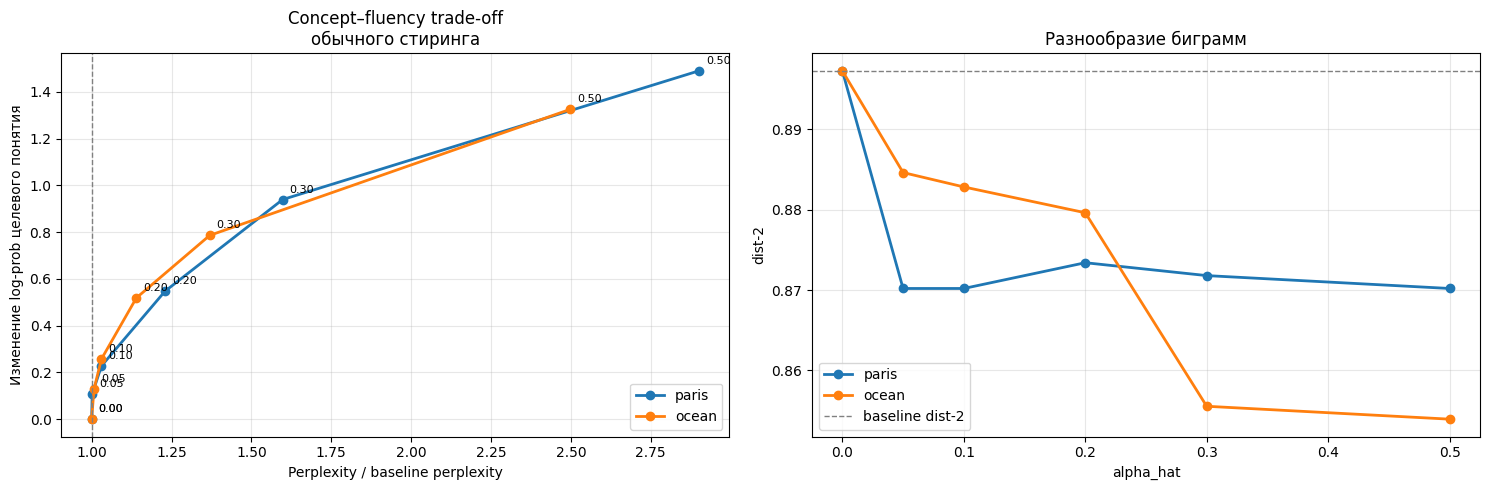


Файлы сохранены:


/kaggle/working/ordinary_steering_benchmark.csv

/kaggle/working/ordinary_steering_benchmark.pt

/kaggle/working/ordinary_steering_protocol.json

/kaggle/working/ordinary_steering_tradeoff.png

In [31]:
import matplotlib.pyplot as plt
from IPython.display import FileLink, display


ordinary_full_benchmark_df = (
    ordinary_benchmark_df.merge(
        ordinary_dist_df,
        on=[
            "concept",
            "alpha_hat",
        ],
        how="inner",
    )
)


final_columns = [
    "concept",
    "alpha_hat",
    "real_alpha",
    "target_delta",
    "control_delta",
    "specificity",
    "probability_multiplier",
    "positive_prompts",
    "total_prompts",
    "perplexity",
    "perplexity_ratio",
    "delta_log_perplexity",
    "dist_1",
    "dist_2",
    "dist_3",
    "mean_generated_tokens",
    "generation_count",
]


print("ИТОГОВЫЙ BENCHMARK ОБЫЧНОГО СТИРИНГА")
print()

display(
    ordinary_full_benchmark_df[
        final_columns
    ].round(4)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)


# Главный график:
# concept effect против ущерба perplexity.
for concept in ["paris", "ocean"]:
    concept_rows = (
        ordinary_full_benchmark_df[
            ordinary_full_benchmark_df[
                "concept"
            ] == concept
        ]
        .sort_values("alpha_hat")
    )

    axes[0].plot(
        concept_rows["perplexity_ratio"],
        concept_rows["target_delta"],
        marker="o",
        linewidth=2,
        label=concept,
    )

    for _, row in concept_rows.iterrows():
        axes[0].annotate(
            f"{row['alpha_hat']:.2f}",
            (
                row["perplexity_ratio"],
                row["target_delta"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )


axes[0].axvline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

axes[0].set_xlabel(
    "Perplexity / baseline perplexity"
)

axes[0].set_ylabel(
    "Изменение log-prob целевого понятия"
)

axes[0].set_title(
    "Concept–fluency trade-off\n"
    "обычного стиринга"
)

axes[0].grid(alpha=0.3)
axes[0].legend()


# Второй график:
# изменение разнообразия биграмм.
for concept in ["paris", "ocean"]:
    concept_rows = (
        ordinary_full_benchmark_df[
            ordinary_full_benchmark_df[
                "concept"
            ] == concept
        ]
        .sort_values("alpha_hat")
    )

    axes[1].plot(
        concept_rows["alpha_hat"],
        concept_rows["dist_2"],
        marker="o",
        linewidth=2,
        label=concept,
    )


baseline_dist_2 = (
    baseline_dist_metrics["dist_2"]
)

axes[1].axhline(
    baseline_dist_2,
    color="gray",
    linestyle="--",
    linewidth=1,
    label="baseline dist-2",
)

axes[1].set_xlabel("alpha_hat")
axes[1].set_ylabel("dist-2")

axes[1].set_title(
    "Разнообразие биграмм"
)

axes[1].grid(alpha=0.3)
axes[1].legend()


plt.tight_layout()

TRADEOFF_PLOT_PATH = (
    "/kaggle/working/"
    "ordinary_steering_tradeoff.png"
)

plt.savefig(
    TRADEOFF_PLOT_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


BENCHMARK_CSV_PATH = (
    "/kaggle/working/"
    "ordinary_steering_benchmark.csv"
)

BENCHMARK_STATE_PATH = (
    "/kaggle/working/"
    "ordinary_steering_benchmark.pt"
)

BENCHMARK_PROTOCOL_PATH = (
    "/kaggle/working/"
    "ordinary_steering_protocol.json"
)


ordinary_full_benchmark_df.to_csv(
    BENCHMARK_CSV_PATH,
    index=False,
)


with open(
    BENCHMARK_PROTOCOL_PATH,
    "w",
    encoding="utf-8",
) as protocol_file:
    json.dump(
        {
            "protocol":
                ordinary_benchmark_protocol,
            "protocol_hash":
                ordinary_benchmark_protocol_hash,
        },
        protocol_file,
        ensure_ascii=False,
        indent=2,
    )


torch.save(
    {
        "protocol":
            ordinary_benchmark_protocol,
        "protocol_hash":
            ordinary_benchmark_protocol_hash,

        "concept_results":
            ordinary_concept_results,

        "ppl_results":
            ordinary_ppl_results,

        "dist_results":
            ordinary_dist_results,

        "full_benchmark_records":
            ordinary_full_benchmark_df
            .to_dict(orient="records"),

        "generation_records":
            ordinary_generation_records,
    },
    BENCHMARK_STATE_PATH,
)


print("\nФайлы сохранены:")
display(FileLink(BENCHMARK_CSV_PATH))
display(FileLink(BENCHMARK_STATE_PATH))
display(FileLink(BENCHMARK_PROTOCOL_PATH))
display(FileLink(TRADEOFF_PLOT_PATH))

In [32]:
from pathlib import Path
from IPython.display import FileLink, display


required_metric_columns = [
    "target_delta",
    "specificity",
    "perplexity",
    "perplexity_ratio",
    "dist_1",
    "dist_2",
    "dist_3",
]

missing_metric_columns = [
    column
    for column in required_metric_columns
    if column
    not in ordinary_full_benchmark_df.columns
]

if missing_metric_columns:
    raise RuntimeError(
        "Отсутствуют столбцы: "
        + ", ".join(missing_metric_columns)
    )


if ordinary_full_benchmark_df[
    required_metric_columns
].isna().any().any():
    raise RuntimeError(
        "В итоговой таблице обнаружены NaN."
    )


print("DIST-МЕТРИКИ:")
display(
    ordinary_full_benchmark_df[
        [
            "concept",
            "alpha_hat",
            "dist_1",
            "dist_2",
            "dist_3",
            "mean_generated_tokens",
        ]
    ].round(4)
)


saved_paths = [
    "/kaggle/working/ordinary_steering_benchmark.csv",
    "/kaggle/working/ordinary_steering_benchmark.pt",
    "/kaggle/working/ordinary_steering_protocol.json",
    "/kaggle/working/ordinary_steering_tradeoff.png",
]

print("\nПРОВЕРКА ФАЙЛОВ:")

for path_string in saved_paths:
    path = Path(path_string)

    if not path.exists():
        raise FileNotFoundError(
            f"Файл не найден: {path}"
        )

    print(
        path.name,
        "—",
        round(path.stat().st_size / 1024, 1),
        "КБ",
    )

    display(FileLink(str(path)))


print("\nПункты 1–3 успешно зафиксированы.")

DIST-МЕТРИКИ:


,concept,alpha_hat,dist_1,dist_2,dist_3,mean_generated_tokens
0,paris,0.00,0.5023,0.8973,0.9605,39.9375
1,paris,0.05,0.4953,0.8702,0.9589,40.0000
2,paris,0.10,0.4812,0.8702,0.9720,40.0000
3,paris,0.20,0.4969,0.8734,0.9589,40.0000
4,paris,0.30,0.4953,0.8718,0.9589,40.0000
5,paris,0.50,0.4828,0.8702,0.9556,40.0000
6,ocean,0.00,0.5023,0.8973,0.9605,39.9375
7,ocean,0.05,0.4859,0.8846,0.9688,40.0000
8,ocean,0.10,0.4883,0.8828,0.9654,39.9375
9,ocean,0.20,0.4914,0.8796,0.9621,39.9375



ПРОВЕРКА ФАЙЛОВ:
ordinary_steering_benchmark.csv — 3.5 КБ


/kaggle/working/ordinary_steering_benchmark.csv

ordinary_steering_benchmark.pt — 111.0 КБ


...

ordinary_steering_protocol.json — 2.3 КБ


/kaggle/working/ordinary_steering_protocol.json

ordinary_steering_tradeoff.png — 139.0 КБ


/kaggle/working/ordinary_steering_tradeoff.png


Пункты 1–3 успешно зафиксированы.


In [33]:
import os
import zipfile
from pathlib import Path
from IPython.display import FileLink, display


working_directory = Path(
    "/kaggle/working"
)

files_to_archive = [
    working_directory
    / "ordinary_steering_benchmark.csv",

    working_directory
    / "ordinary_steering_benchmark.pt",

    working_directory
    / "ordinary_steering_protocol.json",

    working_directory
    / "ordinary_steering_tradeoff.png",
]

archive_path = (
    working_directory
    / "ordinary_steering_results.zip"
)


for file_path in files_to_archive:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Файл не найден: {file_path}"
        )


with zipfile.ZipFile(
    archive_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for file_path in files_to_archive:
        archive.write(
            file_path,
            arcname=file_path.name,
        )


print("Архив создан:")
print(archive_path)

print(
    "Размер:",
    round(
        archive_path.stat().st_size
        / 1024
        / 1024,
        2,
    ),
    "МБ",
)

print("\nСодержимое архива:")

with zipfile.ZipFile(
    archive_path,
    mode="r",
) as archive:
    for name in archive.namelist():
        print(" •", name)


# FileLink у Kaggle лучше работает
# с относительным путём.
os.chdir("/kaggle/working")

print("\nСсылка для скачивания:")
display(
    FileLink(
        "ordinary_steering_results.zip"
    )
)

Архив создан:
/kaggle/working/ordinary_steering_results.zip
Размер: 0.16 МБ

Содержимое архива:
 • ordinary_steering_benchmark.csv
 • ordinary_steering_benchmark.pt
 • ordinary_steering_protocol.json
 • ordinary_steering_tradeoff.png

Ссылка для скачивания:


/kaggle/working/ordinary_steering_results.zip

In [3]:
import sys
import subprocess
import importlib.util
from pathlib import Path

# ---------------------------------------------------------
# 1. Проверяем и при необходимости устанавливаем библиотеки
# ---------------------------------------------------------

packages_to_install = []

if importlib.util.find_spec("transformer_lens") is None:
    packages_to_install.append("transformer_lens")

if importlib.util.find_spec("blobfile") is None:
    packages_to_install.append("blobfile==2.0.2")

if packages_to_install:
    print("Устанавливаем недостающие библиотеки...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *packages_to_install,
        ],
        check=True,
    )
else:
    print("Необходимые библиотеки уже установлены")

# ---------------------------------------------------------
# 2. Подключаем репозиторий OpenAI SAE
# ---------------------------------------------------------

repo_dir = Path(
    "/kaggle/working/openai_sparse_autoencoder"
)

if not repo_dir.exists():
    print("Скачиваем OpenAI sparse_autoencoder...")

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/openai/sparse_autoencoder.git",
            str(repo_dir),
        ],
        check=True,
    )

if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

# ---------------------------------------------------------
# 3. Импортируем библиотеки
# ---------------------------------------------------------

import torch
import blobfile as bf
import sparse_autoencoder

from transformer_lens import HookedTransformer

# ---------------------------------------------------------
# 4. Проверяем GPU
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if device.type != "cuda":
    raise RuntimeError(
        "GPU не найден. В Kaggle выбери Settings → "
        "Accelerator → GPU T4 x2."
    )

print("Устройство:", device)
print("GPU:", torch.cuda.get_device_name(0))

# ---------------------------------------------------------
# 5. Загружаем GPT-2 Small
# ---------------------------------------------------------

model = HookedTransformer.from_pretrained(
    "gpt2-small",
    device=device,
    center_writing_weights=False,
)

model.eval()

for parameter in model.parameters():
    parameter.requires_grad = False

layer_index = 6
hook_name = "blocks.6.hook_resid_post"
d_model = model.cfg.d_model

print("GPT-2 загружена")
print("Количество блоков:", model.cfg.n_layers)
print("Размер активации:", d_model)
print("Точка интервенции:", hook_name)

# ---------------------------------------------------------
# 6. Загружаем SAE для того же слоя
# ---------------------------------------------------------

checkpoint_path = sparse_autoencoder.paths.v5_32k(
    "resid_post_mlp",
    layer_index,
)

print("Загружаем SAE:")
print(checkpoint_path)

with bf.BlobFile(checkpoint_path, mode="rb") as file:
    state_dict = torch.load(
        file,
        map_location="cpu",
        weights_only=False,
    )

sae = sparse_autoencoder.Autoencoder.from_state_dict(
    state_dict
)

sae = sae.to(device)
sae.eval()

for parameter in sae.parameters():
    parameter.requires_grad = False

print("SAE загружен")
print("Энкодер:", sae.encoder.weight.shape)
print("Декодер:", sae.decoder.weight.shape)

# ---------------------------------------------------------
# 7. Восстанавливаем служебные значения
# ---------------------------------------------------------

REFERENCE_NORM = 88.58959197998047

def get_steering_vector(feature_index):

    vector = (
        sae.decoder.weight[:, feature_index]
        .detach()
        .clone()
    )

    return vector / vector.norm().clamp_min(1e-12)

print("\nСреда полностью восстановлена")
print("REFERENCE_NORM:", REFERENCE_NORM)

Устанавливаем недостающие библиотеки...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 33.2 MB/s eta 0:00:00
Скачиваем OpenAI sparse_autoencoder...


Cloning into '/kaggle/working/openai_sparse_autoencoder'...


Устройство: cuda
GPU: Tesla T4


/tmp/ipykernel_58/3965289375.py:92: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
GPT-2 загружена
Количество блоков: 12
Размер активации: 768
Точка интервенции: blocks.6.hook_resid_post
Загружаем SAE:
az://openaipublic/sparse-autoencoder/gpt2-small/resid_post_mlp_v5_32k/autoencoders/6.pt
SAE загружен
Энкодер: torch.Size([32768, 768])
Декодер: torch.Size([768, 32768])

Среда полностью восстановлена
REFERENCE_NORM: 88.58959197998047


In [13]:
import json
import hashlib
import random
import numpy as np
import torch


# Векторы для выбора гиперпараметров после обучения.
# Веса денойзера их не увидят.
DEVELOPMENT_FEATURES = {
    "opera": 28999,
    "banana": 31031,
    "blanket": 31117,
    "football": 11220,
}


# Финальные векторы.
# Их нельзя использовать ни при обучении,
# ни при выборе гиперпараметров.
FINAL_HELDOUT_FEATURES = {
    "paris": 2252,
    "ocean": 24664,
}


PROTECTED_FEATURE_INDICES = sorted(
    set(DEVELOPMENT_FEATURES.values())
    | set(FINAL_HELDOUT_FEATURES.values())
)


assert len(PROTECTED_FEATURE_INDICES) == 6
assert not (
    set(DEVELOPMENT_FEATURES.values())
    & set(FINAL_HELDOUT_FEATURES.values())
)


PRD_TRAINING_PROTOCOL = {
    "method": "Projected Residual Denoising",

    "model": "gpt2-small",
    "layer_index": 6,
    "hook_name":
        "blocks.6.hook_resid_post",
    "d_model": 768,

    "development_features":
        DEVELOPMENT_FEATURES,

    "final_heldout_features":
        FINAL_HELDOUT_FEATURES,

    "protected_feature_indices":
        PROTECTED_FEATURE_INDICES,

    # Чистые активации
    "max_activations": 30_000,
    "train_activations": 27_000,
    "validation_activations": 3_000,

    # Смесь обучающего шума
    "identity_probability": 0.10,
    "gaussian_probability": 0.45,
    "random_sae_probability": 0.45,
    "maximum_relative_strength": 0.50,

    # Архитектура
    "hidden_size": 1024,
    "strength_embedding_size": 64,

    # Обучение
    "batch_size": 512,
    "maximum_epochs": 20,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "identity_loss_weight": 0.10,
    "early_stopping_patience": 3,

    "random_seed": 2026,

    # Главное ограничение
    "protected_vectors_used_in_training":
        False,
}


protocol_text = json.dumps(
    PRD_TRAINING_PROTOCOL,
    sort_keys=True,
    ensure_ascii=False,
)

PRD_TRAINING_PROTOCOL_HASH = (
    hashlib.sha256(
        protocol_text.encode("utf-8")
    ).hexdigest()
)


# Фиксируем случайность.
random.seed(
    PRD_TRAINING_PROTOCOL["random_seed"]
)

np.random.seed(
    PRD_TRAINING_PROTOCOL["random_seed"]
)

torch.manual_seed(
    PRD_TRAINING_PROTOCOL["random_seed"]
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        PRD_TRAINING_PROTOCOL[
            "random_seed"
        ]
    )


print("Протокол PRD зафиксирован")
print(
    "Development-векторы:",
    DEVELOPMENT_FEATURES,
)
print(
    "Финальные holdout-векторы:",
    FINAL_HELDOUT_FEATURES,
)
print(
    "Все защищённые индексы:",
    PROTECTED_FEATURE_INDICES,
)
print(
    "Пересечение development и final:",
    set(DEVELOPMENT_FEATURES.values())
    & set(FINAL_HELDOUT_FEATURES.values()),
)
print(
    "SHA-256 протокола:",
    PRD_TRAINING_PROTOCOL_HASH,
)

Протокол PRD зафиксирован
Development-векторы: {'opera': 28999, 'banana': 31031, 'blanket': 31117, 'football': 11220}
Финальные holdout-векторы: {'paris': 2252, 'ocean': 24664}
Все защищённые индексы: [2252, 11220, 24664, 28999, 31031, 31117]
Пересечение development и final: set()
SHA-256 протокола: 16c4b3e9df2fa0b8b1b019bf9f40856d1b5dc0969bd42e5fdc15774fdefca031


In [18]:
import gc
from pathlib import Path
from datasets import load_dataset


required_objects = [
    "model",
    "sae",
    "device",
    "hook_name",
    "d_model",
    "REFERENCE_NORM",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "В памяти отсутствуют объекты: "
        + ", ".join(missing_objects)
    )


print("Загружаем WikiText train...")

wiki_train = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="train",
)


MAX_ACTIVATIONS = 30_000
ACTIVATION_SEQUENCE_LENGTH = 64
ACTIVATION_BATCH_SIZE = 8

# Небольшой запас нужен, чтобы получить
# не меньше 30 000 токенов после разбиения.
required_token_count = (
    MAX_ACTIVATIONS
    + 8 * ACTIVATION_SEQUENCE_LENGTH
)


training_token_ids = []

for row in wiki_train:
    text = row["text"].strip()

    if not text:
        continue

    line_token_ids = (
        model.tokenizer.encode(
            text,
            add_special_tokens=False,
        )
    )

    training_token_ids.extend(
        line_token_ids
    )

    # Разделяем независимые строки.
    training_token_ids.append(
        model.tokenizer.eos_token_id
    )

    if (
        len(training_token_ids)
        >= required_token_count
    ):
        break


training_token_stream = torch.tensor(
    training_token_ids,
    dtype=torch.long,
)


usable_token_count = (
    len(training_token_stream)
    // ACTIVATION_SEQUENCE_LENGTH
    * ACTIVATION_SEQUENCE_LENGTH
)


training_token_chunks = (
    training_token_stream[
        :usable_token_count
    ]
    .reshape(
        -1,
        ACTIVATION_SEQUENCE_LENGTH,
    )
)


print(
    "Подготовлено токенов:",
    len(training_token_stream),
)

print(
    "Форма фрагментов:",
    training_token_chunks.shape,
)

print("\nНачинаем сбор активаций...")


activation_parts = []
collected_count = 0


with torch.no_grad():
    for batch_start in range(
        0,
        len(training_token_chunks),
        ACTIVATION_BATCH_SIZE,
    ):
        batch_tokens = (
            training_token_chunks[
                batch_start:
                batch_start
                + ACTIVATION_BATCH_SIZE
            ]
            .to(device)
        )

        _, cache = model.run_with_cache(
            batch_tokens,
            return_type=None,
            names_filter=lambda name:
                name == hook_name,
        )

        batch_h = (
            cache[hook_name]
            .reshape(-1, d_model)
            .float()
            .cpu()
        )

        activation_parts.append(batch_h)

        collected_count += len(batch_h)

        del cache
        del batch_h
        del batch_tokens

        if collected_count % 5120 == 0:
            print(
                "Собрано активаций:",
                collected_count,
            )

        if collected_count >= MAX_ACTIVATIONS:
            break


all_clean_h = torch.cat(
    activation_parts,
    dim=0,
)[:MAX_ACTIVATIONS]


# Детерминированно перемешиваем.
split_generator = (
    torch.Generator()
    .manual_seed(2026)
)

permutation = torch.randperm(
    len(all_clean_h),
    generator=split_generator,
)

all_clean_h = (
    all_clean_h[permutation]
    .contiguous()
)


split_index = 27_000

train_h = (
    all_clean_h[:split_index]
    .contiguous()
)

validation_h = (
    all_clean_h[split_index:]
    .contiguous()
)


training_activation_norm = (
    train_h.norm(dim=-1)
    .median()
    .item()
)


relative_norm_difference = (
    abs(
        training_activation_norm
        - REFERENCE_NORM
    )
    / REFERENCE_NORM
)


print("\nСбор завершён")
print(
    "Все активации:",
    all_clean_h.shape,
)
print(
    "Обучающие:",
    train_h.shape,
)
print(
    "Валидационные:",
    validation_h.shape,
)
print(
    "Медианная норма:",
    round(
        training_activation_norm,
        4,
    ),
)
print(
    "REFERENCE_NORM:",
    round(
        REFERENCE_NORM,
        4,
    ),
)
print(
    "Относительная разница:",
    round(
        relative_norm_difference,
        4,
    ),
)


if relative_norm_difference > 0.10:
    print(
        "ПРЕДУПРЕЖДЕНИЕ: нормы различаются "
        "больше чем на 10%."
    )
else:
    print(
        "Проверка масштаба активаций пройдена"
    )


CLEAN_ACTIVATIONS_PATH = Path(
    "/kaggle/working/"
    "prd_clean_activations.pt"
)


torch.save(
    {
        # На диск сохраняем float16,
        # чтобы уменьшить размер файла.
        "train_h": train_h.half(),
        "validation_h":
            validation_h.half(),

        "metadata": {
            "source":
                "Salesforce/"
                "wikitext-2-raw-v1/train",

            "layer_index": 6,
            "hook_name": hook_name,
            "d_model": d_model,

            "train_count":
                len(train_h),

            "validation_count":
                len(validation_h),

            "reference_norm":
                float(REFERENCE_NORM),

            "training_activation_norm":
                training_activation_norm,

            "protocol_hash":
                PRD_TRAINING_PROTOCOL_HASH,

            "random_seed": 2026,
        },
    },
    CLEAN_ACTIVATIONS_PATH,
)


print(
    "\nФайл сохранён:",
    CLEAN_ACTIVATIONS_PATH,
)

print(
    "Размер файла:",
    round(
        CLEAN_ACTIVATIONS_PATH.stat().st_size
        / 1024
        / 1024,
        2,
    ),
    "МБ",
)


del activation_parts

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Загружаем WikiText train...
Подготовлено токенов: 30654
Форма фрагментов: torch.Size([478, 64])

Начинаем сбор активаций...
Собрано активаций: 5120
Собрано активаций: 10240
Собрано активаций: 15360
Собрано активаций: 20480
Собрано активаций: 25600

Сбор завершён
Все активации: torch.Size([30000, 768])
Обучающие: torch.Size([27000, 768])
Валидационные: torch.Size([3000, 768])
Медианная норма: 88.7398
REFERENCE_NORM: 88.5896
Относительная разница: 0.0017
Проверка масштаба активаций пройдена

Файл сохранён: /kaggle/working/prd_clean_activations.pt
Размер файла: 43.95 МБ


In [22]:
# =========================================================
# ГЕНЕРАТОР ОБУЧАЮЩИХ ИСКАЖЕНИЙ ДЛЯ PRD
# =========================================================

# Векторы для настройки метода после обучения
DEVELOPMENT_FEATURES = {
    "opera": 28999,
    "banana": 31031,
    "blanket": 31117,
    "football": 11220,
}

# Векторы только для финальной проверки
FINAL_HELDOUT_FEATURES = {
    "paris": 2252,
    "ocean": 24664,
}

# Ни один из этих признаков нельзя использовать
# при создании обучающих искажений
PROTECTED_FEATURE_INDICES = sorted(
    set(DEVELOPMENT_FEATURES.values())
    | set(FINAL_HELDOUT_FEATURES.values())
)

print(
    "Защищённые SAE-признаки:",
    PROTECTED_FEATURE_INDICES,
)

# ---------------------------------------------------------
# Создаём список разрешённых SAE-признаков
# ---------------------------------------------------------

number_of_sae_features = (
    sae.decoder.weight.shape[1]
)

all_feature_indices = torch.arange(
    number_of_sae_features,
    dtype=torch.long,
)

allowed_mask = torch.ones(
    number_of_sae_features,
    dtype=torch.bool,
)

allowed_mask[PROTECTED_FEATURE_INDICES] = False

TRAINING_SAE_FEATURE_INDICES = (
    all_feature_indices[allowed_mask]
    .to(device)
)

print(
    "Всего SAE-признаков:",
    number_of_sae_features,
)

print(
    "Разрешено для обучения:",
    len(TRAINING_SAE_FEATURE_INDICES),
)

print(
    "Исключено из обучения:",
    number_of_sae_features
    - len(TRAINING_SAE_FEATURE_INDICES),
)

# ---------------------------------------------------------
# Зафиксированные параметры зашумления
# ---------------------------------------------------------

IDENTITY_PROBABILITY = 0.10
GAUSSIAN_PROBABILITY = 0.45
SAE_PROBABILITY = 0.45

MAX_TRAIN_STRENGTH = 0.50

assert abs(
    IDENTITY_PROBABILITY
    + GAUSSIAN_PROBABILITY
    + SAE_PROBABILITY
    - 1.0
) < 1e-8

# Типы искажения:
# 0 — активация остаётся чистой
# 1 — случайное гауссовское направление
# 2 — случайный разрешённый SAE-вектор


@torch.no_grad()
def create_prd_corruption(
    clean_h,
    generator=None,
):
    """
    Создаёт обучающую пару:

        noisy_h = clean_h + true_noise

    Возвращает:
        noisy_h
        true_noise
        strength
        noise_type
        sampled_sae_indices
    """

    clean_h = clean_h.to(
        device=device,
        dtype=torch.float32,
    )

    batch_size = clean_h.shape[0]

    # Выбираем тип искажения для каждого примера
    type_draw = torch.rand(
        batch_size,
        device=device,
        generator=generator,
    )

    noise_type = torch.full(
        (batch_size,),
        fill_value=2,
        dtype=torch.long,
        device=device,
    )

    noise_type[
        type_draw < IDENTITY_PROBABILITY
    ] = 0

    noise_type[
        (
            type_draw >= IDENTITY_PROBABILITY
        )
        & (
            type_draw
            < IDENTITY_PROBABILITY
            + GAUSSIAN_PROBABILITY
        )
    ] = 1

    # Сила искажения от 0 до 0.5
    strength = (
        torch.rand(
            batch_size,
            device=device,
            generator=generator,
        )
        * MAX_TRAIN_STRENGTH
    )

    # Для чистых примеров сила равна нулю
    strength[noise_type == 0] = 0.0

    direction = torch.zeros_like(clean_h)

    # Для примеров без SAE-направления оставляем -1
    sampled_sae_indices = torch.full(
        (batch_size,),
        fill_value=-1,
        dtype=torch.long,
        device=device,
    )

    # -----------------------------------------------------
    # Гауссовские направления
    # -----------------------------------------------------

    gaussian_positions = torch.where(
        noise_type == 1
    )[0]

    if len(gaussian_positions) > 0:

        gaussian_directions = torch.randn(
            len(gaussian_positions),
            d_model,
            device=device,
            generator=generator,
        )

        gaussian_directions = (
            gaussian_directions
            / gaussian_directions.norm(
                dim=-1,
                keepdim=True,
            ).clamp_min(1e-12)
        )

        direction[gaussian_positions] = (
            gaussian_directions
        )

    # -----------------------------------------------------
    # Случайные разрешённые SAE-направления
    # -----------------------------------------------------

    sae_positions = torch.where(
        noise_type == 2
    )[0]

    if len(sae_positions) > 0:

        random_positions = torch.randint(
            low=0,
            high=len(
                TRAINING_SAE_FEATURE_INDICES
            ),
            size=(len(sae_positions),),
            device=device,
            generator=generator,
        )

        selected_indices = (
            TRAINING_SAE_FEATURE_INDICES[
                random_positions
            ]
        )

        sampled_sae_indices[
            sae_positions
        ] = selected_indices

        sae_directions = (
            sae.decoder.weight[
                :,
                selected_indices,
            ]
            .T
            .detach()
            .float()
        )

        sae_directions = (
            sae_directions
            / sae_directions.norm(
                dim=-1,
                keepdim=True,
            ).clamp_min(1e-12)
        )

        direction[sae_positions] = (
            sae_directions
        )

    # Реальный масштаб:
    #
    # alpha = alpha_hat * REFERENCE_NORM
    #
    true_noise = (
        strength[:, None]
        * REFERENCE_NORM
        * direction
    )

    noisy_h = clean_h + true_noise

    return {
        "noisy_h": noisy_h,
        "true_noise": true_noise,
        "strength": strength,
        "noise_type": noise_type,
        "sampled_sae_indices": (
            sampled_sae_indices
        ),
    }


print("Генератор зашумления создан")

Защищённые SAE-признаки: [2252, 11220, 24664, 28999, 31031, 31117]
Всего SAE-признаков: 32768
Разрешено для обучения: 32762
Исключено из обучения: 6
Генератор зашумления создан


In [23]:
# =========================================================
# АУДИТ ГЕНЕРАТОРА ОБУЧАЮЩИХ ИСКАЖЕНИЙ
# =========================================================

AUDIT_EXAMPLES = 20_000
AUDIT_BATCH_SIZE = 512

audit_generator = torch.Generator(
    device=device
)

audit_generator.manual_seed(2026)

type_counts = torch.zeros(
    3,
    dtype=torch.long,
)

protected_occurrences = 0
maximum_scale_error = 0.0
observed_maximum_strength = 0.0

processed = 0

while processed < AUDIT_EXAMPLES:

    current_batch_size = min(
        AUDIT_BATCH_SIZE,
        AUDIT_EXAMPLES - processed,
    )

    # Для аудита достаточно любых чистых
    # активаций нужного размера
    clean_batch = train_h[
        :current_batch_size
    ]

    corruption = create_prd_corruption(
        clean_batch,
        generator=audit_generator,
    )

    noise_type = (
        corruption["noise_type"]
        .detach()
        .cpu()
    )

    sampled_indices = (
        corruption["sampled_sae_indices"]
        .detach()
        .cpu()
    )

    strength = corruption["strength"]

    true_noise = corruption["true_noise"]

    type_counts += torch.bincount(
        noise_type,
        minlength=3,
    )

    # Проверяем каждый защищённый индекс
    for protected_index in (
        PROTECTED_FEATURE_INDICES
    ):
        protected_occurrences += int(
            (
                sampled_indices
                == protected_index
            )
            .sum()
            .item()
        )

    # Поскольку направления единичные:
    #
    # ||noise|| / REFERENCE_NORM
    #
    # должно совпадать со strength
    observed_strength = (
        true_noise.norm(dim=-1)
        / REFERENCE_NORM
    )

    scale_error = (
        observed_strength - strength
    ).abs().max().item()

    maximum_scale_error = max(
        maximum_scale_error,
        scale_error,
    )

    observed_maximum_strength = max(
        observed_maximum_strength,
        strength.max().item(),
    )

    processed += current_batch_size

type_frequencies = (
    type_counts.float()
    / type_counts.sum()
)

print("Проверено примеров:", AUDIT_EXAMPLES)

print("\nЧастоты типов шума:")
print(
    "Без искажения:",
    f"{type_frequencies[0].item():.4f}",
)
print(
    "Гауссовский шум:",
    f"{type_frequencies[1].item():.4f}",
)
print(
    "Случайный SAE-вектор:",
    f"{type_frequencies[2].item():.4f}",
)

print(
    "\nПопаданий защищённых признаков:",
    protected_occurrences,
)

print(
    "Максимальная сила:",
    f"{observed_maximum_strength:.6f}",
)

print(
    "Максимальная ошибка масштаба:",
    f"{maximum_scale_error:.8f}",
)

# ---------------------------------------------------------
# Жёсткие автоматические проверки
# ---------------------------------------------------------

assert protected_occurrences == 0, (
    "Обнаружена утечка защищённого "
    "SAE-признака!"
)

assert observed_maximum_strength <= (
    MAX_TRAIN_STRENGTH + 1e-6
)

assert maximum_scale_error < 1e-5

assert abs(
    type_frequencies[0].item() - 0.10
) < 0.02

assert abs(
    type_frequencies[1].item() - 0.45
) < 0.03

assert abs(
    type_frequencies[2].item() - 0.45
) < 0.03

print(
    "\nАУДИТ ПРОЙДЕН:"
    "\nзащищённые векторы не используются"
    "\nмасштаб искажений рассчитан правильно"
)

Проверено примеров: 20000

Частоты типов шума:
Без искажения: 0.1011
Гауссовский шум: 0.4555
Случайный SAE-вектор: 0.4433

Попаданий защищённых признаков: 0
Максимальная сила: 0.499954
Максимальная ошибка масштаба: 0.00000006

АУДИТ ПРОЙДЕН:
защищённые векторы не используются
масштаб искажений рассчитан правильно


In [25]:
# =========================================================
# УСЛОВНЫЙ ОСТАТОЧНЫЙ ДЕНОЙЗЕР
# =========================================================

import torch.nn as nn
import torch.nn.functional as F

DENOISER_HIDDEN_DIM = 1024
STRENGTH_EMBEDDING_DIM = 64


class ConditionalResidualDenoiser(nn.Module):

    def __init__(
        self,
        d_model,
        hidden_dim=1024,
        strength_embedding_dim=64,
    ):
        super().__init__()

        # Нормализуем входную активацию,
        # не изменяя саму GPT-2
        self.input_norm = nn.LayerNorm(
            d_model
        )

        # Кодируем alpha_hat в вектор
        self.strength_encoder = nn.Sequential(
            nn.Linear(
                1,
                strength_embedding_dim,
            ),
            nn.SiLU(),
            nn.Linear(
                strength_embedding_dim,
                strength_embedding_dim,
            ),
            nn.SiLU(),
        )

        # Предсказываем добавленный шум
        self.residual_network = nn.Sequential(
            nn.Linear(
                d_model
                + strength_embedding_dim,
                hidden_dim,
            ),
            nn.GELU(),

            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.GELU(),

            nn.Linear(
                hidden_dim,
                d_model,
            ),
        )

        # Изначально денойзер ничего не исправляет.
        # Это безопасная стартовая точка:
        #
        # predicted_noise = 0
        output_layer = (
            self.residual_network[-1]
        )

        nn.init.zeros_(
            output_layer.weight
        )

        nn.init.zeros_(
            output_layer.bias
        )

    def forward(
        self,
        noisy_h,
        strength,
    ):

        if strength.ndim == 1:
            strength = strength[:, None]

        normalized_h = self.input_norm(
            noisy_h
        )

        strength_embedding = (
            self.strength_encoder(
                strength.float()
            )
        )

        network_input = torch.cat(
            [
                normalized_h,
                strength_embedding,
            ],
            dim=-1,
        )

        predicted_noise = (
            self.residual_network(
                network_input
            )
        )

        return predicted_noise


# Воспроизводимая инициализация
torch.manual_seed(2026)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(2026)

denoiser = ConditionalResidualDenoiser(
    d_model=d_model,
    hidden_dim=DENOISER_HIDDEN_DIM,
    strength_embedding_dim=(
        STRENGTH_EMBEDDING_DIM
    ),
).to(device)

number_of_parameters = sum(
    parameter.numel()
    for parameter in denoiser.parameters()
)

number_of_trainable_parameters = sum(
    parameter.numel()
    for parameter in denoiser.parameters()
    if parameter.requires_grad
)

print("Денойзер создан")
print(
    "Количество параметров:",
    f"{number_of_parameters:,}",
)
print(
    "Обучаемых параметров:",
    f"{number_of_trainable_parameters:,}",
)

# ---------------------------------------------------------
# Проверяем один тестовый batch
# ---------------------------------------------------------

test_generator = torch.Generator(
    device=device
)

test_generator.manual_seed(2026)

test_clean_h = train_h[:128]

test_corruption = create_prd_corruption(
    test_clean_h,
    generator=test_generator,
)

with torch.no_grad():

    test_prediction = denoiser(
        test_corruption["noisy_h"],
        test_corruption["strength"],
    )

print(
    "Форма входа:",
    test_corruption["noisy_h"].shape,
)

print(
    "Форма предсказания:",
    test_prediction.shape,
)

print(
    "Максимальное начальное предсказание:",
    test_prediction.abs().max().item(),
)

# ---------------------------------------------------------
# Проверяем, что GPT-2 и SAE заморожены
# ---------------------------------------------------------

gpt2_trainable = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

sae_trainable = sum(
    parameter.numel()
    for parameter in sae.parameters()
    if parameter.requires_grad
)

print(
    "Обучаемых параметров GPT-2:",
    gpt2_trainable,
)

print(
    "Обучаемых параметров SAE:",
    sae_trainable,
)

assert test_prediction.shape == (
    128,
    d_model,
)

assert (
    test_prediction.abs().max().item()
    == 0.0
)

assert gpt2_trainable == 0
assert sae_trainable == 0

print(
    "\nАРХИТЕКТУРА ПРОШЛА ПРОВЕРКУ"
)

Денойзер создан
Количество параметров: 2,695,616
Обучаемых параметров: 2,695,616
Форма входа: torch.Size([128, 768])
Форма предсказания: torch.Size([128, 768])
Максимальное начальное предсказание: 0.0
Обучаемых параметров GPT-2: 0
Обучаемых параметров SAE: 0

АРХИТЕКТУРА ПРОШЛА ПРОВЕРКУ


In [26]:
# =========================================================
# ФИКСИРОВАННЫЙ ВАЛИДАЦИОННЫЙ НАБОР
# =========================================================

VALIDATION_BATCH_SIZE = 512

validation_generator = torch.Generator(
    device=device
)

validation_generator.manual_seed(42026)

validation_noisy_parts = []
validation_noise_parts = []
validation_strength_parts = []
validation_type_parts = []
validation_index_parts = []

print(
    "Создаём фиксированные "
    "валидационные искажения..."
)

for start in range(
    0,
    len(validation_h),
    VALIDATION_BATCH_SIZE,
):

    clean_batch = validation_h[
        start:
        start + VALIDATION_BATCH_SIZE
    ]

    corruption = create_prd_corruption(
        clean_batch,
        generator=validation_generator,
    )

    validation_noisy_parts.append(
        corruption["noisy_h"]
        .detach()
        .cpu()
    )

    validation_noise_parts.append(
        corruption["true_noise"]
        .detach()
        .cpu()
    )

    validation_strength_parts.append(
        corruption["strength"]
        .detach()
        .cpu()
    )

    validation_type_parts.append(
        corruption["noise_type"]
        .detach()
        .cpu()
    )

    validation_index_parts.append(
        corruption[
            "sampled_sae_indices"
        ]
        .detach()
        .cpu()
    )

fixed_validation = {
    "clean_h": validation_h.float(),
    "noisy_h": torch.cat(
        validation_noisy_parts,
        dim=0,
    ),
    "true_noise": torch.cat(
        validation_noise_parts,
        dim=0,
    ),
    "strength": torch.cat(
        validation_strength_parts,
        dim=0,
    ),
    "noise_type": torch.cat(
        validation_type_parts,
        dim=0,
    ),
    "sampled_sae_indices": torch.cat(
        validation_index_parts,
        dim=0,
    ),
}

validation_type_counts = torch.bincount(
    fixed_validation["noise_type"],
    minlength=3,
)

validation_type_frequencies = (
    validation_type_counts.float()
    / validation_type_counts.sum()
)

# Проверяем утечку ещё раз
validation_protected_occurrences = 0

for protected_index in (
    PROTECTED_FEATURE_INDICES
):
    validation_protected_occurrences += int(
        (
            fixed_validation[
                "sampled_sae_indices"
            ]
            == protected_index
        )
        .sum()
        .item()
    )

# Ошибка до применения денойзера
initial_corruption_mse = (
    (
        fixed_validation["noisy_h"]
        - fixed_validation["clean_h"]
    )
    .pow(2)
    .mean()
    .item()
)

print(
    "Чистые активации:",
    fixed_validation["clean_h"].shape,
)

print(
    "Зашумлённые активации:",
    fixed_validation["noisy_h"].shape,
)

print(
    "Истинный шум:",
    fixed_validation["true_noise"].shape,
)

print("\nЧастоты типов:")
print(
    "Без искажения:",
    f"{validation_type_frequencies[0]:.4f}",
)
print(
    "Гауссовский:",
    f"{validation_type_frequencies[1]:.4f}",
)
print(
    "SAE-вектор:",
    f"{validation_type_frequencies[2]:.4f}",
)

print(
    "\nПопаданий защищённых признаков:",
    validation_protected_occurrences,
)

print(
    "Исходная MSE зашумления:",
    f"{initial_corruption_mse:.6f}",
)

assert validation_protected_occurrences == 0

assert fixed_validation["clean_h"].shape == (
    3000,
    768,
)

assert fixed_validation["noisy_h"].shape == (
    3000,
    768,
)

# Сохраняем фиксированную валидацию
validation_path = (
    "/kaggle/working/"
    "prd_fixed_validation.pt"
)

torch.save(
    {
        "clean_h": (
            fixed_validation["clean_h"]
            .half()
        ),
        "noisy_h": (
            fixed_validation["noisy_h"]
            .half()
        ),
        "true_noise": (
            fixed_validation["true_noise"]
            .half()
        ),
        "strength": (
            fixed_validation["strength"]
        ),
        "noise_type": (
            fixed_validation["noise_type"]
        ),
        "sampled_sae_indices": (
            fixed_validation[
                "sampled_sae_indices"
            ]
        ),
        "protected_feature_indices": (
            PROTECTED_FEATURE_INDICES
        ),
        "seed": 42026,
    },
    validation_path,
)

print(
    "\nФиксированная валидация сохранена:",
    validation_path,
)

print(
    "ВАЛИДАЦИОННЫЙ НАБОР ГОТОВ"
)

Создаём фиксированные валидационные искажения...
Чистые активации: torch.Size([3000, 768])
Зашумлённые активации: torch.Size([3000, 768])
Истинный шум: torch.Size([3000, 768])

Частоты типов:
Без искажения: 0.0920
Гауссовский: 0.4607
SAE-вектор: 0.4473

Попаданий защищённых признаков: 0
Исходная MSE зашумления: 0.764037

Фиксированная валидация сохранена: /kaggle/working/prd_fixed_validation.pt
ВАЛИДАЦИОННЫЙ НАБОР ГОТОВ


In [28]:
# =========================================================
# LOSS И ВАЛИДАЦИЯ ДЕНОЙЗЕРА
# =========================================================

import math
import copy
import gc
import pandas as pd

IDENTITY_LOSS_WEIGHT = 0.10
VALIDATION_EVAL_BATCH_SIZE = 512


def normalized_prediction_mse(
    prediction,
    target,
    clean_reference,
):
    """
    MSE нормируется энергией чистой активации.

    Это делает loss сопоставимым для активаций
    немного разного масштаба.
    """

    prediction_error = (
        prediction - target
    ).pow(2).mean(dim=-1)

    clean_energy = (
        clean_reference
        .pow(2)
        .mean(dim=-1)
        .clamp_min(1e-8)
    )

    return (
        prediction_error / clean_energy
    ).mean()


@torch.no_grad()
def evaluate_denoiser(
    denoiser,
    fixed_validation,
):
    denoiser.eval()

    number_of_examples = len(
        fixed_validation["clean_h"]
    )

    total_noise_loss = 0.0
    total_identity_loss = 0.0

    original_error_sum = 0.0
    corrected_error_sum = 0.0

    gaussian_original_error = 0.0
    gaussian_corrected_error = 0.0

    sae_original_error = 0.0
    sae_corrected_error = 0.0

    for start in range(
        0,
        number_of_examples,
        VALIDATION_EVAL_BATCH_SIZE,
    ):
        end = min(
            start + VALIDATION_EVAL_BATCH_SIZE,
            number_of_examples,
        )

        clean_h_batch = (
            fixed_validation["clean_h"][
                start:end
            ]
            .to(device)
            .float()
        )

        noisy_h_batch = (
            fixed_validation["noisy_h"][
                start:end
            ]
            .to(device)
            .float()
        )

        true_noise_batch = (
            fixed_validation["true_noise"][
                start:end
            ]
            .to(device)
            .float()
        )

        strength_batch = (
            fixed_validation["strength"][
                start:end
            ]
            .to(device)
            .float()
        )

        noise_type_batch = (
            fixed_validation["noise_type"][
                start:end
            ]
            .to(device)
        )

        batch_size = len(clean_h_batch)

        predicted_noise = denoiser(
            noisy_h_batch,
            strength_batch,
        )

        noise_loss = normalized_prediction_mse(
            predicted_noise,
            true_noise_batch,
            clean_h_batch,
        )

        # Поведение на чистых активациях:
        # при strength=0 предсказание должно быть нулевым
        zero_strength = torch.zeros(
            batch_size,
            device=device,
        )

        clean_prediction = denoiser(
            clean_h_batch,
            zero_strength,
        )

        identity_loss = (
            normalized_prediction_mse(
                clean_prediction,
                torch.zeros_like(
                    clean_prediction
                ),
                clean_h_batch,
            )
        )

        total_noise_loss += (
            noise_loss.item() * batch_size
        )

        total_identity_loss += (
            identity_loss.item()
            * batch_size
        )

        # Полное обычное восстановление:
        #
        # recovered_h = noisy_h - predicted_noise
        recovered_h = (
            noisy_h_batch
            - predicted_noise
        )

        original_error = (
            noisy_h_batch - clean_h_batch
        ).pow(2).sum(dim=-1)

        corrected_error = (
            recovered_h - clean_h_batch
        ).pow(2).sum(dim=-1)

        non_identity_mask = (
            noise_type_batch != 0
        )

        original_error_sum += (
            original_error[
                non_identity_mask
            ]
            .sum()
            .item()
        )

        corrected_error_sum += (
            corrected_error[
                non_identity_mask
            ]
            .sum()
            .item()
        )

        gaussian_mask = (
            noise_type_batch == 1
        )

        if gaussian_mask.any():
            gaussian_original_error += (
                original_error[
                    gaussian_mask
                ]
                .sum()
                .item()
            )

            gaussian_corrected_error += (
                corrected_error[
                    gaussian_mask
                ]
                .sum()
                .item()
            )

        sae_mask = (
            noise_type_batch == 2
        )

        if sae_mask.any():
            sae_original_error += (
                original_error[
                    sae_mask
                ]
                .sum()
                .item()
            )

            sae_corrected_error += (
                corrected_error[
                    sae_mask
                ]
                .sum()
                .item()
            )

    mean_noise_loss = (
        total_noise_loss
        / number_of_examples
    )

    mean_identity_loss = (
        total_identity_loss
        / number_of_examples
    )

    total_loss = (
        mean_noise_loss
        + IDENTITY_LOSS_WEIGHT
        * mean_identity_loss
    )

    total_recovery = (
        1.0
        - corrected_error_sum
        / max(original_error_sum, 1e-12)
    )

    gaussian_recovery = (
        1.0
        - gaussian_corrected_error
        / max(
            gaussian_original_error,
            1e-12,
        )
    )

    sae_recovery = (
        1.0
        - sae_corrected_error
        / max(
            sae_original_error,
            1e-12,
        )
    )

    return {
        "total_loss": total_loss,
        "noise_loss": mean_noise_loss,
        "identity_loss": (
            mean_identity_loss
        ),
        "total_recovery": total_recovery,
        "gaussian_recovery": (
            gaussian_recovery
        ),
        "sae_recovery": sae_recovery,
    }


# Проверяем состояние до обучения
initial_metrics = evaluate_denoiser(
    denoiser,
    fixed_validation,
)

print("МЕТРИКИ ДО ОБУЧЕНИЯ")

for name, value in initial_metrics.items():
    print(
        f"{name:20s}: {value:+.6f}"
    )

assert abs(
    initial_metrics["total_recovery"]
) < 1e-6

assert abs(
    initial_metrics["identity_loss"]
) < 1e-12

print(
    "\nLoss и процедура валидации готовы"
)

МЕТРИКИ ДО ОБУЧЕНИЯ
total_loss          : +0.074458
noise_loss          : +0.074458
identity_loss       : +0.000000
total_recovery      : +0.000000
gaussian_recovery   : +0.000000
sae_recovery        : +0.000000

Loss и процедура валидации готовы


In [29]:
# =========================================================
# ОБУЧЕНИЕ PRD-ДЕНОЙЗЕРА
# =========================================================

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)

TRAIN_BATCH_SIZE = 512
MAX_EPOCHS = 20

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 3
GRADIENT_CLIP_NORM = 1.0

CHECKPOINT_PATH = (
    "/kaggle/working/"
    "prd_best_denoiser.pt"
)

HISTORY_PATH = (
    "/kaggle/working/"
    "prd_training_history.csv"
)

# ---------------------------------------------------------
# DataLoader
# ---------------------------------------------------------

training_dataset = TensorDataset(
    train_h.float()
)

shuffle_generator = torch.Generator()
shuffle_generator.manual_seed(2026)

training_loader = DataLoader(
    training_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    generator=shuffle_generator,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
)

# Отдельный генератор случайности
# для обучающих искажений
training_noise_generator = (
    torch.Generator(device=device)
)

training_noise_generator.manual_seed(
    2027
)

# ---------------------------------------------------------
# Оптимизатор
# ---------------------------------------------------------

optimizer = torch.optim.AdamW(
    denoiser.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

training_history = []

best_validation_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_state_dict = None

print("Начинаем обучение PRD")
print(
    "Обучающих примеров:",
    len(training_dataset),
)
print(
    "Количество batch за эпоху:",
    len(training_loader),
)

# ---------------------------------------------------------
# Цикл обучения
# ---------------------------------------------------------

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    denoiser.train()

    epoch_total_loss = 0.0
    epoch_noise_loss = 0.0
    epoch_identity_loss = 0.0
    epoch_examples = 0

    for (clean_h_batch,) in training_loader:

        clean_h_batch = clean_h_batch.to(
            device=device,
            dtype=torch.float32,
            non_blocking=True,
        )

        batch_size = len(clean_h_batch)

        corruption = create_prd_corruption(
            clean_h_batch,
            generator=(
                training_noise_generator
            ),
        )

        noisy_h_batch = (
            corruption["noisy_h"]
        )

        true_noise_batch = (
            corruption["true_noise"]
        )

        strength_batch = (
            corruption["strength"]
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Предсказание искусственно
        # добавленного шума
        predicted_noise = denoiser(
            noisy_h_batch,
            strength_batch,
        )

        noise_loss = (
            normalized_prediction_mse(
                predicted_noise,
                true_noise_batch,
                clean_h_batch,
            )
        )

        # Identity loss:
        # чистую активацию нельзя исправлять
        zero_strength = torch.zeros(
            batch_size,
            device=device,
        )

        clean_prediction = denoiser(
            clean_h_batch,
            zero_strength,
        )

        identity_loss = (
            normalized_prediction_mse(
                clean_prediction,
                torch.zeros_like(
                    clean_prediction
                ),
                clean_h_batch,
            )
        )

        total_loss = (
            noise_loss
            + IDENTITY_LOSS_WEIGHT
            * identity_loss
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            denoiser.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        epoch_total_loss += (
            total_loss.item()
            * batch_size
        )

        epoch_noise_loss += (
            noise_loss.item()
            * batch_size
        )

        epoch_identity_loss += (
            identity_loss.item()
            * batch_size
        )

        epoch_examples += batch_size

    train_total_loss = (
        epoch_total_loss
        / epoch_examples
    )

    train_noise_loss = (
        epoch_noise_loss
        / epoch_examples
    )

    train_identity_loss = (
        epoch_identity_loss
        / epoch_examples
    )

    # Оценка всегда проводится на одном
    # фиксированном validation set
    validation_metrics = (
        evaluate_denoiser(
            denoiser,
            fixed_validation,
        )
    )

    epoch_result = {
        "epoch": epoch,
        "train_total_loss": (
            train_total_loss
        ),
        "train_noise_loss": (
            train_noise_loss
        ),
        "train_identity_loss": (
            train_identity_loss
        ),
        "validation_total_loss": (
            validation_metrics[
                "total_loss"
            ]
        ),
        "validation_noise_loss": (
            validation_metrics[
                "noise_loss"
            ]
        ),
        "validation_identity_loss": (
            validation_metrics[
                "identity_loss"
            ]
        ),
        "validation_total_recovery": (
            validation_metrics[
                "total_recovery"
            ]
        ),
        "validation_gaussian_recovery": (
            validation_metrics[
                "gaussian_recovery"
            ]
        ),
        "validation_sae_recovery": (
            validation_metrics[
                "sae_recovery"
            ]
        ),
    }

    training_history.append(
        epoch_result
    )

    print(
        f"Эпоха {epoch:02d} | "
        f"train={train_total_loss:.6f} | "
        f"val={validation_metrics['total_loss']:.6f} | "
        f"recovery={validation_metrics['total_recovery']:+.3f} | "
        f"gaussian={validation_metrics['gaussian_recovery']:+.3f} | "
        f"SAE={validation_metrics['sae_recovery']:+.3f}"
    )

    current_validation_loss = (
        validation_metrics["total_loss"]
    )

    if (
        current_validation_loss
        < best_validation_loss - 1e-7
    ):
        best_validation_loss = (
            current_validation_loss
        )

        best_epoch = epoch

        epochs_without_improvement = 0

        # Копия на CPU переживёт очистку
        # GPU-кэша
        best_state_dict = {
            name: tensor.detach()
            .cpu()
            .clone()
            for name, tensor
            in denoiser.state_dict().items()
        }

        torch.save(
            {
                "model_state_dict": (
                    best_state_dict
                ),
                "epoch": best_epoch,
                "validation_loss": (
                    best_validation_loss
                ),
                "d_model": d_model,
                "hidden_dim": (
                    DENOISER_HIDDEN_DIM
                ),
                "strength_embedding_dim": (
                    STRENGTH_EMBEDDING_DIM
                ),
                "reference_norm": (
                    REFERENCE_NORM
                ),
                "max_train_strength": (
                    MAX_TRAIN_STRENGTH
                ),
                "protected_feature_indices": (
                    PROTECTED_FEATURE_INDICES
                ),
                "development_features": (
                    DEVELOPMENT_FEATURES
                ),
                "final_heldout_features": (
                    FINAL_HELDOUT_FEATURES
                ),
                "training_history": (
                    training_history
                ),
            },
            CHECKPOINT_PATH,
        )

        print(
            "  Сохранён новый лучший "
            "чекпойнт"
        )

    else:
        epochs_without_improvement += 1

        print(
            "  Улучшения нет:",
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}",
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping:"
            " обучение остановлено"
        )
        break

# ---------------------------------------------------------
# Восстанавливаем лучшую эпоху
# ---------------------------------------------------------

if best_state_dict is None:
    raise RuntimeError(
        "Лучший checkpoint не был создан"
    )

denoiser.load_state_dict(
    best_state_dict
)

denoiser = denoiser.to(device)
denoiser.eval()

history_dataframe = pd.DataFrame(
    training_history
)

history_dataframe.to_csv(
    HISTORY_PATH,
    index=False,
)

best_metrics = evaluate_denoiser(
    denoiser,
    fixed_validation,
)

print("\n" + "=" * 72)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
print("Лучшая эпоха:", best_epoch)
print(
    "Лучший validation loss:",
    f"{best_validation_loss:.6f}",
)

print("\nМетрики лучшего checkpoint:")

for name, value in best_metrics.items():
    print(
        f"{name:20s}: {value:+.6f}"
    )

print(
    "\nCheckpoint:",
    CHECKPOINT_PATH,
)

print(
    "История обучения:",
    HISTORY_PATH,
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Начинаем обучение PRD
Обучающих примеров: 27000
Количество batch за эпоху: 53
Эпоха 01 | train=0.074644 | val=0.073050 | recovery=+0.019 | gaussian=+0.006 | SAE=+0.033
  Сохранён новый лучший чекпойнт
Эпоха 02 | train=0.072383 | val=0.071116 | recovery=+0.045 | gaussian=+0.022 | SAE=+0.068
  Сохранён новый лучший чекпойнт
Эпоха 03 | train=0.070457 | val=0.069068 | recovery=+0.070 | gaussian=+0.040 | SAE=+0.101
  Сохранён новый лучший чекпойнт
Эпоха 04 | train=0.067631 | val=0.066956 | recovery=+0.095 | gaussian=+0.059 | SAE=+0.133
  Сохранён новый лучший чекпойнт
Эпоха 05 | train=0.066364 | val=0.065396 | recovery=+0.114 | gaussian=+0.070 | SAE=+0.159
  Сохранён новый лучший чекпойнт
Эпоха 06 | train=0.064580 | val=0.064337 | recovery=+0.127 | gaussian=+0.081 | SAE=+0.175
  Сохранён новый лучший чекпойнт
Эпоха 07 | train=0.063916 | val=0.063252 | recovery=+0.141 | gaussian=+0.093 | SAE=+0.190
  Сохранён новый лучший чекпойнт
Эпоха 08 | train=0.062966 | val=0.062319 | recovery=+0.152 | 

In [30]:
from pathlib import Path
from IPython.display import FileLink, display

checkpoint_path = Path(
    "/kaggle/working/prd_best_denoiser.pt"
)

print("Checkpoint существует:", checkpoint_path.exists())
print(
    "Размер:",
    round(checkpoint_path.stat().st_size / 1024**2, 2),
    "МБ",
)

display(FileLink(str(checkpoint_path)))

Checkpoint существует: True
Размер: 10.29 МБ


/kaggle/working/prd_best_denoiser.pt

In [31]:
import os
import zipfile
from pathlib import Path
from IPython.display import FileLink, display

# Важно: ссылка должна создаваться именно из /kaggle/working
os.chdir("/kaggle/working")

checkpoint_name = "prd_best_denoiser.pt"
archive_name = "prd_checkpoint_backup.zip"

assert Path(checkpoint_name).exists(), (
    "Checkpoint не найден"
)

# Упаковываем checkpoint — ZIP браузер точно будет скачивать,
# а не пытаться открыть как страницу
with zipfile.ZipFile(
    archive_name,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    archive.write(checkpoint_name)

    # Добавляем историю обучения, если она сохранилась
    history_path = Path("prd_training_history.csv")

    if history_path.exists():
        archive.write(history_path.name)

print("Архив создан:", archive_name)
print(
    "Размер архива:",
    round(Path(archive_name).stat().st_size / 1024**2, 2),
    "МБ",
)

# Только относительное имя — без /kaggle/working/
display(FileLink(archive_name))

Архив создан: prd_checkpoint_backup.zip
Размер архива: 9.53 МБ


/kaggle/working/prd_checkpoint_backup.zip

In [33]:
# =========================================================
# ЗАГРУЗКА И АУДИТ ЛУЧШЕГО CHECKPOINT
# =========================================================

CHECKPOINT_PATH = (
    "/kaggle/working/"
    "prd_best_denoiser.pt"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print(
    "Эпоха checkpoint:",
    checkpoint["epoch"],
)

print(
    "Validation loss:",
    checkpoint["validation_loss"],
)

print(
    "REFERENCE_NORM:",
    checkpoint["reference_norm"],
)

print(
    "Максимальная обучающая сила:",
    checkpoint["max_train_strength"],
)

print(
    "Защищённые признаки в checkpoint:",
    checkpoint[
        "protected_feature_indices"
    ],
)

# Проверяем, что разделение признаков
# не изменилось во время обучения
assert sorted(
    checkpoint[
        "protected_feature_indices"
    ]
) == sorted(
    PROTECTED_FEATURE_INDICES
)

assert checkpoint[
    "development_features"
] == DEVELOPMENT_FEATURES

assert checkpoint[
    "final_heldout_features"
] == FINAL_HELDOUT_FEATURES

# Загружаем лучшие веса
denoiser.load_state_dict(
    checkpoint["model_state_dict"]
)

denoiser = denoiser.to(device)
denoiser.eval()

for parameter in denoiser.parameters():
    parameter.requires_grad = False

denoiser_trainable = sum(
    parameter.numel()
    for parameter in denoiser.parameters()
    if parameter.requires_grad
)

print(
    "Обучаемых параметров денойзера "
    "после загрузки:",
    denoiser_trainable,
)

assert denoiser_trainable == 0

print(
    "\nЛучший checkpoint загружен "
    "и прошёл аудит"
)

Эпоха checkpoint: 20
Validation loss: 0.056585777813384384
REFERENCE_NORM: 88.58959197998047
Максимальная обучающая сила: 0.5
Защищённые признаки в checkpoint: [2252, 11220, 24664, 28999, 31031, 31117]
Обучаемых параметров денойзера после загрузки: 0

Лучший checkpoint загружен и прошёл аудит


In [34]:
# =========================================================
# ORDINARY, FULL DENOISING И PRD
# =========================================================

@torch.no_grad()
def modify_activations(
    clean_h,
    steering_vector,
    alpha_hat,
    beta=1.0,
    method="prd",
):
    """
    method:

    ordinary:
        h + alpha * v

    full_denoising:
        h + alpha*v - beta*N(h + alpha*v)

    prd:
        h + alpha*v
        - beta*projection_perpendicular(
            N(h + alpha*v)
        )
    """

    if method not in {
        "ordinary",
        "full_denoising",
        "prd",
    }:
        raise ValueError(
            f"Неизвестный метод: {method}"
        )

    original_shape = clean_h.shape

    flat_h = clean_h.reshape(
        -1,
        d_model,
    ).float()

    vector = steering_vector.to(
        device=flat_h.device,
        dtype=flat_h.dtype,
    )

    vector = (
        vector
        / vector.norm().clamp_min(1e-12)
    )

    # Нулевая интервенция обязана точно
    # возвращать исходную активацию
    if float(alpha_hat) == 0.0:
        return clean_h.clone()

    real_alpha = (
        float(alpha_hat)
        * REFERENCE_NORM
    )

    steered_h = (
        flat_h
        + real_alpha * vector
    )

    if method == "ordinary":
        return steered_h.reshape(
            original_shape
        )

    # beta=0 также строго совпадает
    # с обычным steering
    if float(beta) == 0.0:
        return steered_h.reshape(
            original_shape
        )

    strength = torch.full(
        (len(flat_h),),
        fill_value=float(alpha_hat),
        device=flat_h.device,
        dtype=torch.float32,
    )

    predicted_noise = denoiser(
        steered_h,
        strength,
    )

    if method == "full_denoising":

        correction = predicted_noise

    else:
        # Проекция предсказанной ошибки
        # на целевой steering-вектор
        parallel_component = (
            predicted_noise @ vector
        )[:, None] * vector[None, :]

        # Удаляем параллельную компоненту:
        # остаётся только ортогональная
        correction = (
            predicted_noise
            - parallel_component
        )

    modified_h = (
        steered_h
        - float(beta) * correction
    )

    return modified_h.reshape(
        original_shape
    )


print(
    "Функции ordinary/full/PRD созданы"
)

Функции ordinary/full/PRD созданы


In [35]:
# =========================================================
# ГЕОМЕТРИЧЕСКИЙ АУДИТ PRD
# =========================================================

test_feature_index = (
    DEVELOPMENT_FEATURES["opera"]
)

test_vector = get_steering_vector(
    test_feature_index
).to(device)

test_h = (
    validation_h[:256]
    .to(device)
    .float()
)

TEST_ALPHA_HAT = 0.20
TEST_BETA = 1.0

ordinary_h = modify_activations(
    clean_h=test_h,
    steering_vector=test_vector,
    alpha_hat=TEST_ALPHA_HAT,
    beta=0.0,
    method="ordinary",
)

prd_h = modify_activations(
    clean_h=test_h,
    steering_vector=test_vector,
    alpha_hat=TEST_ALPHA_HAT,
    beta=TEST_BETA,
    method="prd",
)

full_denoised_h = modify_activations(
    clean_h=test_h,
    steering_vector=test_vector,
    alpha_hat=TEST_ALPHA_HAT,
    beta=TEST_BETA,
    method="full_denoising",
)

# Поправка относительно ordinary steering
prd_correction = (
    prd_h - ordinary_h
)

full_correction = (
    full_denoised_h - ordinary_h
)

# Компонента поправки вдоль v
prd_parallel_change = (
    prd_correction @ test_vector
)

full_parallel_change = (
    full_correction @ test_vector
)

maximum_prd_parallel_change = (
    prd_parallel_change
    .abs()
    .max()
    .item()
)

mean_full_parallel_change = (
    full_parallel_change
    .abs()
    .mean()
    .item()
)

# beta=0 должно точно совпадать
# с обычным steering
prd_beta_zero = modify_activations(
    clean_h=test_h,
    steering_vector=test_vector,
    alpha_hat=TEST_ALPHA_HAT,
    beta=0.0,
    method="prd",
)

beta_zero_difference = (
    prd_beta_zero - ordinary_h
).abs().max().item()

# alpha=0 должно точно возвращать h
zero_intervention = modify_activations(
    clean_h=test_h,
    steering_vector=test_vector,
    alpha_hat=0.0,
    beta=1.0,
    method="prd",
)

zero_intervention_difference = (
    zero_intervention - test_h
).abs().max().item()

print(
    "Максимальная компонента "
    "PRD-поправки вдоль v:",
    f"{maximum_prd_parallel_change:.8f}",
)

print(
    "Средняя компонента полной "
    "денойзинг-поправки вдоль v:",
    f"{mean_full_parallel_change:.8f}",
)

print(
    "Разница PRD(beta=0) "
    "и ordinary:",
    f"{beta_zero_difference:.8f}",
)

print(
    "Разница при alpha_hat=0:",
    f"{zero_intervention_difference:.8f}",
)

assert maximum_prd_parallel_change < 1e-4
assert beta_zero_difference == 0.0
assert zero_intervention_difference == 0.0

print(
    "\nГЕОМЕТРИЧЕСКИЙ АУДИТ ПРОЙДЕН:"
    "\nPRD не удаляет компоненту "
    "вдоль steering-вектора"
)

Максимальная компонента PRD-поправки вдоль v: 0.00000216
Средняя компонента полной денойзинг-поправки вдоль v: 2.72622132
Разница PRD(beta=0) и ordinary: 0.00000000
Разница при alpha_hat=0: 0.00000000

ГЕОМЕТРИЧЕСКИЙ АУДИТ ПРОЙДЕН:
PRD не удаляет компоненту вдоль steering-вектора


In [36]:
# =========================================================
# ФИКСАЦИЯ DEVELOPMENT-ПРОТОКОЛА
# =========================================================

import json
import hashlib

DEVELOPMENT_ALPHA_HAT = 0.20

BETA_CANDIDATES = [
    0.25,
    0.50,
    0.75,
    1.00,
]

DEVELOPMENT_PROMPTS = {
    "opera": [
        "The renowned soprano built her reputation in",
        "The composer completed his final",
        "The national company announced a new",
        "The audience entered the theatre to watch an",
        "The conductor became especially celebrated for",
        "The dramatic work for singers and orchestra was an",
    ],

    "banana": [
        "Before the race, the runner quickly ate a",
        "The baker added one ripe",
        "Her preferred fruit for the smoothie was a",
        "The zoo keeper gave the monkey a",
        "The potassium-rich snack she selected was a",
        "For dessert, the child was offered a",
    ],

    "blanket": [
        "At bedtime, he covered his legs with a",
        "The emergency shelter gave every resident a",
        "The folded woollen item was a",
        "To keep the infant warm, the nurse used a",
        "The hotel closet held an additional",
        "During the freezing journey, she wrapped herself in a",
    ],

    "football": [
        "The athlete was best known for playing",
        "The weekend television broadcast featured live",
        "The national association governed professional",
        "The enormous stadium had been constructed for",
        "The coach spent several decades working in",
        "At school, her favourite competitive sport was",
    ],
}

DEVELOPMENT_TARGETS = {
    "opera": " opera",
    "banana": " banana",
    "blanket": " blanket",
    "football": " football",
}

DEVELOPMENT_CONTROLS = {
    "opera": [
        " film",
        " ballet",
        " concert",
        " play",
    ],

    "banana": [
        " apple",
        " orange",
        " sandwich",
        " cookie",
    ],

    "blanket": [
        " coat",
        " pillow",
        " towel",
        " sheet",
    ],

    "football": [
        " basketball",
        " tennis",
        " baseball",
        " hockey",
    ],
}

DEVELOPMENT_SELECTION_RULE = {
    "required_positive_concepts": 4,
    "minimum_mean_target_retention": 0.90,
    "selection": (
        "Among eligible beta values choose "
        "the smallest mean PRD/ordinary "
        "perplexity ratio"
    ),
    "fallback": (
        "If no beta is eligible, choose the "
        "maximum of retention - "
        "2*max(0, ppl_ratio-1)"
    ),
}

development_protocol = {
    "alpha_hat": DEVELOPMENT_ALPHA_HAT,
    "beta_candidates": BETA_CANDIDATES,
    "feature_indices": DEVELOPMENT_FEATURES,
    "prompts": DEVELOPMENT_PROMPTS,
    "targets": DEVELOPMENT_TARGETS,
    "controls": DEVELOPMENT_CONTROLS,
    "selection_rule": (
        DEVELOPMENT_SELECTION_RULE
    ),
    "final_features_not_used": (
        FINAL_HELDOUT_FEATURES
    ),
}

# Проверяем отсутствие пересечения
development_indices = set(
    DEVELOPMENT_FEATURES.values()
)

final_indices = set(
    FINAL_HELDOUT_FEATURES.values()
)

assert development_indices.isdisjoint(
    final_indices
)

protocol_text = json.dumps(
    development_protocol,
    sort_keys=True,
    ensure_ascii=False,
)

development_protocol_hash = (
    hashlib.sha256(
        protocol_text.encode("utf-8")
    ).hexdigest()
)

DEVELOPMENT_PROTOCOL_PATH = (
    "/kaggle/working/"
    "prd_development_protocol.json"
)

with open(
    DEVELOPMENT_PROTOCOL_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            **development_protocol,
            "sha256": (
                development_protocol_hash
            ),
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Development-векторы:",
    DEVELOPMENT_FEATURES,
)

print(
    "Финальные векторы:",
    FINAL_HELDOUT_FEATURES,
)

print(
    "Пересечение:",
    development_indices
    & final_indices,
)

print(
    "alpha_hat:",
    DEVELOPMENT_ALPHA_HAT,
)

print(
    "Кандидаты beta:",
    BETA_CANDIDATES,
)

print(
    "SHA256 протокола:",
    development_protocol_hash,
)

print(
    "\nDevelopment-протокол зафиксирован"
)

Development-векторы: {'opera': 28999, 'banana': 31031, 'blanket': 31117, 'football': 11220}
Финальные векторы: {'paris': 2252, 'ocean': 24664}
Пересечение: set()
alpha_hat: 0.2
Кандидаты beta: [0.25, 0.5, 0.75, 1.0]
SHA256 протокола: 90acc934c107d9067a95e258c6ae205abac0374ac94ebbf5b2b6efe9f8a01b60

Development-протокол зафиксирован


In [37]:
# =========================================================
# CONCEPT SCORE ДЛЯ ORDINARY И PRD
# =========================================================

def make_method_hook(
    steering_vector,
    alpha_hat,
    method,
    beta=0.0,
):
    """
    Для concept score интервенция применяется
    ко всем токенам последовательности.
    """

    def intervention_hook(
        residual,
        hook,
    ):
        return modify_activations(
            clean_h=residual,
            steering_vector=(
                steering_vector
            ),
            alpha_hat=alpha_hat,
            beta=beta,
            method=method,
        )

    return intervention_hook


@torch.no_grad()
def phrase_log_probability(
    prompt,
    target_phrase,
    steering_vector=None,
    alpha_hat=0.0,
    method="baseline",
    beta=0.0,
):
    """
    Средний log-prob токенов target_phrase
    после prompt.
    """

    prompt_tokens = model.to_tokens(
        prompt,
        prepend_bos=True,
    )

    # target_phrase начинается с пробела,
    # например " opera"
    target_tokens = model.to_tokens(
        target_phrase,
        prepend_bos=False,
    )

    full_tokens = torch.cat(
        [
            prompt_tokens,
            target_tokens,
        ],
        dim=-1,
    )

    if method == "baseline":

        logits = model(
            full_tokens,
            return_type="logits",
        )

    else:

        logits = model.run_with_hooks(
            full_tokens,
            return_type="logits",
            fwd_hooks=[
                (
                    hook_name,
                    make_method_hook(
                        steering_vector=(
                            steering_vector
                        ),
                        alpha_hat=alpha_hat,
                        method=method,
                        beta=beta,
                    ),
                )
            ],
        )

    prompt_length = (
        prompt_tokens.shape[1]
    )

    target_length = (
        target_tokens.shape[1]
    )

    # Логит в позиции i предсказывает
    # токен в позиции i+1
    target_logits = logits[
        :,
        prompt_length - 1:
        prompt_length - 1
        + target_length,
        :,
    ]

    log_probabilities = (
        torch.log_softmax(
            target_logits,
            dim=-1,
        )
    )

    selected_log_probabilities = (
        log_probabilities.gather(
            dim=-1,
            index=target_tokens[
                :,
                :target_length,
            ].unsqueeze(-1),
        )
        .squeeze(-1)
    )

    return (
        selected_log_probabilities
        .mean()
        .item()
    )


@torch.no_grad()
def mean_phrase_log_probability(
    prompts,
    target_phrase,
    steering_vector=None,
    alpha_hat=0.0,
    method="baseline",
    beta=0.0,
):
    values = []

    for prompt in prompts:

        value = phrase_log_probability(
            prompt=prompt,
            target_phrase=target_phrase,
            steering_vector=(
                steering_vector
            ),
            alpha_hat=alpha_hat,
            method=method,
            beta=beta,
        )

        values.append(value)

    return sum(values) / len(values)


print(
    "Функции concept score созданы"
)

Функции concept score созданы


In [38]:
# =========================================================
# DEVELOPMENT CONCEPT BENCHMARK
# =========================================================

development_concept_rows = []

for concept in DEVELOPMENT_FEATURES:

    print("\n" + "=" * 72)
    print(
        "Concept benchmark:",
        concept,
    )

    feature_index = (
        DEVELOPMENT_FEATURES[concept]
    )

    steering_vector = (
        get_steering_vector(
            feature_index
        )
    )

    prompts = (
        DEVELOPMENT_PROMPTS[concept]
    )

    target_phrase = (
        DEVELOPMENT_TARGETS[concept]
    )

    control_phrases = (
        DEVELOPMENT_CONTROLS[concept]
    )

    # -----------------------------------------------------
    # Baseline
    # -----------------------------------------------------

    baseline_target = (
        mean_phrase_log_probability(
            prompts=prompts,
            target_phrase=target_phrase,
            method="baseline",
        )
    )

    baseline_controls = []

    for control_phrase in control_phrases:

        baseline_controls.append(
            mean_phrase_log_probability(
                prompts=prompts,
                target_phrase=(
                    control_phrase
                ),
                method="baseline",
            )
        )

    baseline_control_mean = (
        sum(baseline_controls)
        / len(baseline_controls)
    )

    # -----------------------------------------------------
    # Ordinary steering
    # -----------------------------------------------------

    ordinary_target = (
        mean_phrase_log_probability(
            prompts=prompts,
            target_phrase=target_phrase,
            steering_vector=(
                steering_vector
            ),
            alpha_hat=(
                DEVELOPMENT_ALPHA_HAT
            ),
            method="ordinary",
            beta=0.0,
        )
    )

    ordinary_controls = []

    for control_phrase in control_phrases:

        ordinary_controls.append(
            mean_phrase_log_probability(
                prompts=prompts,
                target_phrase=(
                    control_phrase
                ),
                steering_vector=(
                    steering_vector
                ),
                alpha_hat=(
                    DEVELOPMENT_ALPHA_HAT
                ),
                method="ordinary",
                beta=0.0,
            )
        )

    ordinary_control_mean = (
        sum(ordinary_controls)
        / len(ordinary_controls)
    )

    ordinary_target_delta = (
        ordinary_target - baseline_target
    )

    ordinary_control_delta = (
        ordinary_control_mean
        - baseline_control_mean
    )

    ordinary_specificity = (
        ordinary_target_delta
        - ordinary_control_delta
    )

    development_concept_rows.append(
        {
            "concept": concept,
            "feature_index": (
                feature_index
            ),
            "method": "ordinary",
            "beta": 0.0,
            "alpha_hat": (
                DEVELOPMENT_ALPHA_HAT
            ),
            "target_delta": (
                ordinary_target_delta
            ),
            "control_delta": (
                ordinary_control_delta
            ),
            "specificity": (
                ordinary_specificity
            ),
            "probability_multiplier": (
                math.exp(
                    ordinary_target_delta
                )
            ),
            "target_retention": 1.0,
        }
    )

    print(
        "ordinary | "
        f"цель={ordinary_target_delta:+.4f} | "
        f"специфичность="
        f"{ordinary_specificity:+.4f}"
    )

    # -----------------------------------------------------
    # PRD для разных beta
    # -----------------------------------------------------

    for beta in BETA_CANDIDATES:

        prd_target = (
            mean_phrase_log_probability(
                prompts=prompts,
                target_phrase=target_phrase,
                steering_vector=(
                    steering_vector
                ),
                alpha_hat=(
                    DEVELOPMENT_ALPHA_HAT
                ),
                method="prd",
                beta=beta,
            )
        )

        prd_controls = []

        for control_phrase in control_phrases:

            prd_controls.append(
                mean_phrase_log_probability(
                    prompts=prompts,
                    target_phrase=(
                        control_phrase
                    ),
                    steering_vector=(
                        steering_vector
                    ),
                    alpha_hat=(
                        DEVELOPMENT_ALPHA_HAT
                    ),
                    method="prd",
                    beta=beta,
                )
            )

        prd_control_mean = (
            sum(prd_controls)
            / len(prd_controls)
        )

        prd_target_delta = (
            prd_target - baseline_target
        )

        prd_control_delta = (
            prd_control_mean
            - baseline_control_mean
        )

        prd_specificity = (
            prd_target_delta
            - prd_control_delta
        )

        if abs(
            ordinary_target_delta
        ) > 1e-8:
            target_retention = (
                prd_target_delta
                / ordinary_target_delta
            )
        else:
            target_retention = float("nan")

        development_concept_rows.append(
            {
                "concept": concept,
                "feature_index": (
                    feature_index
                ),
                "method": "prd",
                "beta": beta,
                "alpha_hat": (
                    DEVELOPMENT_ALPHA_HAT
                ),
                "target_delta": (
                    prd_target_delta
                ),
                "control_delta": (
                    prd_control_delta
                ),
                "specificity": (
                    prd_specificity
                ),
                "probability_multiplier": (
                    math.exp(
                        prd_target_delta
                    )
                ),
                "target_retention": (
                    target_retention
                ),
            }
        )

        print(
            f"PRD beta={beta:.2f} | "
            f"цель={prd_target_delta:+.4f} | "
            f"специфичность="
            f"{prd_specificity:+.4f} | "
            f"retention="
            f"{target_retention:.3f}"
        )

development_concept_df = pd.DataFrame(
    development_concept_rows
)

DEVELOPMENT_CONCEPT_PATH = (
    "/kaggle/working/"
    "prd_development_concept.csv"
)

development_concept_df.to_csv(
    DEVELOPMENT_CONCEPT_PATH,
    index=False,
)

print("\n" + "=" * 72)
print("СВОДКА DEVELOPMENT CONCEPT SCORE")

display(
    development_concept_df.round(4)
)

print(
    "\nФайл сохранён:",
    DEVELOPMENT_CONCEPT_PATH,
)


Concept benchmark: opera
ordinary | цель=+1.9190 | специфичность=+1.0856
PRD beta=0.25 | цель=+1.9512 | специфичность=+1.0711 | retention=1.017
PRD beta=0.50 | цель=+1.9842 | специфичность=+1.0539 | retention=1.034
PRD beta=0.75 | цель=+2.0177 | специфичность=+1.0335 | retention=1.051
PRD beta=1.00 | цель=+2.0520 | специфичность=+1.0094 | retention=1.069

Concept benchmark: banana
ordinary | цель=+0.6041 | специфичность=+0.9976
PRD beta=0.25 | цель=+0.5880 | специфичность=+0.9967 | retention=0.973
PRD beta=0.50 | цель=+0.5692 | специфичность=+0.9943 | retention=0.942
PRD beta=0.75 | цель=+0.5476 | специфичность=+0.9905 | retention=0.907
PRD beta=1.00 | цель=+0.5230 | специфичность=+0.9852 | retention=0.866

Concept benchmark: blanket
ordinary | цель=+1.5204 | специфичность=+1.6046
PRD beta=0.25 | цель=+1.5094 | специфичность=+1.6005 | retention=0.993
PRD beta=0.50 | цель=+1.4975 | специфичность=+1.5959 | retention=0.985
PRD beta=0.75 | цель=+1.4846 | специфичность=+1.5908 | retention=

,concept,feature_index,method,beta,alpha_hat,target_delta,control_delta,specificity,probability_multiplier,target_retention
0,opera,28999,ordinary,0.00,0.2,1.9190,0.8334,1.0856,6.8140,1.0000
1,opera,28999,prd,0.25,0.2,1.9512,0.8802,1.0711,7.0374,1.0168
2,opera,28999,prd,0.50,0.2,1.9842,0.9303,1.0539,7.2729,1.0340
3,opera,28999,prd,0.75,0.2,2.0177,0.9842,1.0335,7.5213,1.0515
4,opera,28999,prd,1.00,0.2,2.0520,1.0426,1.0094,7.7834,1.0693
5,banana,31031,ordinary,0.00,0.2,0.6041,-0.3935,0.9976,1.8296,1.0000
6,banana,31031,prd,0.25,0.2,0.5880,-0.4087,0.9967,1.8004,0.9734
7,banana,31031,prd,0.50,0.2,0.5692,-0.4251,0.9943,1.7669,0.9423
8,banana,31031,prd,0.75,0.2,0.5476,-0.4429,0.9905,1.7292,0.9065
9,banana,31031,prd,1.00,0.2,0.5230,-0.4622,0.9852,1.6871,0.8657



Файл сохранён: /kaggle/working/prd_development_concept.csv


In [39]:
# =========================================================
# DEVELOPMENT PPL: WIKITEXT TEST
# =========================================================

from datasets import load_dataset

TUNING_PPL_TOKEN_LIMIT = 2048
TUNING_SEQUENCE_LENGTH = 64
TUNING_PPL_BATCH_SIZE = 8

print(
    "Загружаем WikiText test "
    "для выбора beta..."
)

development_wikitext = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="test",
)

development_token_parts = []

for text in development_wikitext["text"]:

    if not text.strip():
        continue

    encoded = model.to_tokens(
        text,
        prepend_bos=False,
    )[0].detach().cpu()

    if encoded.numel() == 0:
        continue

    development_token_parts.append(
        encoded
    )

    # Добавляем границу между документами
    development_token_parts.append(
        torch.tensor(
            [
                model.tokenizer.eos_token_id
            ],
            dtype=torch.long,
        )
    )

    current_number_of_tokens = sum(
        len(part)
        for part
        in development_token_parts
    )

    if (
        current_number_of_tokens
        >= TUNING_PPL_TOKEN_LIMIT
    ):
        break

development_token_stream = torch.cat(
    development_token_parts
)

usable_development_tokens = (
    len(development_token_stream)
    // TUNING_SEQUENCE_LENGTH
    * TUNING_SEQUENCE_LENGTH
)

usable_development_tokens = min(
    usable_development_tokens,
    TUNING_PPL_TOKEN_LIMIT,
)

development_ppl_chunks = (
    development_token_stream[
        :usable_development_tokens
    ]
    .reshape(
        -1,
        TUNING_SEQUENCE_LENGTH,
    )
)

print(
    "Источник: WikiText test"
)

print(
    "Использовано токенов:",
    usable_development_tokens,
)

print(
    "Форма фрагментов:",
    development_ppl_chunks.shape,
)

assert usable_development_tokens == 2048

assert development_ppl_chunks.shape == (
    32,
    64,
)

print(
    "Development PPL-набор готов"
)

Загружаем WikiText test для выбора beta...
Источник: WikiText test
Использовано токенов: 2048
Форма фрагментов: torch.Size([32, 64])
Development PPL-набор готов


In [42]:
# =========================================================
# PERPLEXITY ДЛЯ BASELINE / ORDINARY / PRD
# =========================================================

@torch.no_grad()
def calculate_development_perplexity(
    token_chunks,
    steering_vector=None,
    alpha_hat=0.0,
    method="baseline",
    beta=0.0,
):
    total_negative_log_likelihood = 0.0
    evaluated_tokens = 0

    for start in range(
        0,
        len(token_chunks),
        TUNING_PPL_BATCH_SIZE,
    ):

        token_batch = token_chunks[
            start:
            start + TUNING_PPL_BATCH_SIZE
        ].to(device)

        if method == "baseline":

            logits = model(
                token_batch,
                return_type="logits",
            )

        else:

            logits = model.run_with_hooks(
                token_batch,
                return_type="logits",
                fwd_hooks=[
                    (
                        hook_name,
                        make_method_hook(
                            steering_vector=(
                                steering_vector
                            ),
                            alpha_hat=alpha_hat,
                            method=method,
                            beta=beta,
                        ),
                    )
                ],
            )

        prediction_logits = (
            logits[:, :-1, :]
            .contiguous()
        )

        target_tokens = (
            token_batch[:, 1:]
            .contiguous()
        )

        negative_log_likelihood = (
            F.cross_entropy(
                prediction_logits.view(
                    -1,
                    prediction_logits.shape[-1],
                ),
                target_tokens.view(-1),
                reduction="sum",
            )
        )

        total_negative_log_likelihood += (
            negative_log_likelihood.item()
        )

        evaluated_tokens += (
            target_tokens.numel()
        )

    mean_nll = (
        total_negative_log_likelihood
        / evaluated_tokens
    )

    perplexity = math.exp(mean_nll)

    return {
        "perplexity": perplexity,
        "mean_nll": mean_nll,
        "evaluated_tokens": (
            evaluated_tokens
        ),
    }


baseline_development_ppl = (
    calculate_development_perplexity(
        token_chunks=(
            development_ppl_chunks
        ),
        method="baseline",
    )
)

print(
    "Baseline development perplexity:",
    f"{baseline_development_ppl['perplexity']:.4f}",
)

print(
    "Baseline mean NLL:",
    f"{baseline_development_ppl['mean_nll']:.4f}",
)

print(
    "Оценено токенов:",
    baseline_development_ppl[
        "evaluated_tokens"
    ],
)

Baseline development perplexity: 104.2605
Baseline mean NLL: 4.6469
Оценено токенов: 2016


In [43]:
required_objects = [
    "development_ppl_chunks",
    "calculate_development_perplexity",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Не хватает объектов: "
        + ", ".join(missing_objects)
        + ". Повторно запусти ячейки "
          "'DEVELOPMENT PPL: WIKITEXT TEST' и "
          "'PERPLEXITY ДЛЯ BASELINE / ORDINARY / PRD'."
    )


print("Считаем baseline development perplexity...")

baseline_development_ppl = (
    calculate_development_perplexity(
        token_chunks=development_ppl_chunks,
        method="baseline",
    )
)

print(
    "Baseline development perplexity:",
    f"{baseline_development_ppl['perplexity']:.4f}",
)

print(
    "Baseline mean NLL:",
    f"{baseline_development_ppl['mean_nll']:.4f}",
)

print(
    "Оценено токенов:",
    baseline_development_ppl[
        "evaluated_tokens"
    ],
)

Считаем baseline development perplexity...
Baseline development perplexity: 104.2605
Baseline mean NLL: 4.6469
Оценено токенов: 2016


In [44]:
# =========================================================
# DEVELOPMENT PPL И АВТОМАТИЧЕСКИЙ ВЫБОР BETA
# =========================================================

development_ppl_rows = []

baseline_ppl_value = (
    baseline_development_ppl[
        "perplexity"
    ]
)

for concept, feature_index in (
    DEVELOPMENT_FEATURES.items()
):

    print("\n" + "=" * 72)
    print(
        "Development PPL:",
        concept,
    )

    steering_vector = (
        get_steering_vector(
            feature_index
        )
    )

    # -----------------------------------------------------
    # Ordinary steering
    # -----------------------------------------------------

    ordinary_result = (
        calculate_development_perplexity(
            token_chunks=(
                development_ppl_chunks
            ),
            steering_vector=(
                steering_vector
            ),
            alpha_hat=(
                DEVELOPMENT_ALPHA_HAT
            ),
            method="ordinary",
            beta=0.0,
        )
    )

    ordinary_ppl = (
        ordinary_result["perplexity"]
    )

    development_ppl_rows.append(
        {
            "concept": concept,
            "method": "ordinary",
            "beta": 0.0,
            "alpha_hat": (
                DEVELOPMENT_ALPHA_HAT
            ),
            "perplexity": ordinary_ppl,
            "ppl_ratio_baseline": (
                ordinary_ppl
                / baseline_ppl_value
            ),
            "evaluated_tokens": (
                ordinary_result[
                    "evaluated_tokens"
                ]
            ),
        }
    )

    print(
        "ordinary | "
        f"PPL={ordinary_ppl:.4f} | "
        f"baseline ratio="
        f"{ordinary_ppl / baseline_ppl_value:.4f}"
    )

    # -----------------------------------------------------
    # PRD
    # -----------------------------------------------------

    for beta in BETA_CANDIDATES:

        prd_result = (
            calculate_development_perplexity(
                token_chunks=(
                    development_ppl_chunks
                ),
                steering_vector=(
                    steering_vector
                ),
                alpha_hat=(
                    DEVELOPMENT_ALPHA_HAT
                ),
                method="prd",
                beta=beta,
            )
        )

        prd_ppl = (
            prd_result["perplexity"]
        )

        development_ppl_rows.append(
            {
                "concept": concept,
                "method": "prd",
                "beta": beta,
                "alpha_hat": (
                    DEVELOPMENT_ALPHA_HAT
                ),
                "perplexity": prd_ppl,
                "ppl_ratio_baseline": (
                    prd_ppl
                    / baseline_ppl_value
                ),
                "evaluated_tokens": (
                    prd_result[
                        "evaluated_tokens"
                    ]
                ),
            }
        )

        print(
            f"PRD beta={beta:.2f} | "
            f"PPL={prd_ppl:.4f} | "
            f"PRD/ordinary="
            f"{prd_ppl / ordinary_ppl:.4f}"
        )

development_ppl_df = pd.DataFrame(
    development_ppl_rows
)

# ---------------------------------------------------------
# Объединяем concept score и perplexity
# ---------------------------------------------------------

development_combined_df = (
    development_concept_df.merge(
        development_ppl_df,
        on=[
            "concept",
            "method",
            "beta",
            "alpha_hat",
        ],
        how="inner",
    )
)

ordinary_ppl_by_concept = (
    development_ppl_df[
        development_ppl_df[
            "method"
        ] == "ordinary"
    ]
    .set_index("concept")[
        "perplexity"
    ]
    .to_dict()
)

development_combined_df[
    "ppl_ratio_to_ordinary"
] = development_combined_df.apply(
    lambda row: (
        row["perplexity"]
        / ordinary_ppl_by_concept[
            row["concept"]
        ]
    ),
    axis=1,
)

development_combined_df[
    "positive_target"
] = (
    development_combined_df[
        "target_delta"
    ] > 0
)

# Только PRD-строки участвуют
# в выборе beta
prd_development_rows = (
    development_combined_df[
        development_combined_df[
            "method"
        ] == "prd"
    ]
    .copy()
)

beta_summary = (
    prd_development_rows
    .groupby("beta")
    .agg(
        mean_target_retention=(
            "target_retention",
            "mean",
        ),
        minimum_target_retention=(
            "target_retention",
            "min",
        ),
        positive_concepts=(
            "positive_target",
            "sum",
        ),
        mean_specificity=(
            "specificity",
            "mean",
        ),
        mean_ppl_ratio_to_ordinary=(
            "ppl_ratio_to_ordinary",
            "mean",
        ),
    )
    .reset_index()
)

beta_summary[
    "mean_log_ppl_gain"
] = -torch.log(
    torch.tensor(
        beta_summary[
            "mean_ppl_ratio_to_ordinary"
        ].values,
        dtype=torch.float64,
    )
).numpy()

beta_summary[
    "eligible"
] = (
    (
        beta_summary[
            "positive_concepts"
        ] == len(
            DEVELOPMENT_FEATURES
        )
    )
    & (
        beta_summary[
            "mean_target_retention"
        ]
        >= DEVELOPMENT_SELECTION_RULE[
            "minimum_mean_target_retention"
        ]
    )
    & (
        beta_summary[
            "mean_specificity"
        ] > 0
    )
)

# ---------------------------------------------------------
# Применяем заранее зафиксированное правило
# ---------------------------------------------------------

eligible_rows = beta_summary[
    beta_summary["eligible"]
].copy()

if len(eligible_rows) > 0:

    selected_row = (
        eligible_rows
        .sort_values(
            [
                "mean_ppl_ratio_to_ordinary",
                "beta",
            ],
            ascending=[
                True,
                True,
            ],
        )
        .iloc[0]
    )

    selection_mode = (
        "predeclared_eligible_rule"
    )

else:

    beta_summary[
        "fallback_score"
    ] = (
        beta_summary[
            "mean_target_retention"
        ]
        - 2.0
        * (
            beta_summary[
                "mean_ppl_ratio_to_ordinary"
            ]
            - 1.0
        ).clip(lower=0.0)
    )

    selected_row = (
        beta_summary
        .sort_values(
            [
                "fallback_score",
                "beta",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .iloc[0]
    )

    selection_mode = (
        "predeclared_fallback_rule"
    )

SELECTED_BETA = float(
    selected_row["beta"]
)

# ---------------------------------------------------------
# Сохраняем и замораживаем решение
# ---------------------------------------------------------

DEVELOPMENT_COMBINED_PATH = (
    "/kaggle/working/"
    "prd_development_combined.csv"
)

BETA_SUMMARY_PATH = (
    "/kaggle/working/"
    "prd_beta_summary.csv"
)

BETA_SELECTION_PATH = (
    "/kaggle/working/"
    "prd_selected_beta.json"
)

development_combined_df.to_csv(
    DEVELOPMENT_COMBINED_PATH,
    index=False,
)

beta_summary.to_csv(
    BETA_SUMMARY_PATH,
    index=False,
)

selection_record = {
    "selected_beta": SELECTED_BETA,
    "selection_mode": selection_mode,
    "development_alpha_hat": (
        DEVELOPMENT_ALPHA_HAT
    ),
    "development_protocol_sha256": (
        development_protocol_hash
    ),
    "final_features_used": False,
    "selected_row": {
        key: (
            bool(value)
            if isinstance(
                value,
                (bool,)
            )
            else float(value)
        )
        for key, value
        in selected_row.to_dict().items()
    },
}

with open(
    BETA_SELECTION_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        selection_record,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("\n" + "=" * 72)
print("СВОДКА ПО BETA")

display(
    beta_summary.round(4)
)

print("\n" + "=" * 72)
print(
    "ВЫБРАННОЕ BETA:",
    SELECTED_BETA,
)

print(
    "Правило выбора:",
    selection_mode,
)

print(
    "Финальные Paris/Ocean "
    "при выборе не использовались"
)

print(
    "\nРешение сохранено:",
    BETA_SELECTION_PATH,
)



Development PPL: opera
ordinary | PPL=109.6339 | baseline ratio=1.0515
PRD beta=0.25 | PPL=109.0023 | PRD/ordinary=0.9942
PRD beta=0.50 | PPL=108.4732 | PRD/ordinary=0.9894
PRD beta=0.75 | PPL=108.0533 | PRD/ordinary=0.9856
PRD beta=1.00 | PPL=107.7478 | PRD/ordinary=0.9828

Development PPL: banana
ordinary | PPL=115.0265 | baseline ratio=1.1033
PRD beta=0.25 | PPL=114.2032 | PRD/ordinary=0.9928
PRD beta=0.50 | PPL=113.4677 | PRD/ordinary=0.9864
PRD beta=0.75 | PPL=112.8239 | PRD/ordinary=0.9809
PRD beta=1.00 | PPL=112.2779 | PRD/ordinary=0.9761

Development PPL: blanket
ordinary | PPL=115.1043 | baseline ratio=1.1040
PRD beta=0.25 | PPL=114.4612 | PRD/ordinary=0.9944
PRD beta=0.50 | PPL=113.9082 | PRD/ordinary=0.9896
PRD beta=0.75 | PPL=113.4494 | PRD/ordinary=0.9856
PRD beta=1.00 | PPL=113.0937 | PRD/ordinary=0.9825

Development PPL: football
ordinary | PPL=117.1980 | baseline ratio=1.1241
PRD beta=0.25 | PPL=116.6374 | PRD/ordinary=0.9952
PRD beta=0.50 | PPL=116.1876 | PRD/ordinary

,beta,mean_target_retention,minimum_target_retention,positive_concepts,mean_specificity,mean_ppl_ratio_to_ordinary,mean_log_ppl_gain,eligible
0,0.25,0.9918,0.9734,4,1.4712,0.9942,0.0058,True
1,0.50,0.9823,0.9423,4,1.4674,0.9892,0.0108,True
2,0.75,0.9712,0.9065,4,1.4624,0.9852,0.0150,True
3,1.00,0.9586,0.8657,4,1.4559,0.9821,0.0181,True



ВЫБРАННОЕ BETA: 1.0
Правило выбора: predeclared_eligible_rule
Финальные Paris/Ocean при выборе не использовались

Решение сохранено: /kaggle/working/prd_selected_beta.json


In [45]:
# =========================================================
# ФИКСАЦИЯ ФИНАЛЬНОГО ПРОТОКОЛА
# =========================================================

FINAL_ALPHA_GRID = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]

FINAL_METHODS = [
    "ordinary",
    "full_denoising",
    "prd",
]

# beta уже выбрано на development-наборе
assert SELECTED_BETA == 1.0

FINAL_PROMPTS = {
    "paris": [
        "The international fashion summit will take place in",
        "The art historian accepted a position in",
        "Their connecting flight departed for",
        "The ambassador's official residence was located in",
        "The luxury brand presented its autumn collection in",
        "The architect spent the final decade of his career in",
        "The high-speed train arrived shortly before noon in",
        "The committee selected the next conference location as",
    ],

    "ocean": [
        "The research submarine descended into the",
        "The hurricane gathered strength over the",
        "The naval fleet crossed the",
        "The drifting buoy transmitted measurements from the",
        "The isolated volcanic island stood in the",
        "The marine biologists began their survey of the",
        "The sailors lost sight of land after entering the",
        "The satellite tracked currents across the",
    ],
}

FINAL_TARGETS = {
    "paris": " Paris",
    "ocean": " ocean",
}

FINAL_CONTROLS = {
    "paris": [
        " London",
        " Rome",
        " Berlin",
        " Madrid",
        " Vienna",
    ],

    "ocean": [
        " lake",
        " river",
        " desert",
        " forest",
        " valley",
    ],
}

final_protocol = {
    "features": FINAL_HELDOUT_FEATURES,
    "alpha_grid": FINAL_ALPHA_GRID,
    "methods": FINAL_METHODS,
    "selected_beta": SELECTED_BETA,
    "prompts": FINAL_PROMPTS,
    "targets": FINAL_TARGETS,
    "controls": FINAL_CONTROLS,
    "development_protocol_sha256": (
        development_protocol_hash
    ),
    "beta_will_not_be_changed": True,
}

final_protocol_text = json.dumps(
    final_protocol,
    ensure_ascii=False,
    sort_keys=True,
)

final_protocol_hash = hashlib.sha256(
    final_protocol_text.encode("utf-8")
).hexdigest()

FINAL_PROTOCOL_PATH = (
    "/kaggle/working/"
    "prd_final_protocol.json"
)

with open(
    FINAL_PROTOCOL_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            **final_protocol,
            "sha256": final_protocol_hash,
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Финальные понятия:")
print(FINAL_HELDOUT_FEATURES)

print(
    "\nЗафиксированное beta:",
    SELECTED_BETA,
)

print(
    "Сетка alpha_hat:",
    FINAL_ALPHA_GRID,
)

print(
    "Методы:",
    FINAL_METHODS,
)

print(
    "\nSHA256 финального протокола:",
    final_protocol_hash,
)

print(
    "\nФИНАЛЬНЫЙ ПРОТОКОЛ ЗАФИКСИРОВАН"
)

Финальные понятия:
{'paris': 2252, 'ocean': 24664}

Зафиксированное beta: 1.0
Сетка alpha_hat: [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
Методы: ['ordinary', 'full_denoising', 'prd']

SHA256 финального протокола: 224d7e0727d5ad95afac5dcb687f94287ea5156de46f534547058c72981e7c09

ФИНАЛЬНЫЙ ПРОТОКОЛ ЗАФИКСИРОВАН


In [46]:
# =========================================================
# ФИНАЛЬНЫЙ CONCEPT BENCHMARK:
# PARIS И OCEAN
# =========================================================

final_concept_rows = []

for concept, feature_index in (
    FINAL_HELDOUT_FEATURES.items()
):

    print("\n" + "=" * 76)
    print(
        "ФИНАЛЬНОЕ ПОНЯТИЕ:",
        concept,
    )

    steering_vector = (
        get_steering_vector(
            feature_index
        )
    )

    prompts = FINAL_PROMPTS[concept]
    target = FINAL_TARGETS[concept]
    controls = FINAL_CONTROLS[concept]

    # -----------------------------------------------------
    # Baseline считается один раз
    # -----------------------------------------------------

    baseline_target = (
        mean_phrase_log_probability(
            prompts=prompts,
            target_phrase=target,
            method="baseline",
        )
    )

    baseline_control_values = []

    for control in controls:

        baseline_control_values.append(
            mean_phrase_log_probability(
                prompts=prompts,
                target_phrase=control,
                method="baseline",
            )
        )

    baseline_control = (
        sum(baseline_control_values)
        / len(baseline_control_values)
    )

    print(
        "Baseline target log-prob:",
        f"{baseline_target:.4f}",
    )

    # -----------------------------------------------------
    # Нулевая точка
    # -----------------------------------------------------

    final_concept_rows.append(
        {
            "concept": concept,
            "feature_index": (
                feature_index
            ),
            "method": "baseline",
            "alpha_hat": 0.0,
            "beta": 0.0,
            "target_log_probability": (
                baseline_target
            ),
            "control_log_probability": (
                baseline_control
            ),
            "target_delta": 0.0,
            "control_delta": 0.0,
            "specificity": 0.0,
            "probability_multiplier": 1.0,
        }
    )

    # -----------------------------------------------------
    # Три метода на общей сетке alpha
    # -----------------------------------------------------

    for method in FINAL_METHODS:

        method_beta = (
            0.0
            if method == "ordinary"
            else SELECTED_BETA
        )

        print("\nМетод:", method)

        for alpha_hat in (
            FINAL_ALPHA_GRID[1:]
        ):

            steered_target = (
                mean_phrase_log_probability(
                    prompts=prompts,
                    target_phrase=target,
                    steering_vector=(
                        steering_vector
                    ),
                    alpha_hat=alpha_hat,
                    method=method,
                    beta=method_beta,
                )
            )

            steered_control_values = []

            for control in controls:

                control_value = (
                    mean_phrase_log_probability(
                        prompts=prompts,
                        target_phrase=control,
                        steering_vector=(
                            steering_vector
                        ),
                        alpha_hat=alpha_hat,
                        method=method,
                        beta=method_beta,
                    )
                )

                steered_control_values.append(
                    control_value
                )

            steered_control = (
                sum(
                    steered_control_values
                )
                / len(
                    steered_control_values
                )
            )

            target_delta = (
                steered_target
                - baseline_target
            )

            control_delta = (
                steered_control
                - baseline_control
            )

            specificity = (
                target_delta
                - control_delta
            )

            probability_multiplier = (
                math.exp(target_delta)
            )

            final_concept_rows.append(
                {
                    "concept": concept,
                    "feature_index": (
                        feature_index
                    ),
                    "method": method,
                    "alpha_hat": (
                        alpha_hat
                    ),
                    "beta": method_beta,
                    "target_log_probability": (
                        steered_target
                    ),
                    "control_log_probability": (
                        steered_control
                    ),
                    "target_delta": (
                        target_delta
                    ),
                    "control_delta": (
                        control_delta
                    ),
                    "specificity": (
                        specificity
                    ),
                    "probability_multiplier": (
                        probability_multiplier
                    ),
                }
            )

            print(
                f"alpha={alpha_hat:.2f} | "
                f"цель={target_delta:+.4f} | "
                f"контроль={control_delta:+.4f} | "
                f"специфичность="
                f"{specificity:+.4f} | "
                f"вероятность "
                f"×{probability_multiplier:.2f}"
            )

final_concept_df = pd.DataFrame(
    final_concept_rows
)

FINAL_CONCEPT_PATH = (
    "/kaggle/working/"
    "prd_final_concept_curves.csv"
)

final_concept_df.to_csv(
    FINAL_CONCEPT_PATH,
    index=False,
)

print("\n" + "=" * 76)
print("ФИНАЛЬНЫЕ CONCEPT-КРИВЫЕ")

display(
    final_concept_df.round(4)
)

print(
    "\nРезультаты сохранены:",
    FINAL_CONCEPT_PATH,
)


ФИНАЛЬНОЕ ПОНЯТИЕ: paris
Baseline target log-prob: -5.1819

Метод: ordinary
alpha=0.05 | цель=+0.7021 | контроль=+0.1971 | специфичность=+0.5050 | вероятность ×2.02
alpha=0.10 | цель=+1.4110 | контроль=+0.2603 | специфичность=+1.1506 | вероятность ×4.10
alpha=0.20 | цель=+2.4925 | контроль=-0.1281 | специфичность=+2.6206 | вероятность ×12.09
alpha=0.30 | цель=+2.8190 | контроль=-0.8458 | специфичность=+3.6648 | вероятность ×16.76
alpha=0.50 | цель=+2.3370 | контроль=-1.8302 | специфичность=+4.1672 | вероятность ×10.35

Метод: full_denoising
alpha=0.05 | цель=+0.6954 | контроль=+0.2054 | специфичность=+0.4900 | вероятность ×2.00
alpha=0.10 | цель=+1.3680 | контроль=+0.2924 | специфичность=+1.0755 | вероятность ×3.93
alpha=0.20 | цель=+2.3555 | контроль=+0.1108 | специфичность=+2.2447 | вероятность ×10.54
alpha=0.30 | цель=+2.7800 | контроль=-0.3195 | специфичность=+3.0995 | вероятность ×16.12
alpha=0.50 | цель=+2.8022 | контроль=-1.2171 | специфичность=+4.0193 | вероятность ×16.48

Мет

,concept,feature_index,method,alpha_hat,beta,target_log_probability,control_log_probability,target_delta,control_delta,specificity,probability_multiplier
0,paris,2252,baseline,0.00,0.0,-5.1819,-6.3700,0.0000,0.0000,0.0000,1.0000
1,paris,2252,ordinary,0.05,0.0,-4.4798,-6.1729,0.7021,0.1971,0.5050,2.0181
2,paris,2252,ordinary,0.10,0.0,-3.7709,-6.1096,1.4110,0.2603,1.1506,4.1000
3,paris,2252,ordinary,0.20,0.0,-2.6894,-6.4981,2.4925,-0.1281,2.6206,12.0919
4,paris,2252,ordinary,0.30,0.0,-2.3629,-7.2158,2.8190,-0.8458,3.6648,16.7600
5,paris,2252,ordinary,0.50,0.0,-2.8449,-8.2002,2.3370,-1.8302,4.1672,10.3501
6,paris,2252,full_denoising,0.05,1.0,-4.4865,-6.1646,0.6954,0.2054,0.4900,2.0045
7,paris,2252,full_denoising,0.10,1.0,-3.8139,-6.0775,1.3680,0.2924,1.0755,3.9274
8,paris,2252,full_denoising,0.20,1.0,-2.8265,-6.2592,2.3555,0.1108,2.2447,10.5429
9,paris,2252,full_denoising,0.30,1.0,-2.4019,-6.6895,2.7800,-0.3195,3.0995,16.1190



Результаты сохранены: /kaggle/working/prd_final_concept_curves.csv


In [49]:
# =========================================================
# PRD И FULL DENOISING ОТНОСИТЕЛЬНО ORDINARY
# =========================================================

ordinary_rows = (
    final_concept_df[
        final_concept_df[
            "method"
        ] == "ordinary"
    ][
        [
            "concept",
            "alpha_hat",
            "target_delta",
            "specificity",
        ]
    ]
    .rename(
        columns={
            "target_delta": (
                "ordinary_target_delta"
            ),
            "specificity": (
                "ordinary_specificity"
            ),
        }
    )
)

trained_method_comparison = (
    final_concept_df[
        final_concept_df[
            "method"
        ].isin(
            [
                "full_denoising",
                "prd",
            ]
        )
    ]
    .merge(
        ordinary_rows,
        on=[
            "concept",
            "alpha_hat",
        ],
        how="left",
    )
)

trained_method_comparison[
    "target_retention"
] = (
    trained_method_comparison[
        "target_delta"
    ]
    / trained_method_comparison[
        "ordinary_target_delta"
    ].replace(0.0, float("nan"))
)

trained_method_comparison[
    "specificity_change"
] = (
    trained_method_comparison[
        "specificity"
    ]
    - trained_method_comparison[
        "ordinary_specificity"
    ]
)

print(
    "СРАВНЕНИЕ С ORDINARY STEERING"
)

display(
    trained_method_comparison[
        [
            "concept",
            "method",
            "alpha_hat",
            "target_delta",
            "ordinary_target_delta",
            "target_retention",
            "specificity",
            "specificity_change",
        ]
    ].round(4)
)

FINAL_COMPARISON_PATH = (
    "/kaggle/working/"
    "prd_final_concept_comparison.csv"
)

trained_method_comparison.to_csv(
    FINAL_COMPARISON_PATH,
    index=False,
)

print(
    "\nСравнение сохранено:",
    FINAL_COMPARISON_PATH,
)

СРАВНЕНИЕ С ORDINARY STEERING


,concept,method,alpha_hat,target_delta,ordinary_target_delta,target_retention,specificity,specificity_change
0,paris,full_denoising,0.05,0.6954,0.7021,0.9904,0.4900,-0.0150
1,paris,full_denoising,0.10,1.3680,1.4110,0.9695,1.0755,-0.0751
2,paris,full_denoising,0.20,2.3555,2.4925,0.9450,2.2447,-0.3760
3,paris,full_denoising,0.30,2.7800,2.8190,0.9862,3.0995,-0.5653
4,paris,full_denoising,0.50,2.8022,2.3370,1.1990,4.0193,-0.1479
5,paris,prd,0.05,0.7034,0.7021,1.0018,0.4964,-0.0087
6,paris,prd,0.10,1.4284,1.4110,1.0124,1.1408,-0.0099
7,paris,prd,0.20,2.5547,2.4925,1.0249,2.6568,0.0362
8,paris,prd,0.30,2.8226,2.8190,1.0013,3.6948,0.0300
9,paris,prd,0.50,2.0714,2.3370,0.8864,4.0011,-0.1661



Сравнение сохранено: /kaggle/working/prd_final_concept_comparison.csv


In [50]:
# =========================================================
# ВОССТАНОВЛЕНИЕ ИСХОДНОГО FLUENCY-BENCHMARK
# =========================================================

if "ppl_token_chunks" not in globals():
    raise RuntimeError(
        "В памяти нет ppl_token_chunks. "
        "Нужно повторно запустить ячейку, "
        "которая выводит "
        "'Исходный benchmark восстановлен'."
    )

# Используем ровно тот же набор,
# что и в ordinary steering benchmark
final_ppl_chunks = (
    ppl_token_chunks
    .detach()
    .cpu()
    .clone()
)

# Уменьшаем batch для надёжной работы на T4
FINAL_PPL_BATCH_SIZE = 4

print(
    "Форма финального fluency-набора:",
    final_ppl_chunks.shape,
)

print(
    "Количество предсказываемых токенов:",
    final_ppl_chunks.shape[0]
    * (final_ppl_chunks.shape[1] - 1),
)

assert final_ppl_chunks.shape == (40, 129)

assert (
    final_ppl_chunks.shape[0]
    * (final_ppl_chunks.shape[1] - 1)
) == 5120

print(
    "Исходный fluency-benchmark подключён"
)

Форма финального fluency-набора: torch.Size([40, 129])
Количество предсказываемых токенов: 5120
Исходный fluency-benchmark подключён


In [51]:
# =========================================================
# ФИНАЛЬНАЯ PERPLEXITY:
# BASELINE / ORDINARY / FULL / PRD
# =========================================================

@torch.no_grad()
def calculate_final_perplexity(
    steering_vector=None,
    alpha_hat=0.0,
    method="baseline",
    beta=0.0,
):
    total_nll = 0.0
    evaluated_tokens = 0

    for start in range(
        0,
        len(final_ppl_chunks),
        FINAL_PPL_BATCH_SIZE,
    ):

        token_batch = final_ppl_chunks[
            start:
            start + FINAL_PPL_BATCH_SIZE
        ].to(device)

        if method == "baseline":

            logits = model(
                token_batch,
                return_type="logits",
            )

        else:

            logits = model.run_with_hooks(
                token_batch,
                return_type="logits",
                fwd_hooks=[
                    (
                        hook_name,
                        make_method_hook(
                            steering_vector=(
                                steering_vector
                            ),
                            alpha_hat=alpha_hat,
                            method=method,
                            beta=beta,
                        ),
                    )
                ],
            )

        prediction_logits = (
            logits[:, :-1, :]
            .contiguous()
        )

        target_tokens = (
            token_batch[:, 1:]
            .contiguous()
        )

        batch_nll = F.cross_entropy(
            prediction_logits.reshape(
                -1,
                prediction_logits.shape[-1],
            ),
            target_tokens.reshape(-1),
            reduction="sum",
        )

        total_nll += batch_nll.item()

        evaluated_tokens += (
            target_tokens.numel()
        )

    mean_nll = (
        total_nll / evaluated_tokens
    )

    return {
        "perplexity": math.exp(mean_nll),
        "mean_nll": mean_nll,
        "evaluated_tokens": (
            evaluated_tokens
        ),
    }


# ---------------------------------------------------------
# Baseline
# ---------------------------------------------------------

final_baseline_ppl = (
    calculate_final_perplexity(
        method="baseline"
    )
)

baseline_final_ppl_value = (
    final_baseline_ppl["perplexity"]
)

print(
    "Baseline perplexity:",
    f"{baseline_final_ppl_value:.4f}",
)

print(
    "Baseline mean NLL:",
    f"{final_baseline_ppl['mean_nll']:.4f}",
)

print(
    "Оценено токенов:",
    final_baseline_ppl[
        "evaluated_tokens"
    ],
)

final_ppl_rows = [
    {
        "concept": "baseline",
        "feature_index": -1,
        "method": "baseline",
        "alpha_hat": 0.0,
        "beta": 0.0,
        "perplexity": (
            baseline_final_ppl_value
        ),
        "mean_nll": (
            final_baseline_ppl[
                "mean_nll"
            ]
        ),
        "ppl_ratio_baseline": 1.0,
        "delta_log_perplexity": 0.0,
        "evaluated_tokens": (
            final_baseline_ppl[
                "evaluated_tokens"
            ]
        ),
    }
]

# ---------------------------------------------------------
# Все финальные условия
# ---------------------------------------------------------

for concept, feature_index in (
    FINAL_HELDOUT_FEATURES.items()
):

    print("\n" + "=" * 76)
    print(
        "Финальная perplexity:",
        concept,
    )

    steering_vector = (
        get_steering_vector(
            feature_index
        )
    )

    for method in FINAL_METHODS:

        method_beta = (
            0.0
            if method == "ordinary"
            else SELECTED_BETA
        )

        print("\nМетод:", method)

        for alpha_hat in (
            FINAL_ALPHA_GRID[1:]
        ):

            result = (
                calculate_final_perplexity(
                    steering_vector=(
                        steering_vector
                    ),
                    alpha_hat=alpha_hat,
                    method=method,
                    beta=method_beta,
                )
            )

            perplexity = (
                result["perplexity"]
            )

            ppl_ratio = (
                perplexity
                / baseline_final_ppl_value
            )

            delta_log_perplexity = (
                math.log(ppl_ratio)
            )

            final_ppl_rows.append(
                {
                    "concept": concept,
                    "feature_index": (
                        feature_index
                    ),
                    "method": method,
                    "alpha_hat": (
                        alpha_hat
                    ),
                    "beta": method_beta,
                    "perplexity": perplexity,
                    "mean_nll": (
                        result["mean_nll"]
                    ),
                    "ppl_ratio_baseline": (
                        ppl_ratio
                    ),
                    "delta_log_perplexity": (
                        delta_log_perplexity
                    ),
                    "evaluated_tokens": (
                        result[
                            "evaluated_tokens"
                        ]
                    ),
                }
            )

            print(
                f"alpha={alpha_hat:.2f} | "
                f"PPL={perplexity:.4f} | "
                f"baseline ratio="
                f"{ppl_ratio:.4f}"
            )

final_ppl_df = pd.DataFrame(
    final_ppl_rows
)

FINAL_PPL_PATH = (
    "/kaggle/working/"
    "prd_final_perplexity.csv"
)

final_ppl_df.to_csv(
    FINAL_PPL_PATH,
    index=False,
)

print("\n" + "=" * 76)
print("ФИНАЛЬНАЯ PERPLEXITY")

display(
    final_ppl_df.round(4)
)

print(
    "\nРезультаты сохранены:",
    FINAL_PPL_PATH,
)

Baseline perplexity: 54.0742
Baseline mean NLL: 3.9904
Оценено токенов: 5120

Финальная perplexity: paris

Метод: ordinary
alpha=0.05 | PPL=54.1630 | baseline ratio=1.0016
alpha=0.10 | PPL=55.7409 | baseline ratio=1.0308
alpha=0.20 | PPL=66.4982 | baseline ratio=1.2298
alpha=0.30 | PPL=86.4036 | baseline ratio=1.5979
alpha=0.50 | PPL=156.8472 | baseline ratio=2.9006

Метод: full_denoising
alpha=0.05 | PPL=54.1417 | baseline ratio=1.0012
alpha=0.10 | PPL=55.5218 | baseline ratio=1.0268
alpha=0.20 | PPL=64.0825 | baseline ratio=1.1851
alpha=0.30 | PPL=79.1122 | baseline ratio=1.4630
alpha=0.50 | PPL=127.9046 | baseline ratio=2.3654

Метод: prd
alpha=0.05 | PPL=54.1571 | baseline ratio=1.0015
alpha=0.10 | PPL=55.7914 | baseline ratio=1.0318
alpha=0.20 | PPL=68.6948 | baseline ratio=1.2704
alpha=0.30 | PPL=96.4367 | baseline ratio=1.7834
alpha=0.50 | PPL=222.8708 | baseline ratio=4.1216

Финальная perplexity: ocean

Метод: ordinary
alpha=0.05 | PPL=54.4708 | baseline ratio=1.0073
alpha=0.1

,concept,feature_index,method,alpha_hat,beta,perplexity,mean_nll,ppl_ratio_baseline,delta_log_perplexity,evaluated_tokens
0,baseline,-1,baseline,0.00,0.0,54.0742,3.9904,1.0000,0.0000,5120
1,paris,2252,ordinary,0.05,0.0,54.1630,3.9920,1.0016,0.0016,5120
2,paris,2252,ordinary,0.10,0.0,55.7409,4.0207,1.0308,0.0304,5120
3,paris,2252,ordinary,0.20,0.0,66.4982,4.1972,1.2298,0.2068,5120
4,paris,2252,ordinary,0.30,0.0,86.4036,4.4590,1.5979,0.4687,5120
5,paris,2252,ordinary,0.50,0.0,156.8472,5.0553,2.9006,1.0649,5120
6,paris,2252,full_denoising,0.05,1.0,54.1417,3.9916,1.0012,0.0012,5120
7,paris,2252,full_denoising,0.10,1.0,55.5218,4.0168,1.0268,0.0264,5120
8,paris,2252,full_denoising,0.20,1.0,64.0825,4.1602,1.1851,0.1698,5120
9,paris,2252,full_denoising,0.30,1.0,79.1122,4.3709,1.4630,0.3805,5120



Результаты сохранены: /kaggle/working/prd_final_perplexity.csv


In [54]:
# =========================================================
# СВОДКА: ОБУЧЕННЫЕ МЕТОДЫ ПРОТИВ ORDINARY
# =========================================================

ordinary_ppl_rows = (
    final_ppl_df[
        final_ppl_df[
            "method"
        ] == "ordinary"
    ][
        [
            "concept",
            "alpha_hat",
            "perplexity",
            "ppl_ratio_baseline",
        ]
    ]
    .rename(
        columns={
            "perplexity": (
                "ordinary_perplexity"
            ),
            "ppl_ratio_baseline": (
                "ordinary_ppl_ratio_baseline"
            ),
        }
    )
)

trained_ppl_comparison = (
    final_ppl_df[
        final_ppl_df[
            "method"
        ].isin(
            [
                "full_denoising",
                "prd",
            ]
        )
    ]
    .merge(
        ordinary_ppl_rows,
        on=[
            "concept",
            "alpha_hat",
        ],
        how="left",
    )
)

trained_ppl_comparison[
    "ppl_ratio_to_ordinary"
] = (
    trained_ppl_comparison[
        "perplexity"
    ]
    / trained_ppl_comparison[
        "ordinary_perplexity"
    ]
)

trained_ppl_comparison[
    "ppl_reduction_percent"
] = (
    100.0
    * (
        1.0
        - trained_ppl_comparison[
            "ppl_ratio_to_ordinary"
        ]
    )
)

# Добавляем результаты concept score
final_joint_comparison = (
    trained_method_comparison.merge(
        trained_ppl_comparison[
            [
                "concept",
                "method",
                "alpha_hat",
                "perplexity",
                "ordinary_perplexity",
                "ppl_ratio_to_ordinary",
                "ppl_reduction_percent",
                "ppl_ratio_baseline",
            ]
        ],
        on=[
            "concept",
            "method",
            "alpha_hat",
        ],
        how="inner",
    )
)

final_joint_comparison[
    "ppl_win"
] = (
    final_joint_comparison[
        "ppl_ratio_to_ordinary"
    ] < 1.0
)

final_method_summary = (
    final_joint_comparison
    .groupby("method")
    .agg(
        mean_target_retention=(
            "target_retention",
            "mean",
        ),
        minimum_target_retention=(
            "target_retention",
            "min",
        ),
        mean_specificity_change=(
            "specificity_change",
            "mean",
        ),
        mean_ppl_ratio_to_ordinary=(
            "ppl_ratio_to_ordinary",
            "mean",
        ),
        mean_ppl_reduction_percent=(
            "ppl_reduction_percent",
            "mean",
        ),
        ppl_wins=(
            "ppl_win",
            "sum",
        ),
        evaluated_conditions=(
            "ppl_win",
            "count",
        ),
    )
    .reset_index()
)

FINAL_JOINT_PATH = (
    "/kaggle/working/"
    "prd_final_joint_comparison.csv"
)

FINAL_SUMMARY_PATH = (
    "/kaggle/working/"
    "prd_final_method_summary.csv"
)

final_joint_comparison.to_csv(
    FINAL_JOINT_PATH,
    index=False,
)

final_method_summary.to_csv(
    FINAL_SUMMARY_PATH,
    index=False,
)

print(
    "ПОТОЧЕЧНОЕ СРАВНЕНИЕ"
)

display(
    final_joint_comparison[
        [
            "concept",
            "method",
            "alpha_hat",
            "target_retention",
            "specificity_change",
            "ordinary_perplexity",
            "perplexity",
            "ppl_ratio_to_ordinary",
            "ppl_reduction_percent",
        ]
    ].round(4)
)

print("\n" + "=" * 76)
print("ИТОГ ПО МЕТОДАМ")

display(
    final_method_summary.round(4)
)

print(
    "\nСохранено:",
    FINAL_JOINT_PATH,
)

print(
    "Сохранено:",
    FINAL_SUMMARY_PATH,
)

ПОТОЧЕЧНОЕ СРАВНЕНИЕ


,concept,method,alpha_hat,target_retention,specificity_change,ordinary_perplexity,perplexity,ppl_ratio_to_ordinary,ppl_reduction_percent
0,paris,full_denoising,0.05,0.9904,-0.0150,54.1630,54.1417,0.9996,0.0393
1,paris,full_denoising,0.10,0.9695,-0.0751,55.7409,55.5218,0.9961,0.3930
2,paris,full_denoising,0.20,0.9450,-0.3760,66.4982,64.0825,0.9637,3.6327
3,paris,full_denoising,0.30,0.9862,-0.5653,86.4036,79.1122,0.9156,8.4387
4,paris,full_denoising,0.50,1.1990,-0.1479,156.8472,127.9046,0.8155,18.4527
5,paris,prd,0.05,1.0018,-0.0087,54.1630,54.1571,0.9999,0.0110
6,paris,prd,0.10,1.0124,-0.0099,55.7409,55.7914,1.0009,-0.0908
7,paris,prd,0.20,1.0249,0.0362,66.4982,68.6948,1.0330,-3.3033
8,paris,prd,0.30,1.0013,0.0300,86.4036,96.4367,1.1161,-11.6119
9,paris,prd,0.50,0.8864,-0.1661,156.8472,222.8708,1.4209,-42.0942



ИТОГ ПО МЕТОДАМ


,method,mean_target_retention,minimum_target_retention,mean_specificity_change,mean_ppl_ratio_to_ordinary,mean_ppl_reduction_percent,ppl_wins,evaluated_conditions
0,full_denoising,0.9360,0.7243,-0.2001,0.9396,6.0414,10,10
1,prd,0.9996,0.8864,-0.0049,1.1250,-12.4979,1,10



Сохранено: /kaggle/working/prd_final_joint_comparison.csv
Сохранено: /kaggle/working/prd_final_method_summary.csv


In [55]:
import pandas as pd

final_summary = pd.read_csv(
    "/kaggle/working/"
    "prd_final_method_summary.csv"
)

print(
    final_summary
    .round(4)
    .to_string(index=False)
)

        method  mean_target_retention  minimum_target_retention  mean_specificity_change  mean_ppl_ratio_to_ordinary  mean_ppl_reduction_percent  ppl_wins  evaluated_conditions
full_denoising                 0.9360                    0.7243                  -0.2001                      0.9396                      6.0414        10                    10
           prd                 0.9996                    0.8864                  -0.0049                      1.1250                    -12.4979         1                    10


In [56]:
import zipfile
from pathlib import Path
from IPython.display import FileLink, display

working_dir = Path("/kaggle/working")
archive_path = working_dir / "prd_complete_results.zip"

files_to_save = [
    "prd_best_denoiser.pt",
    "prd_training_history.csv",
    "prd_development_protocol.json",
    "prd_development_concept.csv",
    "prd_development_combined.csv",
    "prd_beta_summary.csv",
    "prd_selected_beta.json",
    "prd_final_protocol.json",
    "prd_final_concept_curves.csv",
    "prd_final_concept_comparison.csv",
    "prd_final_perplexity.csv",
    "prd_final_joint_comparison.csv",
    "prd_final_method_summary.csv",
]

with zipfile.ZipFile(
    archive_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for filename in files_to_save:
        file_path = working_dir / filename

        if file_path.exists():
            archive.write(
                file_path,
                arcname=filename,
            )
            print("Добавлен:", filename)
        else:
            print("Не найден:", filename)

print(
    "\nАрхив:",
    archive_path,
)

print(
    "Размер:",
    round(archive_path.stat().st_size / 1024**2, 2),
    "МБ",
)

import os
os.chdir("/kaggle/working")
display(FileLink("prd_complete_results.zip"))

Добавлен: prd_best_denoiser.pt
Добавлен: prd_training_history.csv
Добавлен: prd_development_protocol.json
Добавлен: prd_development_concept.csv
Добавлен: prd_development_combined.csv
Добавлен: prd_beta_summary.csv
Добавлен: prd_selected_beta.json
Добавлен: prd_final_protocol.json
Добавлен: prd_final_concept_curves.csv
Добавлен: prd_final_concept_comparison.csv
Добавлен: prd_final_perplexity.csv
Добавлен: prd_final_joint_comparison.csv
Добавлен: prd_final_method_summary.csv

Архив: /kaggle/working/prd_complete_results.zip
Размер: 9.55 МБ


/kaggle/working/prd_complete_results.zip

In [58]:
# =========================================================
# ФИНАЛЬНЫЙ GENERATION / DIST ПРОТОКОЛ
# =========================================================

import gc
import json
import hashlib
import numpy as np
import pandas as pd
import torch

from pathlib import Path


required_objects = [
    "model",
    "device",
    "hook_name",
    "modify_activations",
    "get_steering_vector",
    "FINAL_HELDOUT_FEATURES",
    "SELECTED_BETA",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "В памяти отсутствуют: "
        + ", ".join(missing_objects)
    )


DIST_METHODS = [
    "ordinary",
    "full_denoising",
    "prd",
]

DIST_ALPHA_GRID = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
]

DIST_GENERATION_PROMPTS = [
    "The report explained that",
    "After several months of discussion, the committee",
    "In the middle of the afternoon, she",
    "According to the latest available information,",
    "The unexpected discovery caused the researchers to",
    "When the meeting finally ended, everyone",
    "The author began the next chapter by describing",
    "Many years later, they remembered",
]

DIST_GENERATION_SEEDS = [
    17,
    73,
]

DIST_MAX_NEW_TOKENS = 40
DIST_TEMPERATURE = 0.8
DIST_TOP_K = 50


dist_protocol = {
    "methods": DIST_METHODS,
    "concepts": FINAL_HELDOUT_FEATURES,
    "alpha_grid": DIST_ALPHA_GRID,
    "prompts": DIST_GENERATION_PROMPTS,
    "seeds": DIST_GENERATION_SEEDS,
    "max_new_tokens": DIST_MAX_NEW_TOKENS,
    "temperature": DIST_TEMPERATURE,
    "top_k": DIST_TOP_K,
    "selected_beta": float(SELECTED_BETA),
    "hook_name": hook_name,
}

dist_protocol_json = json.dumps(
    dist_protocol,
    sort_keys=True,
    ensure_ascii=False,
)

dist_protocol_hash = hashlib.sha256(
    dist_protocol_json.encode("utf-8")
).hexdigest()


@torch.no_grad()
def generate_dist_continuation(
    prompt,
    steering_vector=None,
    alpha_hat=0.0,
    method="baseline",
    beta=0.0,
    seed=42,
):
    """
    Генерирует продолжение.

    Интервенция применяется только
    к последней позиции, как в исходном
    ordinary generation benchmark.
    """

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    tokens = model.to_tokens(
        prompt,
        prepend_bos=True,
    ).to(device)

    prompt_length = tokens.shape[1]

    if method != "baseline":

        def generation_hook(
            residual,
            hook,
        ):
            residual = residual.clone()

            modified_last_token = (
                modify_activations(
                    clean_h=residual[:, -1:, :],
                    steering_vector=steering_vector,
                    alpha_hat=alpha_hat,
                    beta=beta,
                    method=method,
                )
            )

            residual[:, -1:, :] = (
                modified_last_token
            )

            return residual

    for _ in range(DIST_MAX_NEW_TOKENS):

        if method == "baseline":

            logits = model(
                tokens,
                return_type="logits",
            )

        else:

            logits = model.run_with_hooks(
                tokens,
                return_type="logits",
                fwd_hooks=[
                    (
                        hook_name,
                        generation_hook,
                    )
                ],
            )

        next_token_logits = (
            logits[:, -1, :]
            / DIST_TEMPERATURE
        )

        top_values, top_indices = torch.topk(
            next_token_logits,
            k=DIST_TOP_K,
            dim=-1,
        )

        probabilities = torch.softmax(
            top_values,
            dim=-1,
        )

        sampled_position = torch.multinomial(
            probabilities,
            num_samples=1,
        )

        next_token = top_indices.gather(
            dim=-1,
            index=sampled_position,
        )

        tokens = torch.cat(
            [
                tokens,
                next_token,
            ],
            dim=-1,
        )

        if (
            model.tokenizer.eos_token_id
            is not None
            and next_token.item()
            == model.tokenizer.eos_token_id
        ):
            break

    continuation_ids = (
        tokens[
            0,
            prompt_length:,
        ]
        .detach()
        .cpu()
        .tolist()
    )

    continuation_ids = [
        token_id
        for token_id in continuation_ids
        if token_id
        != model.tokenizer.eos_token_id
    ]

    continuation_text = (
        model.tokenizer.decode(
            continuation_ids,
            skip_special_tokens=True,
        )
    )

    return {
        "prompt": prompt,
        "seed": seed,
        "continuation_token_ids":
            continuation_ids,
        "continuation_text":
            continuation_text,
    }


def calculate_dist_n(
    token_sequences,
    n,
):
    unique_ngrams = set()
    total_ngrams = 0

    for sequence in token_sequences:

        if len(sequence) < n:
            continue

        for position in range(
            len(sequence) - n + 1
        ):
            ngram = tuple(
                sequence[
                    position:
                    position + n
                ]
            )

            unique_ngrams.add(ngram)
            total_ngrams += 1

    if total_ngrams == 0:
        return 0.0, 0, 0

    return (
        len(unique_ngrams) / total_ngrams,
        len(unique_ngrams),
        total_ngrams,
    )


def calculate_dist_metrics(records):

    token_sequences = [
        record["continuation_token_ids"]
        for record in records
    ]

    dist_1, unique_1, total_1 = (
        calculate_dist_n(
            token_sequences,
            n=1,
        )
    )

    dist_2, unique_2, total_2 = (
        calculate_dist_n(
            token_sequences,
            n=2,
        )
    )

    dist_3, unique_3, total_3 = (
        calculate_dist_n(
            token_sequences,
            n=3,
        )
    )

    lengths = [
        len(sequence)
        for sequence in token_sequences
    ]

    return {
        "dist_1": dist_1,
        "dist_2": dist_2,
        "dist_3": dist_3,
        "unique_unigrams": unique_1,
        "unique_bigrams": unique_2,
        "unique_trigrams": unique_3,
        "total_unigrams": total_1,
        "total_bigrams": total_2,
        "total_trigrams": total_3,
        "mean_generated_tokens":
            float(np.mean(lengths)),
        "generation_count":
            len(records),
    }


print("DIST-протокол зафиксирован")
print("Методы:", DIST_METHODS)
print("Силы:", DIST_ALPHA_GRID)
print(
    "Генераций на условие:",
    len(DIST_GENERATION_PROMPTS)
    * len(DIST_GENERATION_SEEDS),
)
print("Выбранное beta:", SELECTED_BETA)
print("SHA256:", dist_protocol_hash)

DIST-протокол зафиксирован
Методы: ['ordinary', 'full_denoising', 'prd']
Силы: [0.05, 0.1, 0.2, 0.3, 0.5]
Генераций на условие: 16
Выбранное beta: 1.0
SHA256: 6012a0d17c45c5d184e2d7fac17fe2d67fbf20eda837894a222ec0a504b94540


In [59]:
# =========================================================
# ФИНАЛЬНЫЙ DIST-1 / DIST-2 / DIST-3 BENCHMARK
# =========================================================

DIST_PARTIAL_PATH = Path(
    "/kaggle/working/"
    "prd_final_dist_partial.pt"
)

DIST_RESULTS_PATH = Path(
    "/kaggle/working/"
    "prd_final_dist_metrics.csv"
)

DIST_COMPARISON_PATH = Path(
    "/kaggle/working/"
    "prd_final_dist_comparison.csv"
)

DIST_SUMMARY_PATH = Path(
    "/kaggle/working/"
    "prd_final_dist_summary.csv"
)


if DIST_PARTIAL_PATH.exists():

    dist_state = torch.load(
        DIST_PARTIAL_PATH,
        map_location="cpu",
        weights_only=False,
    )

    if (
        dist_state["protocol_hash"]
        != dist_protocol_hash
    ):
        raise RuntimeError(
            "Найден промежуточный файл "
            "от другого DIST-протокола"
        )

    print(
        "Продолжаем предыдущий расчёт"
    )

else:

    dist_state = {
        "protocol_hash":
            dist_protocol_hash,
        "conditions": {},
    }

    print("Начинаем новый DIST-расчёт")


def run_dist_condition(
    condition_key,
    steering_vector,
    alpha_hat,
    method,
    beta,
):

    if (
        condition_key
        in dist_state["conditions"]
    ):
        print(
            "Уже рассчитано:",
            condition_key,
        )

        return dist_state[
            "conditions"
        ][condition_key]

    print(
        "\nРассчитываем:",
        condition_key,
    )

    records = []

    total_generations = (
        len(DIST_GENERATION_PROMPTS)
        * len(DIST_GENERATION_SEEDS)
    )

    generation_number = 0

    for prompt in DIST_GENERATION_PROMPTS:

        for seed in DIST_GENERATION_SEEDS:

            generation_number += 1

            print(
                f"  генерация "
                f"{generation_number}/"
                f"{total_generations}",
                end="\r",
            )

            record = (
                generate_dist_continuation(
                    prompt=prompt,
                    steering_vector=
                        steering_vector,
                    alpha_hat=alpha_hat,
                    method=method,
                    beta=beta,
                    seed=seed,
                )
            )

            records.append(record)

    print(
        f"  выполнено "
        f"{total_generations}/"
        f"{total_generations}       "
    )

    dist_state["conditions"][
        condition_key
    ] = records

    torch.save(
        dist_state,
        DIST_PARTIAL_PATH,
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return records


# ---------------------------------------------------------
# Общий baseline
# ---------------------------------------------------------

baseline_records = run_dist_condition(
    condition_key="baseline",
    steering_vector=None,
    alpha_hat=0.0,
    method="baseline",
    beta=0.0,
)

baseline_metrics = (
    calculate_dist_metrics(
        baseline_records
    )
)

print("\nBaseline:")
print(
    f"dist-1={baseline_metrics['dist_1']:.4f}"
)
print(
    f"dist-2={baseline_metrics['dist_2']:.4f}"
)
print(
    f"dist-3={baseline_metrics['dist_3']:.4f}"
)


# ---------------------------------------------------------
# Ordinary / full / PRD
# ---------------------------------------------------------

dist_rows = [
    {
        "concept": "baseline",
        "feature_index": -1,
        "method": "baseline",
        "alpha_hat": 0.0,
        "beta": 0.0,
        **baseline_metrics,
    }
]


total_conditions = (
    len(FINAL_HELDOUT_FEATURES)
    * len(DIST_METHODS)
    * len(DIST_ALPHA_GRID)
)

condition_number = 0

for concept, feature_index in (
    FINAL_HELDOUT_FEATURES.items()
):

    steering_vector = (
        get_steering_vector(
            feature_index
        )
    )

    for method in DIST_METHODS:

        method_beta = (
            0.0
            if method == "ordinary"
            else float(SELECTED_BETA)
        )

        for alpha_hat in DIST_ALPHA_GRID:

            condition_number += 1

            print(
                "\n" + "=" * 72
            )

            print(
                f"Условие "
                f"{condition_number}/"
                f"{total_conditions}"
            )

            condition_key = (
                f"{concept}|"
                f"{method}|"
                f"{alpha_hat:.2f}"
            )

            records = run_dist_condition(
                condition_key=condition_key,
                steering_vector=
                    steering_vector,
                alpha_hat=alpha_hat,
                method=method,
                beta=method_beta,
            )

            metrics = (
                calculate_dist_metrics(
                    records
                )
            )

            dist_rows.append(
                {
                    "concept": concept,
                    "feature_index":
                        feature_index,
                    "method": method,
                    "alpha_hat":
                        alpha_hat,
                    "beta":
                        method_beta,
                    **metrics,
                }
            )

            print(
                f"dist-1="
                f"{metrics['dist_1']:.4f} | "
                f"dist-2="
                f"{metrics['dist_2']:.4f} | "
                f"dist-3="
                f"{metrics['dist_3']:.4f}"
            )


final_dist_df = pd.DataFrame(
    dist_rows
)

final_dist_df.to_csv(
    DIST_RESULTS_PATH,
    index=False,
)


# ---------------------------------------------------------
# Сравниваем full и PRD с ordinary
# ---------------------------------------------------------

ordinary_dist_reference = (
    final_dist_df[
        final_dist_df["method"]
        == "ordinary"
    ][
        [
            "concept",
            "alpha_hat",
            "dist_1",
            "dist_2",
            "dist_3",
        ]
    ]
    .rename(
        columns={
            "dist_1":
                "ordinary_dist_1",
            "dist_2":
                "ordinary_dist_2",
            "dist_3":
                "ordinary_dist_3",
        }
    )
)

trained_dist_comparison = (
    final_dist_df[
        final_dist_df["method"].isin(
            [
                "full_denoising",
                "prd",
            ]
        )
    ]
    .merge(
        ordinary_dist_reference,
        on=[
            "concept",
            "alpha_hat",
        ],
        how="inner",
    )
)

for n in [1, 2, 3]:

    trained_dist_comparison[
        f"dist_{n}_change"
    ] = (
        trained_dist_comparison[
            f"dist_{n}"
        ]
        - trained_dist_comparison[
            f"ordinary_dist_{n}"
        ]
    )


dist_method_summary = (
    trained_dist_comparison
    .groupby("method")
    .agg(
        mean_dist_1=(
            "dist_1",
            "mean",
        ),
        mean_dist_2=(
            "dist_2",
            "mean",
        ),
        mean_dist_3=(
            "dist_3",
            "mean",
        ),
        mean_dist_1_change=(
            "dist_1_change",
            "mean",
        ),
        mean_dist_2_change=(
            "dist_2_change",
            "mean",
        ),
        mean_dist_3_change=(
            "dist_3_change",
            "mean",
        ),
        evaluated_conditions=(
            "alpha_hat",
            "count",
        ),
    )
    .reset_index()
)

trained_dist_comparison.to_csv(
    DIST_COMPARISON_PATH,
    index=False,
)

dist_method_summary.to_csv(
    DIST_SUMMARY_PATH,
    index=False,
)


print("\n" + "=" * 72)
print("ФИНАЛЬНЫЕ DIST-МЕТРИКИ")

print(
    final_dist_df[
        [
            "concept",
            "method",
            "alpha_hat",
            "dist_1",
            "dist_2",
            "dist_3",
            "mean_generated_tokens",
            "generation_count",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\n" + "=" * 72)
print("DIST-СВОДКА ПО МЕТОДАМ")

print(
    dist_method_summary
    .round(4)
    .to_string(index=False)
)

print(
    "\nСохранено:",
    DIST_RESULTS_PATH,
)

print(
    "Сохранено:",
    DIST_COMPARISON_PATH,
)

print(
    "Сохранено:",
    DIST_SUMMARY_PATH,
)

Начинаем новый DIST-расчёт

Рассчитываем: baseline
  выполнено 16/16       

Baseline:
dist-1=0.5031
dist-2=0.8974
dist-3=0.9605

Условие 1/30

Рассчитываем: paris|ordinary|0.05
  выполнено 16/16       
dist-1=0.4953 | dist-2=0.8702 | dist-3=0.9589

Условие 2/30

Рассчитываем: paris|ordinary|0.10
  выполнено 16/16       
dist-1=0.4813 | dist-2=0.8702 | dist-3=0.9720

Условие 3/30

Рассчитываем: paris|ordinary|0.20
  выполнено 16/16       
dist-1=0.4969 | dist-2=0.8734 | dist-3=0.9589

Условие 4/30

Рассчитываем: paris|ordinary|0.30
  выполнено 16/16       
dist-1=0.4953 | dist-2=0.8718 | dist-3=0.9589

Условие 5/30

Рассчитываем: paris|ordinary|0.50
  выполнено 16/16       
dist-1=0.4828 | dist-2=0.8702 | dist-3=0.9556

Условие 6/30

Рассчитываем: paris|full_denoising|0.05
  выполнено 16/16       
dist-1=0.4859 | dist-2=0.8670 | dist-3=0.9572

Условие 7/30

Рассчитываем: paris|full_denoising|0.10
  выполнено 16/16       
dist-1=0.4922 | dist-2=0.8654 | dist-3=0.9507

Условие 8/30

Расс

In [60]:
from pathlib import Path
import json
import zipfile

working_dir = Path("/kaggle/working")

# Сохраняем точное описание DIST-протокола
dist_protocol_path = (
    working_dir / "prd_final_dist_protocol.json"
)

if "dist_protocol" in globals():
    protocol_to_save = {
        "protocol": dist_protocol,
    }

    if "dist_protocol_hash" in globals():
        protocol_to_save["protocol_hash"] = (
            dist_protocol_hash
        )

    with open(
        dist_protocol_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            protocol_to_save,
            file,
            ensure_ascii=False,
            indent=2,
        )

    print("DIST-протокол сохранён:", dist_protocol_path)
else:
    print(
        "Переменная dist_protocol отсутствует, "
        "но рассчитанные CSV всё равно будут сохранены."
    )


# Основные файлы всего эксперимента
result_filenames = [
    # Обученная модель
    "prd_best_denoiser.pt",
    "prd_training_history.csv",

    # Development-протокол и выбор beta
    "prd_development_protocol.json",
    "prd_development_concept.csv",
    "prd_development_combined.csv",
    "prd_beta_summary.csv",
    "prd_selected_beta.json",

    # Финальный протокол и concept/PPL
    "prd_final_protocol.json",
    "prd_final_concept_curves.csv",
    "prd_final_concept_comparison.csv",
    "prd_final_perplexity.csv",
    "prd_final_joint_comparison.csv",
    "prd_final_method_summary.csv",

    # Финальная проверка dist-1/2/3
    "prd_final_dist_protocol.json",
    "prd_final_dist_metrics.csv",
    "prd_final_dist_comparison.csv",
    "prd_final_dist_summary.csv",
    "prd_final_dist_partial.pt",

    # Исходный benchmark обычного стиринга
    "ordinary_steering_benchmark.csv",
    "ordinary_steering_benchmark.pt",
    "ordinary_steering_protocol.json",
]

existing_files = []

for filename in result_filenames:
    path = working_dir / filename

    if path.exists():
        existing_files.append(path)
    else:
        print("Не найден, пропускаем:", filename)


archive_path = (
    working_dir / "prd_complete_results.zip"
)

with zipfile.ZipFile(
    archive_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:

    for path in existing_files:
        archive.write(
            path,
            arcname=path.name,
        )


print("\nАрхив создан:", archive_path)
print(
    "Размер архива:",
    f"{archive_path.stat().st_size / 1024**2:.2f} МБ",
)
print("Количество файлов:", len(existing_files))

print("\nФайлы в архиве:")
for path in existing_files:
    print(" ", path.name)

DIST-протокол сохранён: /kaggle/working/prd_final_dist_protocol.json
Не найден, пропускаем: ordinary_steering_benchmark.csv
Не найден, пропускаем: ordinary_steering_benchmark.pt
Не найден, пропускаем: ordinary_steering_protocol.json

Архив создан: /kaggle/working/prd_complete_results.zip
Размер архива: 9.62 МБ
Количество файлов: 18

Файлы в архиве:
  prd_best_denoiser.pt
  prd_training_history.csv
  prd_development_protocol.json
  prd_development_concept.csv
  prd_development_combined.csv
  prd_beta_summary.csv
  prd_selected_beta.json
  prd_final_protocol.json
  prd_final_concept_curves.csv
  prd_final_concept_comparison.csv
  prd_final_perplexity.csv
  prd_final_joint_comparison.csv
  prd_final_method_summary.csv
  prd_final_dist_protocol.json
  prd_final_dist_metrics.csv
  prd_final_dist_comparison.csv
  prd_final_dist_summary.csv
  prd_final_dist_partial.pt
